#IMPORT DATASETS

## Imports

Convenient installations

In [ ]:
!pip uninstall -y numpy scipy statsmodels pmdarima

!pip install numpy==1.26.4 scipy==1.10.1 statsmodels==0.14.1 pmdarima==2.0.4

import os
os._exit(00)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: statsmodels 0.14.1
Uninstalling statsmodels-0.14.1:
  Successfully uninstalled statsmodels-0.14.1
Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Using cached statsmodels-0.14.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.5 kB)
  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 M

In [ ]:
!pip install scikit-posthocs

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import gdown
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from itertools import product
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from typing import Union
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns
import scikit_posthocs as sp
from functools import reduce
from scipy.stats import friedmanchisquare

##Drive mount

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Production dataset

In [ ]:
!gdown --id '1--kYNI3hD6HOR7rOvj8yNWIHVOIBWquP' --output archivo.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1--kYNI3hD6HOR7rOvj8yNWIHVOIBWquP
To: /content/archivo.xlsx
100% 19.3k/19.3k [00:00<00:00, 19.7MB/s]


In [ ]:
df_imp = pd.read_excel("archivo.xlsx")

In [ ]:
df_imp = df_imp.loc[:, ~df_imp.columns.str.startswith('Unnamed')]

In [ ]:
df_imp['comunidad_autonoma'] = df_imp['comunidad_autonoma'].str.upper()

In [ ]:
df_imp

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa
0,ANDALUCIA,2007,A13,ANDALUCÍA,6,3.664278e+09,284687.118023,46650000
1,ANDALUCIA,2008,A13,ANDALUCÍA,6,3.562673e+09,261767.592021,39675000
2,ANDALUCIA,2009,A13,ANDALUCÍA,6,3.040801e+09,233187.669157,29850000
3,ANDALUCIA,2010,A13,ANDALUCÍA,6,3.210433e+09,169346.960186,36600000
4,ANDALUCIA,2011,A13,ANDALUCÍA,6,2.834643e+09,206491.439358,27550000
...,...,...,...,...,...,...,...,...
203,NORTE,2018,P5,PAÍS VASCO,3,1.085488e+09,59207.228595,16400000
204,NORTE,2019,P5,PAÍS VASCO,3,7.406115e+08,69387.734366,14225000
205,NORTE,2020,P5,PAÍS VASCO,3,7.954808e+08,56786.986195,12775000
206,NORTE,2021,P5,PAÍS VASCO,3,9.758621e+08,66255.290453,16200000


## Import GDP dataset


In [ ]:
!gdown --id '1liYFYSi5k_iq65TnMkk5MTUe7I_Y5_-I' --output archivo2.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1liYFYSi5k_iq65TnMkk5MTUe7I_Y5_-I
To: /content/archivo2.xlsx
100% 11.3k/11.3k [00:00<00:00, 19.2MB/s]


In [ ]:
df_gdp = pd.read_excel("archivo2.xlsx")

In [ ]:
df_gdp.rename(columns={' Comunidad Autonoma': 'Comunidad Autonoma'}, inplace=True)

In [ ]:
df_gdp

,Comunidad Autonoma,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022 (P)
0,ANDALUCÍA,149010277,152247439,145802256,145853901,144494494,139052618,137294091,139135225,146406094,149901897,156789484,161894301,166478730,150452909,166296356,183635844
1,ARAGÓN,34148523,35439689,33814117,34100336,33631537,32169749,32323922,32602458,33265930,34542128,35983544,37213896,38465053,35955571,38782157,43453612
2,ASTURIAS,22873639,23614274,22366414,22590616,22261796,21265200,20693890,20636251,21388142,21675441,22538267,23185680,23666618,21376392,23617641,26481237
3,CANTABRIA,12838674,13280853,12811684,12882755,12680314,12224935,11944124,12158496,12443843,12833899,13318023,13843935,14274351,12991241,14206538,15540457
4,CASTILLA Y LEÓN,55130537,56295496,54452146,54692531,54328993,52589720,51280425,51383670,53183396,54630532,55879293,58326859,59649198,54794589,59465900,65121330
5,CASTILLA LA MANCHA,39219857,40786424,39355657,39436268,39056838,37644363,36910747,36136765,37998035,39136242,40768959,42290925,43393303,40254360,44123986,49675613
6,CATALUÑA,202742146,208161832,200745296,202602183,199939125,194512765,193328965,196999531,206434270,214502547,223139777,231101287,240165818,214857435,234820402,258686459
7,COMUNITAT VALENCIANA,104836698,107950942,101989994,101870024,100387555,95835883,95110090,97256083,101214206,104205396,108666712,112749574,116588528,106067171,116386906,127589937
8,EXTREMADURA,18136908,18842360,18370208,18652452,18273867,17579526,17606422,17564650,18494971,19069471,20169546,20713254,21166132,19497343,21551517,23140516
9,GALICIA,56005680,58253982,56253055,56787248,55816965,54021344,54038718,54411393,57010602,58564023,60630852,62649363,64502005,59007178,64387386,71365906


In [ ]:
df_gdp_ccaa = df_gdp.melt(
    id_vars='Comunidad Autonoma',
    var_name='Año',
    value_name='PIB'
)

df_gdp_ccaa['Año'] = df_gdp_ccaa['Año'].astype(str).str.extract(r'(\d{4})').astype(int)
df_gdp_ccaa.sort_values(by=['Comunidad Autonoma', 'Año'], inplace=True)
df_gdp_ccaa.reset_index(drop=True, inplace=True)

df_gdp_ccaa

,Comunidad Autonoma,Año,PIB
0,ANDALUCÍA,2007,149010277
1,ANDALUCÍA,2008,152247439
2,ANDALUCÍA,2009,145802256
3,ANDALUCÍA,2010,145853901
4,ANDALUCÍA,2011,144494494
...,...,...,...
203,PAÍS VASCO,2018,20235995
204,PAÍS VASCO,2019,21070268
205,PAÍS VASCO,2020,19160726
206,PAÍS VASCO,2021,20821017


In [ ]:
#merge both df by the ccaa
df_ccaa = pd.merge(df_imp, df_gdp_ccaa, left_on=['comunidad_autonoma', 'año'], right_on=['Comunidad Autonoma', 'Año'], how='left')
df_ccaa = df_ccaa.drop(columns=['Comunidad Autonoma', 'Año'])

In [ ]:
df_ccaa

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa,PIB
0,ANDALUCIA,2007,A13,ANDALUCÍA,6,3.664278e+09,284687.118023,46650000,149010277
1,ANDALUCIA,2008,A13,ANDALUCÍA,6,3.562673e+09,261767.592021,39675000,152247439
2,ANDALUCIA,2009,A13,ANDALUCÍA,6,3.040801e+09,233187.669157,29850000,145802256
3,ANDALUCIA,2010,A13,ANDALUCÍA,6,3.210433e+09,169346.960186,36600000,145853901
4,ANDALUCIA,2011,A13,ANDALUCÍA,6,2.834643e+09,206491.439358,27550000,144494494
...,...,...,...,...,...,...,...,...,...
203,NORTE,2018,P5,PAÍS VASCO,3,1.085488e+09,59207.228595,16400000,20235995
204,NORTE,2019,P5,PAÍS VASCO,3,7.406115e+08,69387.734366,14225000,21070268
205,NORTE,2020,P5,PAÍS VASCO,3,7.954808e+08,56786.986195,12775000,19160726
206,NORTE,2021,P5,PAÍS VASCO,3,9.758621e+08,66255.290453,16200000,20821017


# NAIVE MODEL 1

## Naive model - by the mean

In [ ]:
df_naive = df_ccaa.copy()

In [ ]:
#dataset split
train = df_naive[df_naive["año"] < 2022]
test = df_naive[df_naive["año"] == 2022]

In [ ]:
#historical mean with GDP
mean_prod_pib = train.groupby("comunidad_autonoma")[["produccion_ccaa", "PIB"]].mean().reset_index()
mean_prod_pib["año"] = 2022

#scale GDP
mean_prod_pib["PIB_escalado"] = mean_prod_pib["PIB"] / 1e6  # Escalar el PIB (dividir por 1 millón)

#sum up means
mean_prod_pib["produccion_ccaa_pred"] = mean_prod_pib["produccion_ccaa"] + mean_prod_pib["PIB_escalado"]

test_naive_pib = test.merge(mean_prod_pib[["comunidad_autonoma", "año", "produccion_ccaa_pred"]],
                            on=["comunidad_autonoma", "año"],
                            how="left")

In [ ]:
test_naive_pib

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa,PIB,produccion_ccaa_pred
0,ANDALUCIA,2022,A13,ANDALUCÍA,6,1.648827e+09,342442.560084,14600000,183635844,171852.846935
1,NORTE,2022,A7,ARAGÓN,1,2.763531e+08,25106.514590,5600000,43453612,37485.629005
2,OESTE,2022,A3,ASTURIAS,1,2.064010e+06,301.108831,9600000,26481237,63937.737649
3,OESTE,2022,C4,CANTABRIA,1,3.680140e+08,23488.431115,3150000,15540457,11513.671249
4,CENTRO,2022,C10,CASTILLA LA MANCHA,2,7.842797e+08,90533.015990,16940000,49675613,74131.841156
5,OESTE,2022,C2,CASTILLA Y LEÓN,3,1.263411e+09,88736.237268,13850000,65121330,70393.581458
6,CATALUÑA,2022,C8,CATALUÑA,4,2.298128e+09,217783.134336,26375000,258686459,192952.038707
7,CENTRO,2022,C11,COMUNITAT VALENCIANA,3,8.304226e+08,48139.740833,9547500,127589937,72756.980099
8,CENTRO,2022,E12,EXTREMADURA,1,6.500000e+05,56.302024,1600000,23140516,20973.629378
9,OESTE,2022,G1,GALICIA,1,1.110000e+05,4.385678,650000,71365906,6909.377287


In [ ]:
#cacculate errors for the 2022 prediction
results = []

for ccaa in test_naive_pib['comunidad_autonoma'].unique():
    ccaa_data = test_naive_pib[test_naive_pib['comunidad_autonoma'] == ccaa]

    medape = np.median(np.abs((ccaa_data['produccion_ccaa'] - ccaa_data['produccion_ccaa_pred']) / ccaa_data['produccion_ccaa'])) * 100
    rmse = np.sqrt(mean_squared_error(ccaa_data['produccion_ccaa'], ccaa_data['produccion_ccaa_pred']))

    results.append({
        'comunidad_autonoma': ccaa,
        'medape_n1_pib': medape,
        'rmse_n1_pib': rmse
    })

errores_naive_mean_pib_df = pd.DataFrame(results)
display(errores_naive_mean_pib_df)

,comunidad_autonoma,medape_n1_pib,rmse_n1_pib
0,ANDALUCÍA,49.815570,170589.713149
1,ARAGÓN,49.306384,12379.114415
2,ASTURIAS,21134.095796,63636.628817
3,CANTABRIA,50.981523,11974.759866
4,CASTILLA LA MANCHA,18.116236,16401.174833
5,CASTILLA Y LEÓN,20.670987,18342.655810
6,CATALUÑA,11.401753,24831.095630
7,COMUNITAT VALENCIANA,51.137042,24617.239266
8,EXTREMADURA,37151.998899,20917.327354
9,GALICIA,157444.121401,6904.991609


Not for each ccaa

In [ ]:
#ape
test_naive_pib["abs_pct_error"] = np.abs((test_naive_pib["produccion_ccaa"] - test_naive_pib["produccion_ccaa_pred"]) / test_naive_pib["produccion_ccaa"])

# MAPE
mape = test_naive_pib["abs_pct_error"].mean()
# MedAPE
medape = test_naive_pib["abs_pct_error"].median() * 100
#RMSE
rmse = np.sqrt(mean_squared_error(test_naive_pib['produccion_ccaa'], test_naive_pib['produccion_ccaa_pred']))

mean = train['produccion_ccaa'].mean()

print(f"MAPE: {mape:.2f}%")
print(f"MedAPE: {medape:.2f}%")
print(f"RMSE: {rmse:.2f}")

MAPE: 166.17%
MedAPE: 49.31%
RMSE: 53466.07


In [ ]:
#global error
errors_n1 = []
errors_n1.append({
    'Model': 'Naive - Mean',
    'mape_n1': mape,
    'medape_n1': medape,
    'rmse_n1': rmse
})
errors_n1 = pd.DataFrame(errors_n1)
display(errors_n1)

,Model,mape_n1,medape_n1,rmse_n1
0,Naive - Mean,166.167573,49.306384,53466.067877


In [ ]:
error_percentage = (rmse / mean) * 100
print(f"Error percentage: {error_percentage}%")

Error percentage: 77.94441299665381%


VISUALIZATION

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


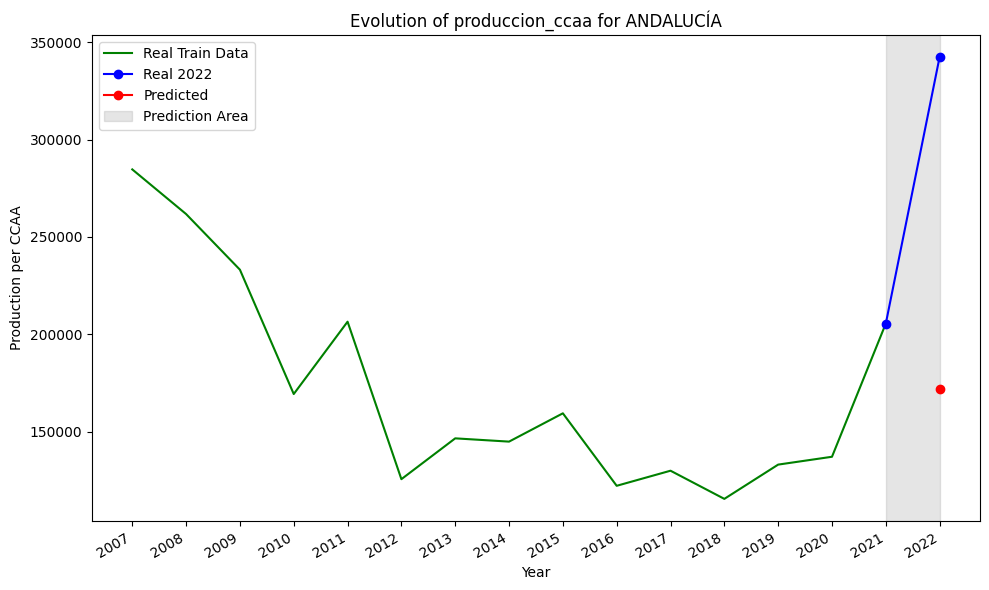

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


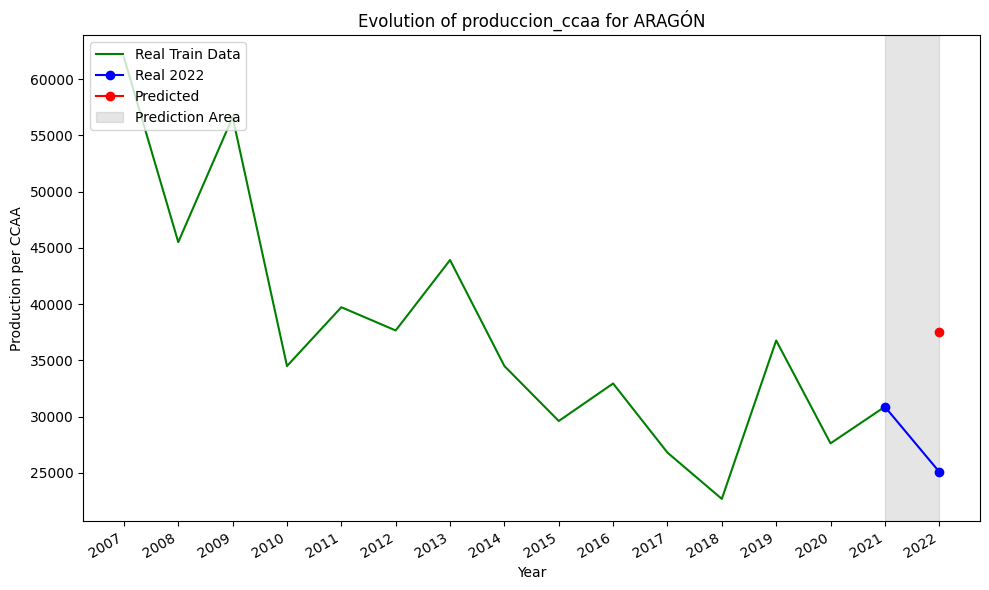

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


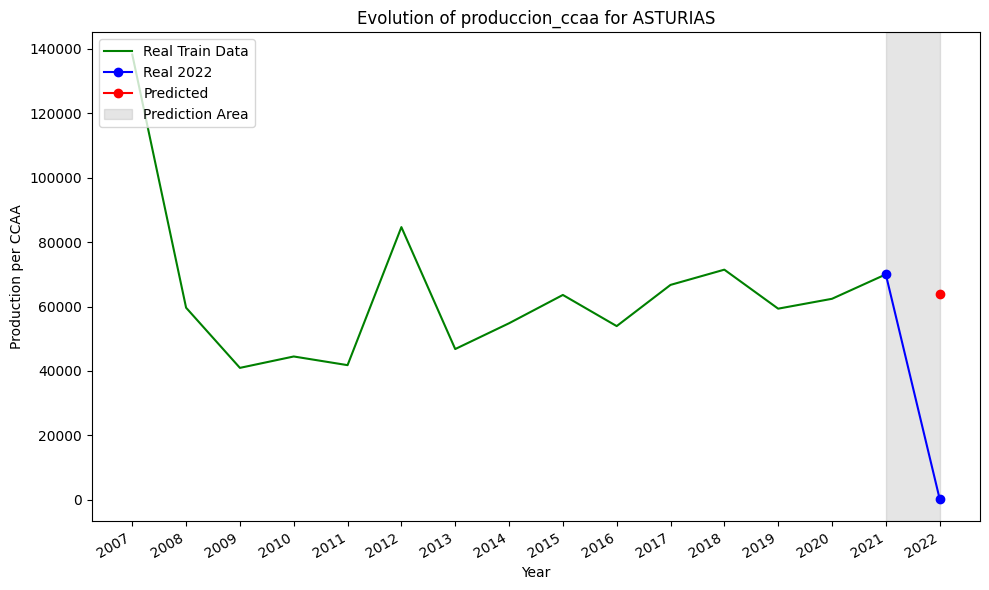

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


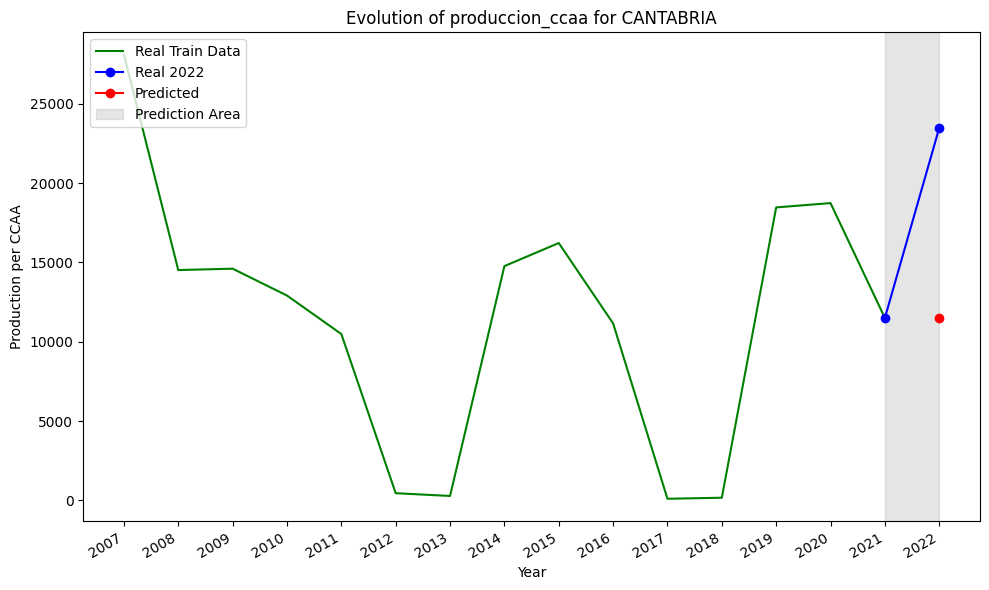

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


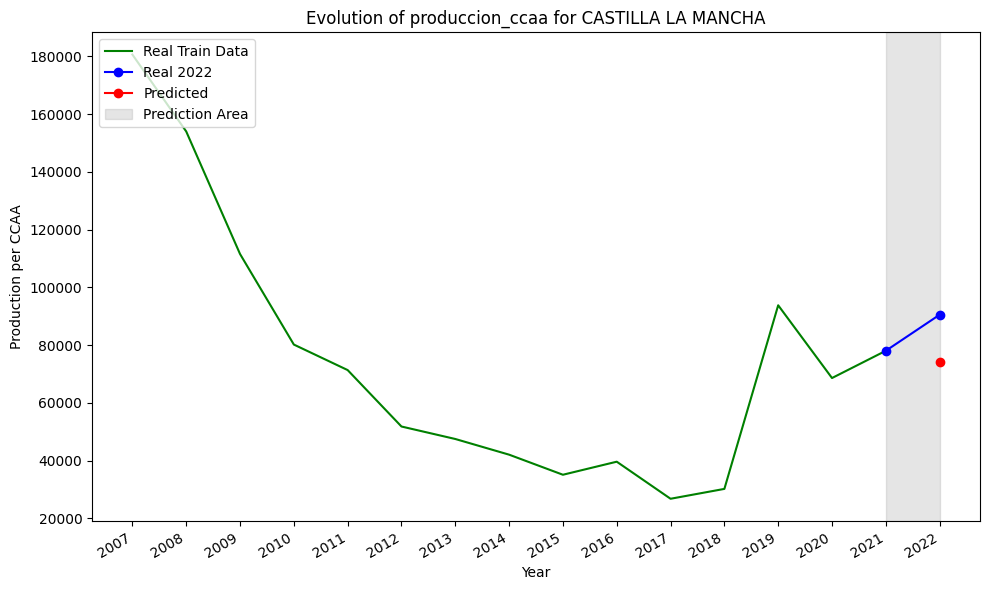

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


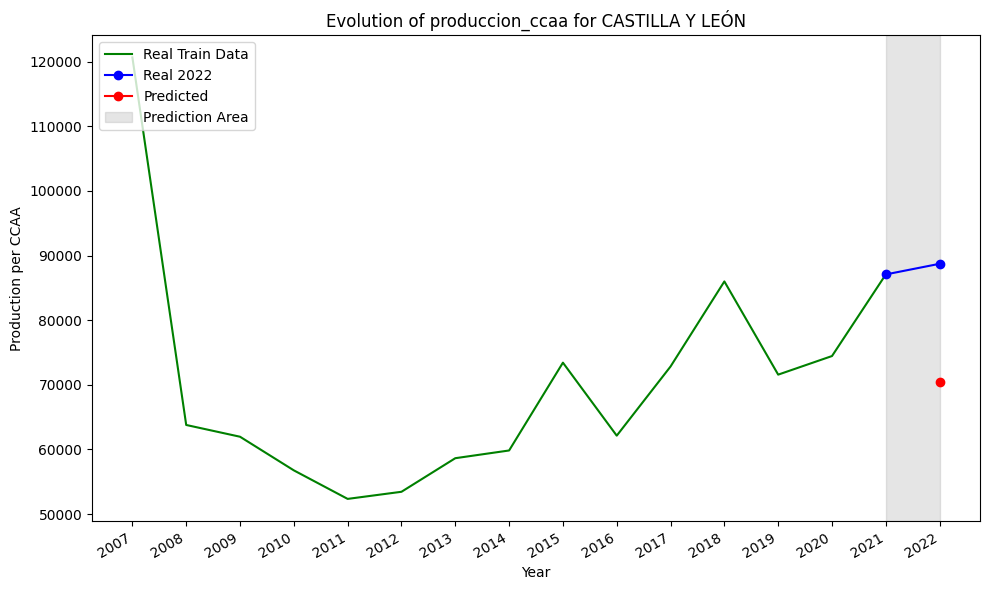

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


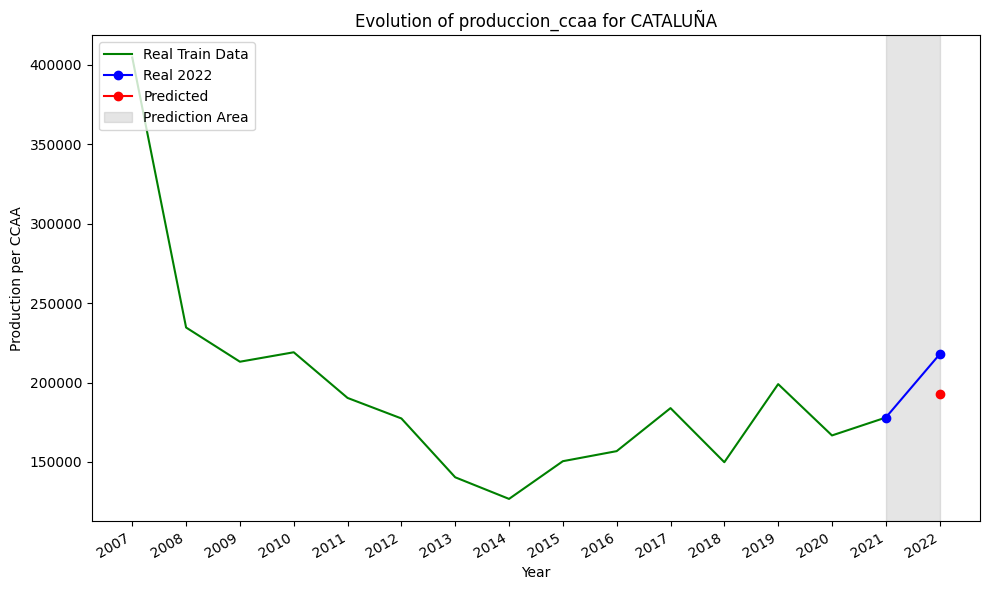

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


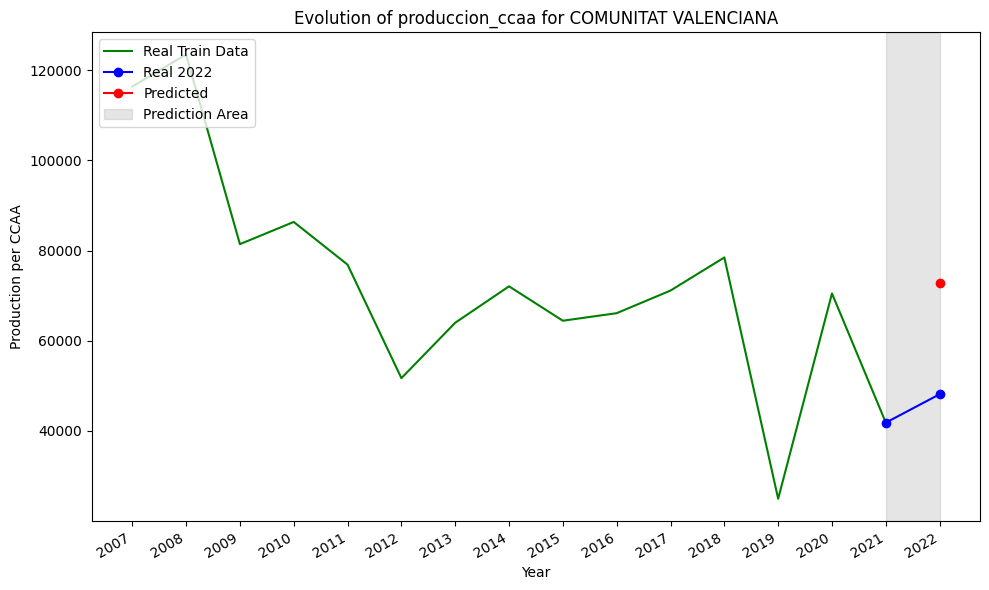

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


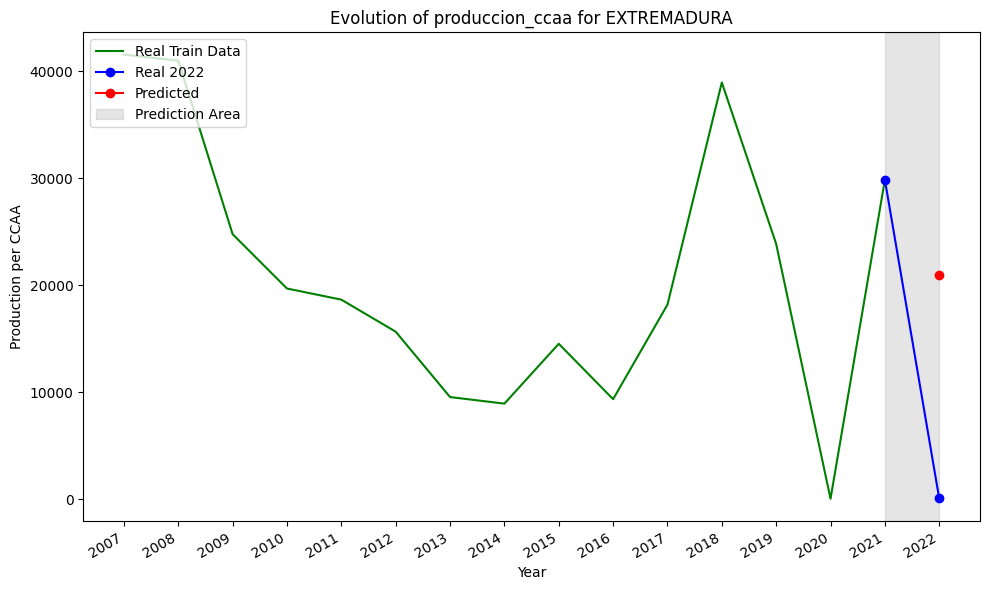

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


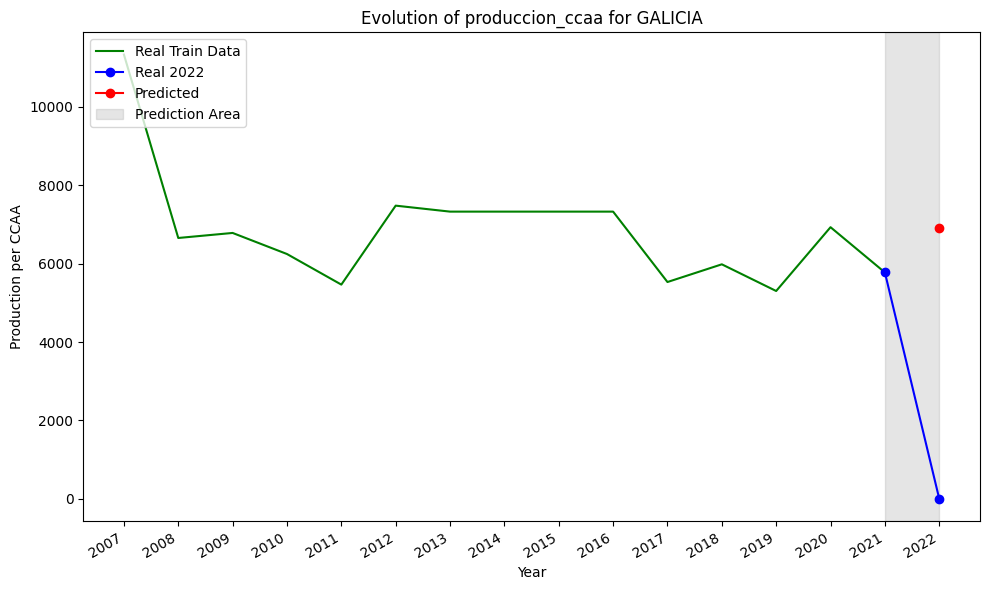

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


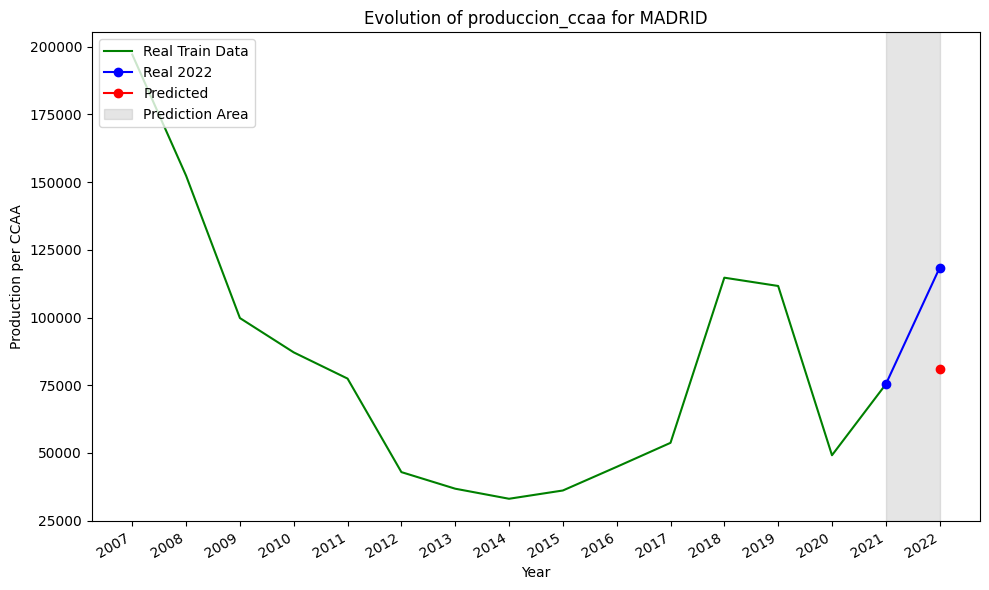

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


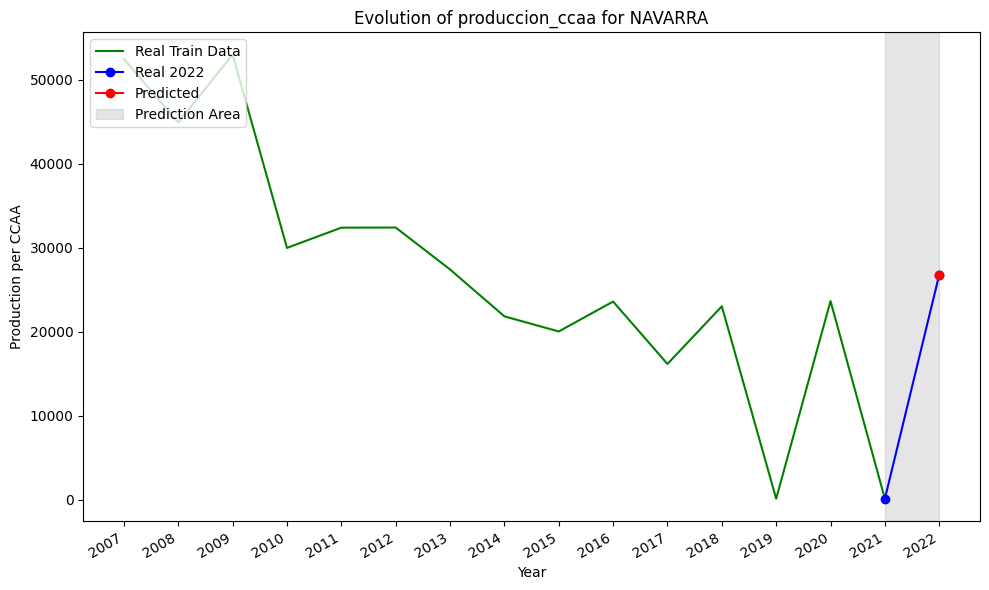

<ipython-input-22-530d38ec4815>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
<ipython-input-22-530d38ec4815>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-22-530d38ec4815>:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


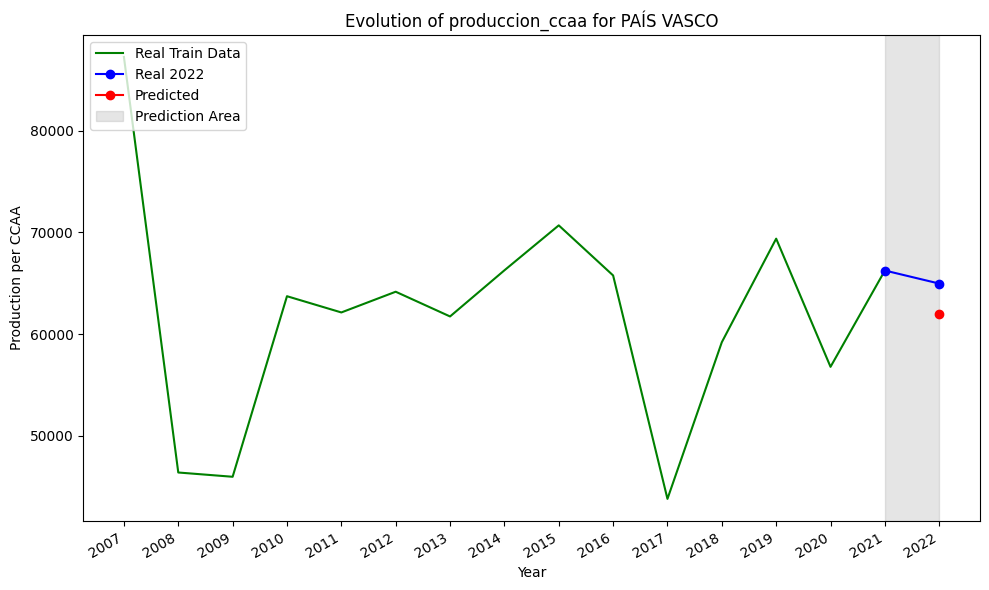

In [ ]:
import matplotlib.pyplot as plt

def visualize_forecast_all_ccaa(train, test, data_key='produccion_ccaa', pred_key="produccion_ccaa_pred"):
    comunidades = train['comunidad_autonoma'].unique()

    for comunidad in comunidades:
        train_comunidad = train[train['comunidad_autonoma'] == comunidad]
        test_comunidad = test_naive_pib[test_naive_pib['comunidad_autonoma'] == comunidad]

        if train_comunidad.empty or test_comunidad.empty:
            print(f"No se encontraron datos para la comunidad {comunidad}.")
            continue

        fig, ax = plt.subplots(figsize=(10, 6))

        #training set until 2021
        ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Real Train Data', color='green')
        ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
                [train_comunidad[data_key].iloc[-1], test_comunidad[data_key].iloc[0]],
                'bo-', color='blue', label='Real 2022')  # Continuación de la línea hasta 2022 (verde)
        ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')

        ax.axvspan(2021, 2022, color='gray', alpha=0.2, label='Prediction Area')
        ax.set_xlabel('Year')
        ax.set_ylabel('Production per CCAA')
        ax.set_title(f'Evolution of {data_key} for {comunidad}')
        ax.set_xticks(range(min(train_comunidad['año']), max(test_comunidad['año']) + 1))
        ax.set_xticklabels(range(min(train_comunidad['año']), max(test_comunidad['año']) + 1))
        ax.legend(loc='upper left')

        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

visualize_forecast_all_ccaa(train, test, 'produccion_ccaa', 'produccion_ccaa_pred')

## Naive Model Mean - BY YEARS

In [ ]:
#year calculation
errores_naive_mean_pib_years = []

for año in sorted(df_naive['año'].unique()):
    train = df_naive[df_naive['año'] < año]
    test = df_naive[df_naive['año'] == año]

    if train.empty or test.empty:
        continue

    mean_prod_pib = train.groupby("comunidad_autonoma")[["produccion_ccaa", "PIB"]].mean().reset_index()
    mean_prod_pib["año"] = año
    mean_prod_pib["PIB_escalado"] = mean_prod_pib["PIB"] / 1e6
    mean_prod_pib["produccion_ccaa_pred"] = mean_prod_pib["produccion_ccaa"] + mean_prod_pib["PIB_escalado"]

    test_naive_pib = test.merge(mean_prod_pib[["comunidad_autonoma", "año", "produccion_ccaa_pred"]],
                                on=["comunidad_autonoma", "año"], how="left")

    # Cálculo de errores agregados por año
    real = test_naive_pib["produccion_ccaa"]
    pred = test_naive_pib["produccion_ccaa_pred"]

    medape = np.median(np.abs((real - pred) / real)) * 100
    rmse = np.sqrt(np.mean((real - pred) ** 2))

    errores_naive_mean_pib_years.append({
        'año': año,
        'MeDAPE Naive1': medape,
        'RMSE Naive1': rmse
    })

errors_naive1_years = pd.DataFrame(errores_naive_mean_pib_years)
display(errors_naive1_years)

,año,MeDAPE Naive1,RMSE Naive1
0,2008,36.135334,58110.455072
1,2009,47.424978,46671.884684
2,2010,53.548557,43481.793822
3,2011,42.908065,35496.477397
4,2012,42.359382,48981.170649
5,2013,45.988932,44121.439295
6,2014,32.546241,41184.600261
7,2015,30.561766,31314.385925
8,2016,29.583020,30302.752692
9,2017,42.777945,25343.196555


# NAIVE MODEL 2

## Naive model by last 3 years tendency

In [ ]:
df_naive2 = df_ccaa.copy()

In [ ]:
train = df_naive2[df_naive2["año"] < 2022]
test = df_naive2[df_naive2["año"] == 2022]

In [ ]:
#last three years with PIB
train_last_three_years = train.groupby('comunidad_autonoma').tail(3)

#mean for the last three years with PIB
mean_combined = train_last_three_years.groupby('comunidad_autonoma')[['produccion_ccaa', 'PIB']].mean().reset_index()
mean_combined.rename(columns={'produccion_ccaa': 'pred_tendencia_3_ultimos_anos','PIB': 'pib_3_ultimos_anos'}, inplace=True)
mean_combined["año"] = 2022

#scale
mean_combined["pib_3_ultimos_anos_escalado"] = mean_combined["pib_3_ultimos_anos"] / 1e6

mean_combined["produccion_ccaa_pred"] = (mean_combined["pred_tendencia_3_ultimos_anos"] + mean_combined["pib_3_ultimos_anos_escalado"])

#test set
test_naive_pib_3 = test.merge(mean_combined[["comunidad_autonoma", "año", "produccion_ccaa_pred"]], on=["comunidad_autonoma", "año"], how="left")

In [ ]:
test_naive_pib_3

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa,PIB,produccion_ccaa_pred
0,ANDALUCIA,2022,A13,ANDALUCÍA,6,1.648827e+09,342442.560084,14600000,183635844,158752.110942
1,NORTE,2022,A7,ARAGÓN,1,2.763531e+08,25106.514590,5600000,43453612,31802.328360
2,OESTE,2022,A3,ASTURIAS,1,2.064010e+06,301.108831,9600000,26481237,63926.715418
3,OESTE,2022,C4,CANTABRIA,1,3.680140e+08,23488.431115,3150000,15540457,16254.878285
4,CENTRO,2022,C10,CASTILLA LA MANCHA,2,7.842797e+08,90533.015990,16940000,49675613,80195.727216
5,OESTE,2022,C2,CASTILLA Y LEÓN,3,1.263411e+09,88736.237268,13850000,65121330,77769.263330
6,CATALUÑA,2022,C8,CATALUÑA,4,2.298128e+09,217783.134336,26375000,258686459,181466.007369
7,CENTRO,2022,C11,COMUNITAT VALENCIANA,3,8.304226e+08,48139.740833,9547500,127589937,45873.150922
8,CENTRO,2022,E12,EXTREMADURA,1,6.500000e+05,56.302024,1600000,23140516,17921.376256
9,OESTE,2022,G1,GALICIA,1,1.110000e+05,4.385678,650000,71365906,6064.154661


ERRORS

In [ ]:
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for ccaa in test_naive_pib_3['comunidad_autonoma'].unique():
    ccaa_data = test_naive_pib_3[test_naive_pib_3['comunidad_autonoma'] == ccaa]
    #MAPE
    medape = np.median(np.abs((ccaa_data['produccion_ccaa'] - ccaa_data['produccion_ccaa_pred']) / ccaa_data['produccion_ccaa'])) * 100
    #RMSE
    rmse = root_mean_squared_error(ccaa_data['produccion_ccaa'], ccaa_data['produccion_ccaa_pred'])

    results.append({
        'comunidad_autonoma': ccaa,
        'medape_n2': medape,
        'rmse_n2': rmse
    })

errores_naive_tendency_pib_df = pd.DataFrame(results)
display(errores_naive_tendency_pib_df)

,comunidad_autonoma,medape_n2,rmse_n2
0,ANDALUCÍA,53.641244,183690.449142
1,ARAGÓN,26.669627,6695.813770
2,ASTURIAS,21130.435249,63625.606587
3,CANTABRIA,30.796237,7233.552830
4,CASTILLA LA MANCHA,11.418253,10337.288773
5,CASTILLA Y LEÓN,12.359070,10966.973938
6,CATALUÑA,16.675822,36317.126968
7,COMUNITAT VALENCIANA,4.708355,2266.589911
8,EXTREMADURA,31730.785056,17865.074232
9,GALICIA,138171.783180,6059.768983


Not by ccaa

In [ ]:
#ape
test_naive_pib_3["abs_pct_error"] = np.abs((test_naive_pib_3["produccion_ccaa"] - test_naive_pib_3["produccion_ccaa_pred"]) / test_naive_pib_3["produccion_ccaa"])

# MAPE
mape2 = test_naive_pib_3["abs_pct_error"].mean()
# MedAPE
medape2 = test_naive_pib_3["abs_pct_error"].median() * 100
#RMSE
rmse_naive2 = np.sqrt(mean_squared_error(test_naive_pib_3['produccion_ccaa'], test_naive_pib_3['produccion_ccaa_pred']))

mean2 = train['produccion_ccaa'].mean()

print(f"MAPE: {mape2:.2f}%")
print(f"MedAPE: {medape2:.2f}%")
print(f"RMSE: {rmse_naive2:.2f}")

MAPE: 147.15%
MedAPE: 30.80%
RMSE: 56637.04


In [ ]:
errors_n2 = []
errors_n2.append({
    'Model': 'Naive - 3 Years Mean',
    'mape_n2': mape2,
    'medape_n2': medape2,
    'rmse_n2': rmse_naive2
})
errors_n2 = pd.DataFrame(errors_n2)
display(errors_n2)

,Model,mape_n2,medape_n2,rmse_n2
0,Naive - 3 Years Mean,147.149217,30.796237,56637.036543


In [ ]:
error_percentage = (rmse_naive2 / mean2) * 100
print(f"Error percentage: {error_percentage}%")

Error percentage: 82.56714478016625%


Visualization

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


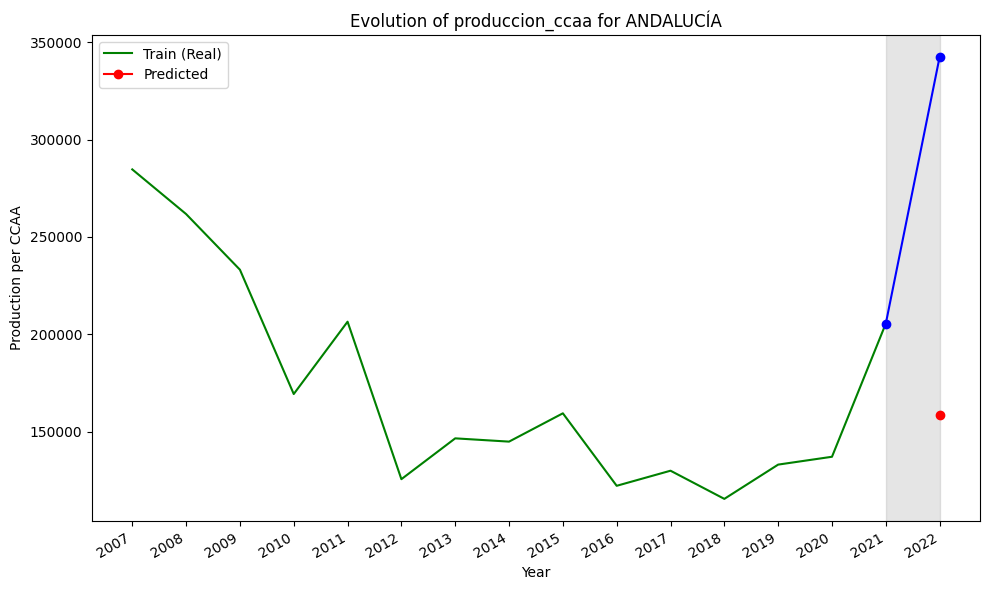

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


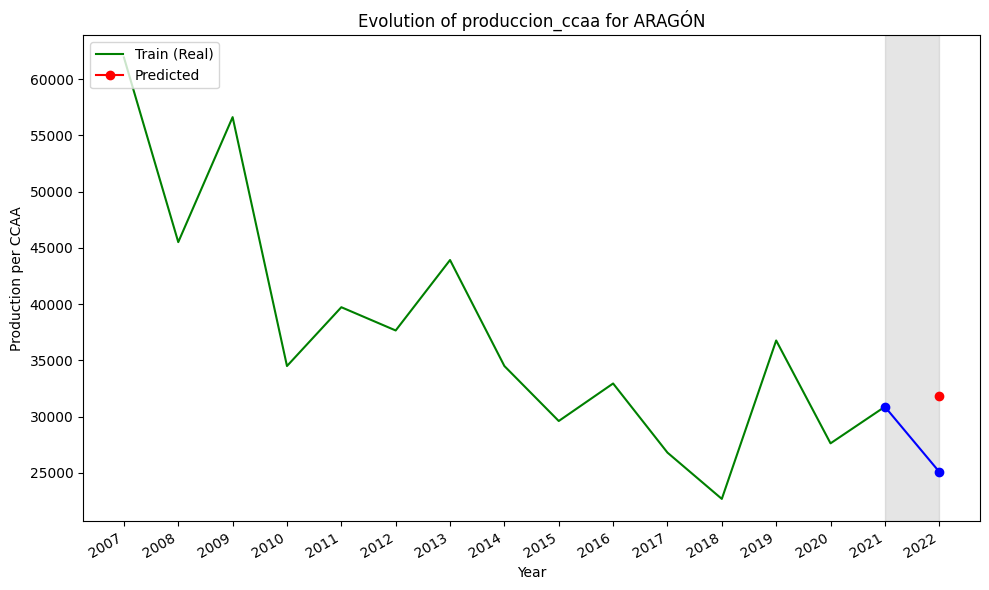

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


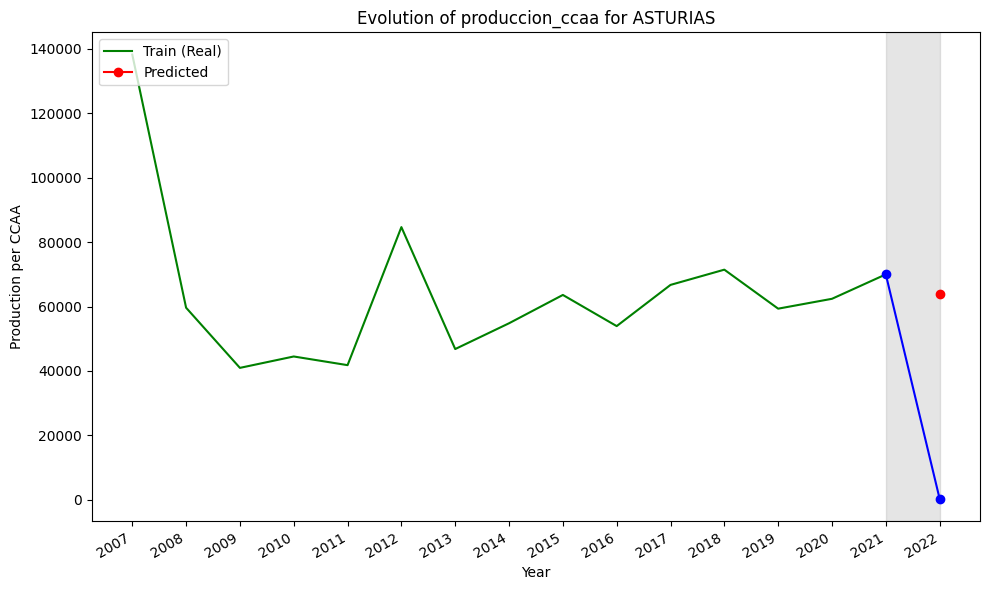

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


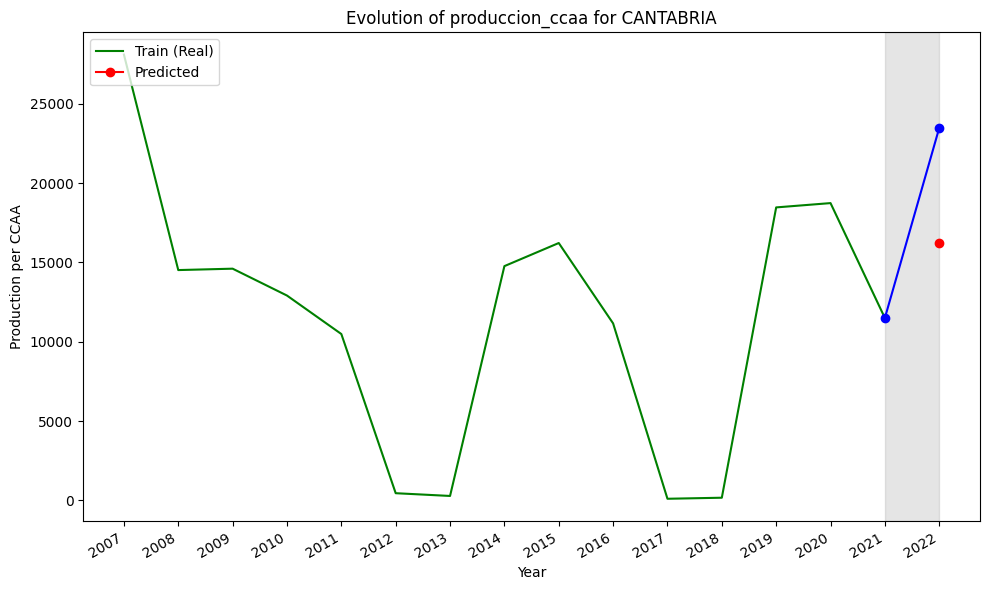

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


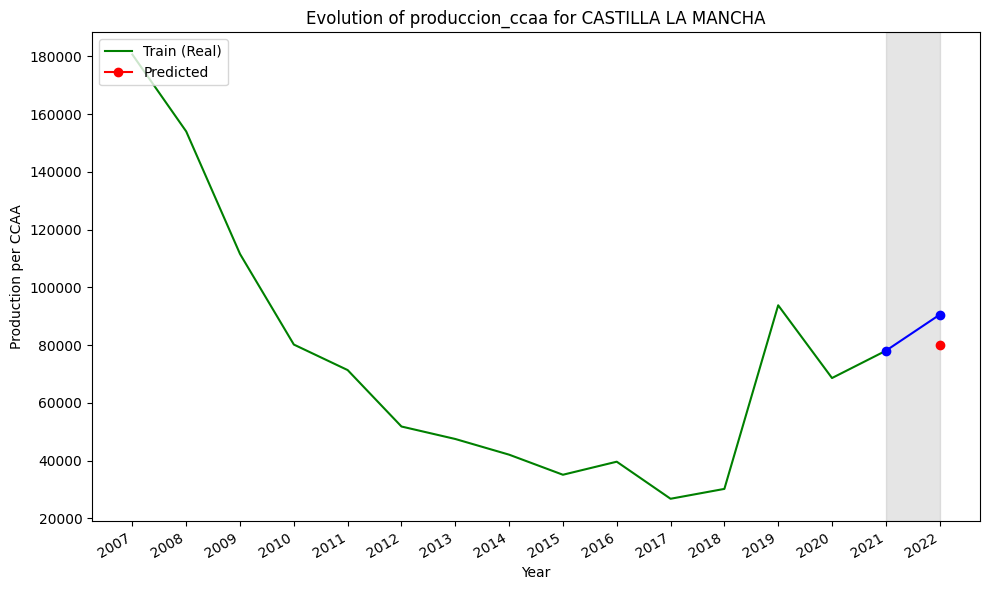

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


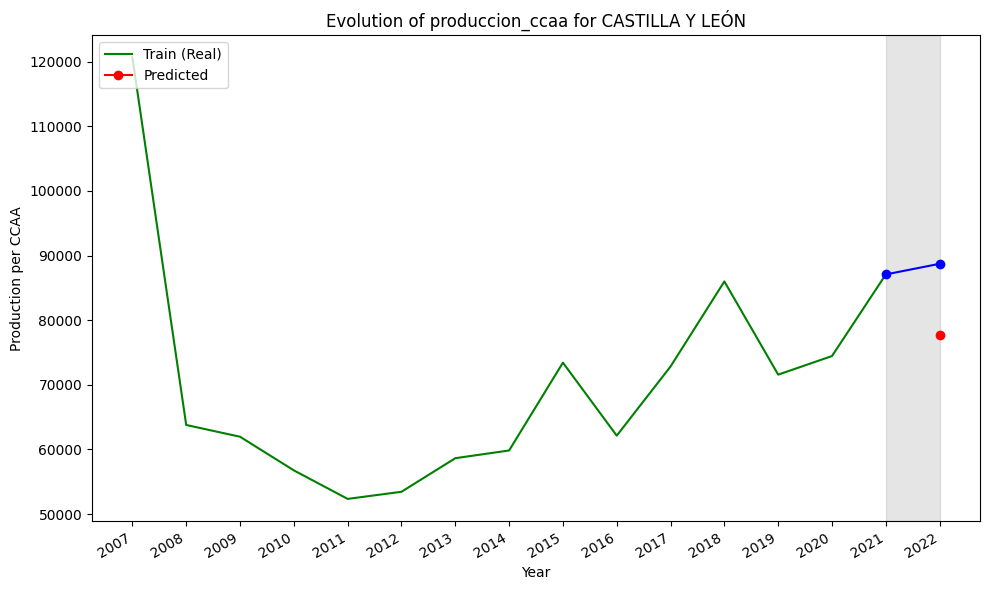

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


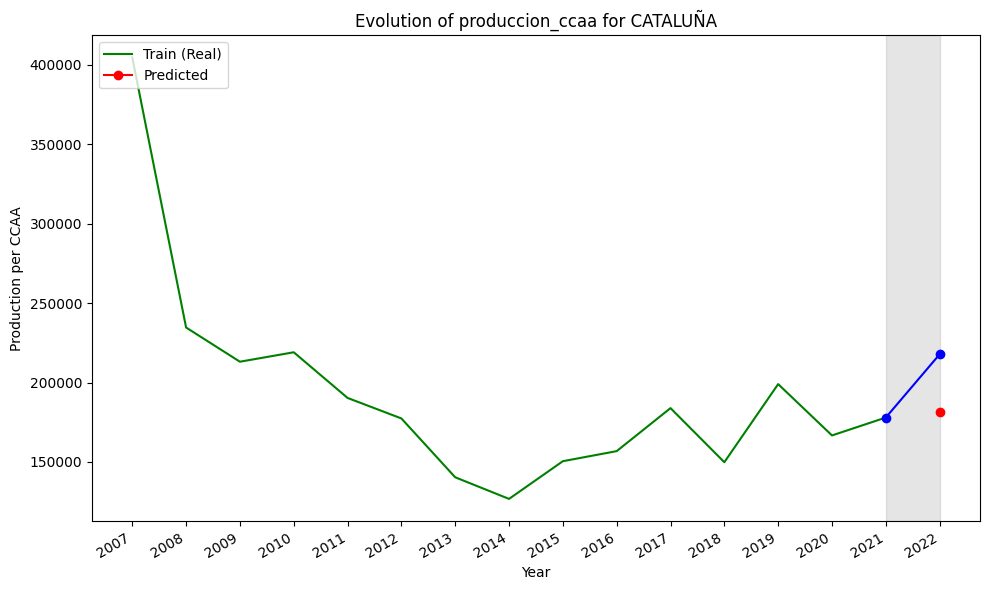

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


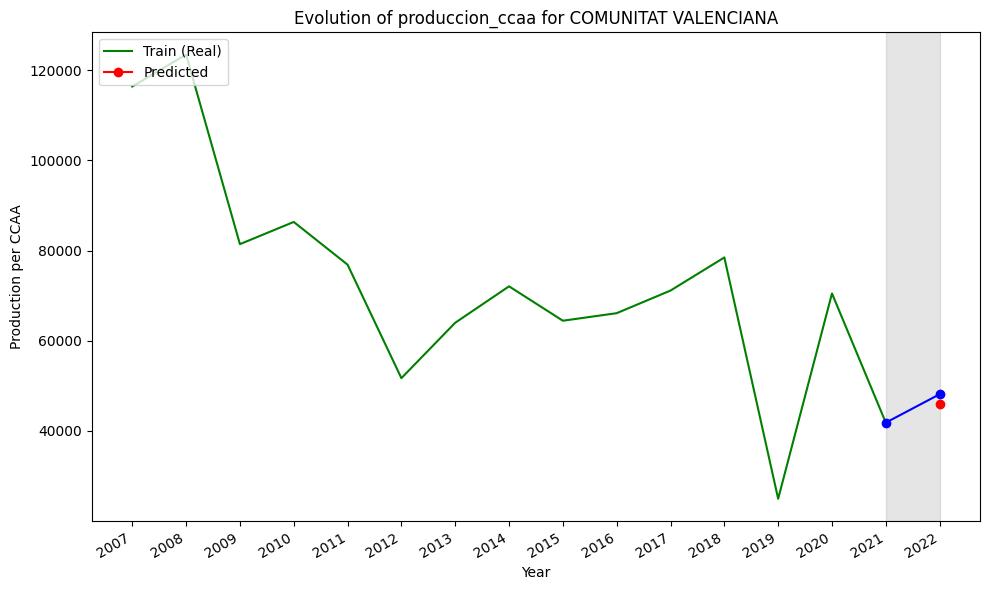

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


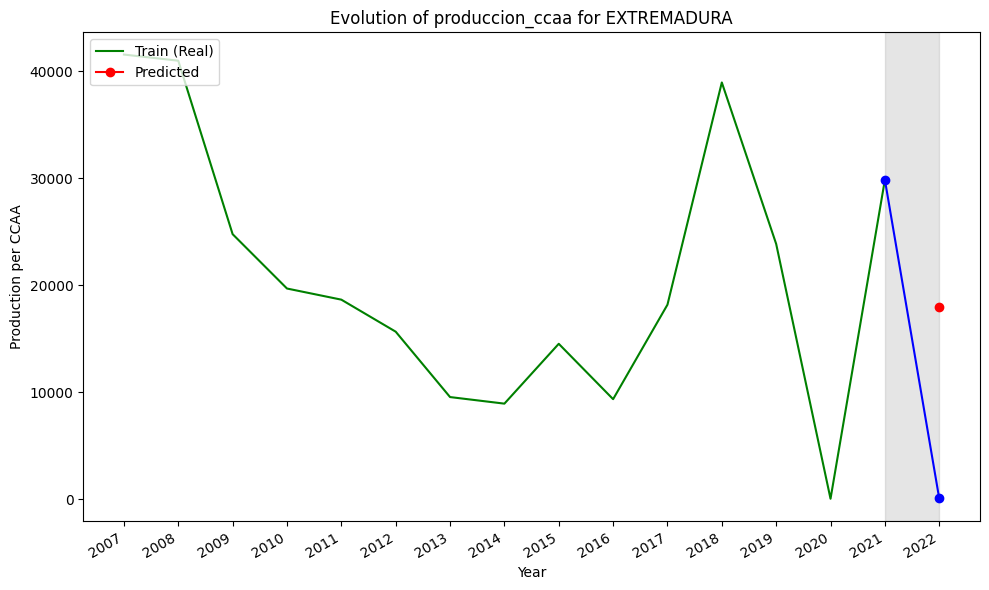

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


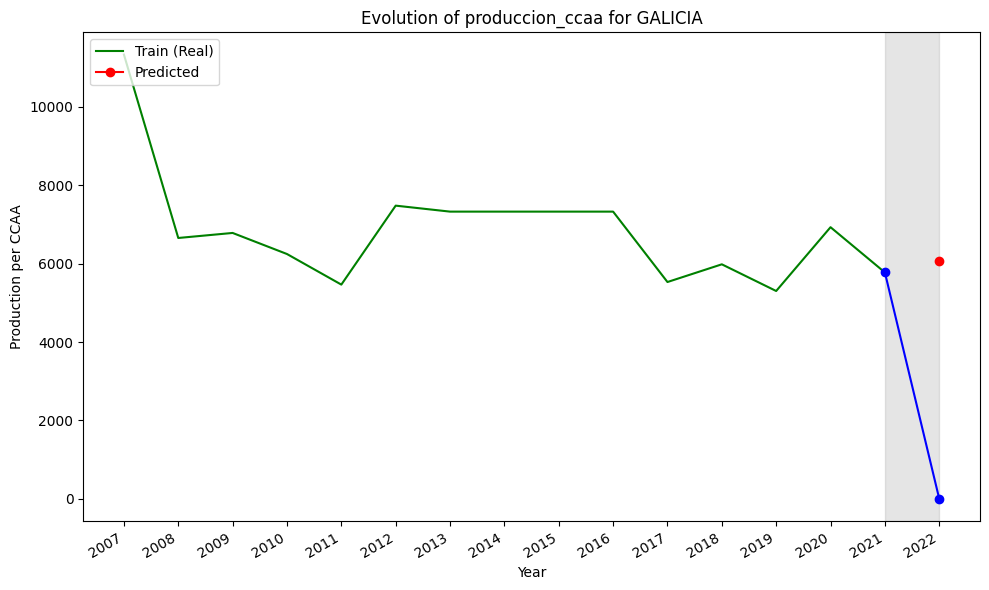

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


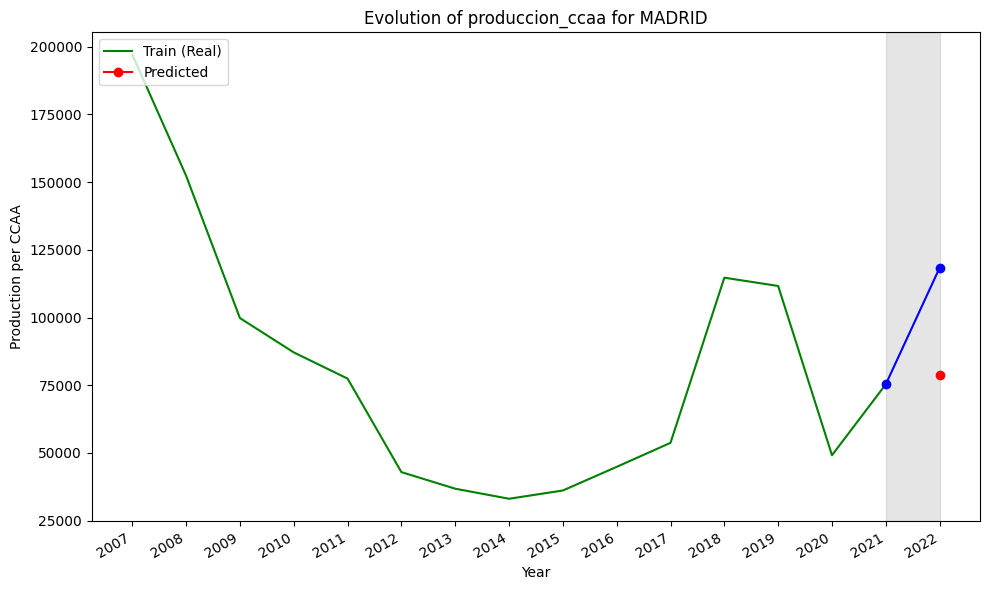

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


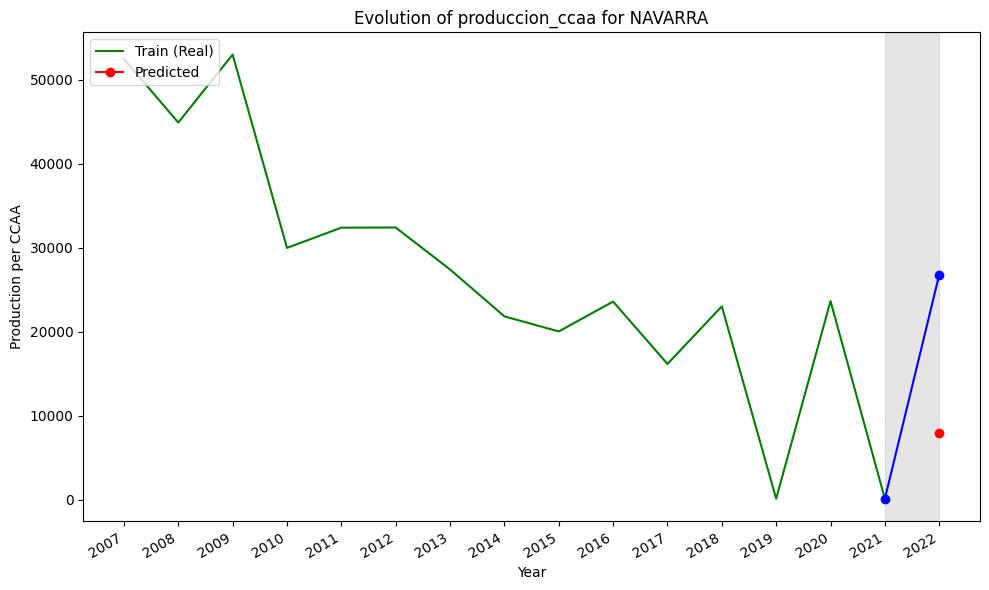

<ipython-input-32-43437cdd1c30>:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
<ipython-input-32-43437cdd1c30>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],
<ipython-input-32-43437cdd1c30>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')


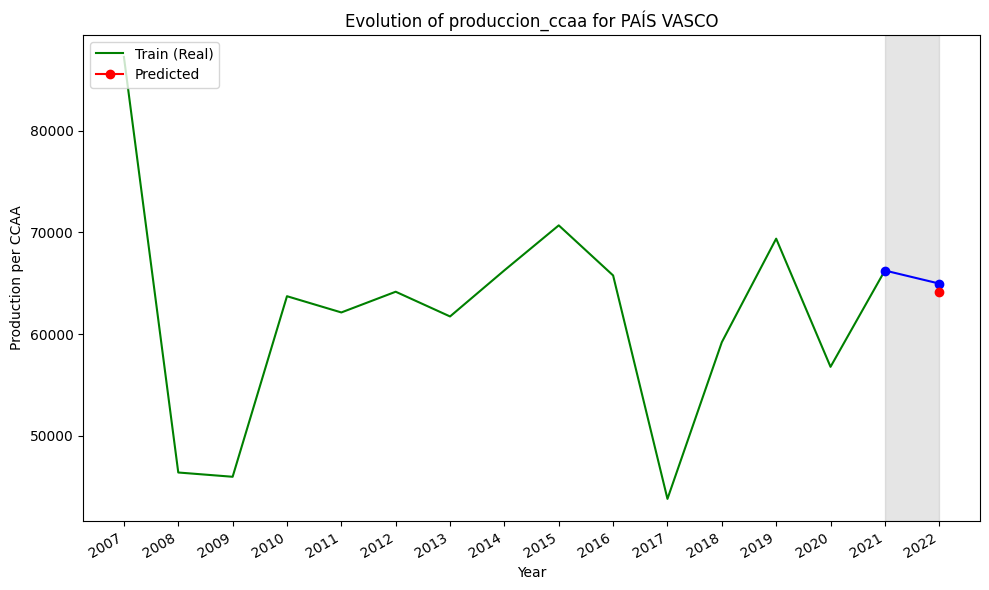

In [ ]:
#VISUALISATION FOR PRODUCTION PREDICITON

def visualize_forecast_all_ccaa(train, test_naive_pib_3, data_key='produccion_ccaa', pred_key="produccion_ccaa_pred"):
    comunidades = train['comunidad_autonoma'].unique()

    for comunidad in comunidades:
        train_comunidad = train[train['comunidad_autonoma'] == comunidad]
        test_comunidad = test_naive_pib_3[test_naive_pib_3['comunidad_autonoma'] == comunidad]

        if train_comunidad.empty or test_comunidad.empty:
            print(f"No se encontraron datos para la comunidad {comunidad}.")
            continue

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.plot(train_comunidad['año'], train_comunidad[data_key], 'g-', label='Train (Real)', color='green')
        ax.plot([train_comunidad['año'].max(), test_comunidad['año'].iloc[0]],[train_comunidad[data_key].iloc[-1], test_comunidad[data_key].iloc[0]],'bo-', color='blue')
        ax.plot(test_comunidad['año'], test_comunidad[pred_key], 'ro-', label='Predicted', color='red')

        ax.set_xlabel('Year')
        ax.set_ylabel('Production per CCAA')
        ax.set_title(f'Evolution of {data_key} for {comunidad}')

        ax.axvspan(2021, 2022, color='#808080', alpha=0.2)

        ax.set_xticks([*range(min(train_comunidad['año']), max(test_comunidad['año']) + 1)])
        ax.set_xticklabels([*range(min(train_comunidad['año']), max(test_comunidad['año']) + 1)])

        ax.legend(loc='upper left')
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

visualize_forecast_all_ccaa(train, test_naive_pib_3, 'produccion_ccaa', 'produccion_ccaa_pred')

## Naive Model 3 years - BY YEARS

In [ ]:
errores_naive_tendency_years = []

for año in sorted(df_naive2['año'].unique()):
    train = df_naive2[df_naive2['año'] < año]
    test = df_naive2[df_naive2['año'] == año]

    if train.empty or test.empty:
        continue

    train_last_three = train.groupby('comunidad_autonoma').tail(3)

    mean_combined = train_last_three.groupby('comunidad_autonoma')[['produccion_ccaa', 'PIB']].mean().reset_index()
    mean_combined.rename(columns={'produccion_ccaa': 'pred_tendencia_3_ultimos_anos',
                                  'PIB': 'pib_3_ultimos_anos'}, inplace=True)
    mean_combined["año"] = año
    mean_combined["pib_3_ultimos_anos_escalado"] = mean_combined["pib_3_ultimos_anos"] / 1e6
    mean_combined["produccion_ccaa_pred"] = mean_combined["pred_tendencia_3_ultimos_anos"] + mean_combined["pib_3_ultimos_anos_escalado"]

    test_naive_pib_3 = test.merge(mean_combined[["comunidad_autonoma", "año", "produccion_ccaa_pred"]],
                                  on=["comunidad_autonoma", "año"], how="left")

    real = test_naive_pib_3["produccion_ccaa"]
    pred = test_naive_pib_3["produccion_ccaa_pred"]

    medape = np.median(np.abs((real - pred) / real)) * 100
    rmse = np.sqrt(np.mean((real - pred) ** 2))

    errores_naive_tendency_years.append({
        'año': año,
        'MeDAPE Naive2': medape,
        'RMSE Naive2': rmse
    })

errors_naive2_years = pd.DataFrame(errores_naive_tendency_years)
display(errors_naive2_years)


,año,MeDAPE Naive2,RMSE Naive2
0,2008,36.135334,58110.455072
1,2009,47.424978,46671.884684
2,2010,53.548557,43481.793822
3,2011,21.088689,20300.215637
4,2012,34.501616,31951.921021
5,2013,15.354356,20293.295012
6,2014,17.301111,15261.876718
7,2015,12.707987,9352.804971
8,2016,4.951754,9648.908566
9,2017,28.826309,15440.093313


# LINEAR REGRESSION

In [ ]:
df_naive3 = df_ccaa.copy()

###With GDP - BY CCAA - 2022

In [ ]:
df_pred = df_naive3.copy()
df_pred['produccion_predicha'] = np.nan

comunidades = df_pred['comunidad_autonoma'].unique()

for ccaa in comunidades:
    ccaa_data = df_pred[df_pred['comunidad_autonoma'] == ccaa].copy()

    #create lags
    ccaa_data['produccion_lag1'] = ccaa_data['produccion_ccaa'].shift(1)
    ccaa_data['PIB_lag1'] = ccaa_data['PIB'].shift(1)

    train_data = ccaa_data[(ccaa_data['año'] < 2022) & ccaa_data['produccion_lag1'].notna() & ccaa_data['PIB_lag1'].notna()]

    if len(train_data) < 2:
        continue

    X_train = train_data[['produccion_lag1', 'PIB_lag1']]
    y_train = train_data['produccion_ccaa']

    #model
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    datos_2021 = ccaa_data[ccaa_data['año'] == 2021][['produccion_ccaa', 'PIB']]

    if datos_2021.empty:
        continue

    X_input = datos_2021.values
    pred_2022 = modelo.predict(X_input)[0]

    df_pred.loc[
        (df_pred['comunidad_autonoma'] == ccaa) & (df_pred['año'] == 2022),
        'produccion_predicha'
    ] = pred_2022

errores_2022 = []
df_2022 = df_pred[df_pred['año'] == 2022].copy()

for _, row in df_2022.iterrows():
    y_true = row['produccion_ccaa']
    y_pred = row['produccion_predicha']
    ccaa = row['comunidad_autonoma']

    if pd.notna(y_pred) and y_true != 0:
        medape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
        rmse = np.sqrt(mean_squared_error([y_true], [y_pred]))

        errores_2022.append({
            'comunidad_autonoma': ccaa,
            'MedAPE LR with GDP': medape,
            'RMSE LR with GDP': rmse
        })

errores_regresion_gdp_df = pd.DataFrame(errores_2022)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

In [ ]:
errores_regresion_gdp_df

,comunidad_autonoma,MedAPE LR with GDP,RMSE LR with GDP
0,ANDALUCÍA,45.631941,156263.186411
1,ARAGÓN,27.669556,6946.861214
2,ASTURIAS,18549.389874,55853.851027
3,CANTABRIA,40.722987,9565.190834
4,CASTILLA LA MANCHA,4.224427,3824.501346
5,CASTILLA Y LEÓN,16.351940,14510.096206
6,CATALUÑA,16.244773,35378.375335
7,COMUNITAT VALENCIANA,8.717208,4196.441181
8,EXTREMADURA,40810.273255,22977.009861
9,GALICIA,129213.216467,5666.875127


###With out GDP - BY CCAA - 2022

In [ ]:
df_pred2 = df_naive3.copy()
df_pred2['produccion_predicha'] = np.nan

comunidades = df_pred2['comunidad_autonoma'].unique()

for ccaa in comunidades:
    ccaa_data = df_pred2[df_pred2['comunidad_autonoma'] == ccaa].copy()

    ccaa_data['produccion_lag1'] = ccaa_data['produccion_ccaa'].shift(1)

    train_data = ccaa_data[(ccaa_data['año'] < 2022) & ccaa_data['produccion_lag1'].notna()]

    if len(train_data) < 2:
        continue

    X_train = train_data[['produccion_lag1']]
    y_train = train_data['produccion_ccaa']

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    datos_2021 = ccaa_data[ccaa_data['año'] == 2021][['produccion_ccaa']]

    if datos_2021.empty:
        continue

    X_input = datos_2021.values
    pred_2022 = modelo.predict(X_input)[0]

    df_pred2.loc[
        (df_pred2['comunidad_autonoma'] == ccaa) & (df_pred2['año'] == 2022),
        'produccion_predicha'
    ] = pred_2022

errores_2022_2 = []
df_2022_2 = df_pred2[df_pred2['año'] == 2022].copy()

for _, row in df_2022_2.iterrows():
    y_true = row['produccion_ccaa']
    y_pred = row['produccion_predicha']
    ccaa = row['comunidad_autonoma']

    if pd.notna(y_pred) and y_true != 0:
        medape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
        rmse = np.sqrt(mean_squared_error([y_true], [y_pred]))

        errores_2022_2.append({
            'comunidad_autonoma': ccaa,
            'MedAPE LR no GDP': medape,
            'RMSE LR no GDP': rmse
        })

errores_regression_df = pd.DataFrame(errores_2022_2)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

In [ ]:
errores_regression_df

,comunidad_autonoma,MedAPE LR no GDP,RMSE LR no GDP
0,ANDALUCÍA,46.012919,157567.818653
1,ARAGÓN,31.235690,7842.193041
2,ASTURIAS,19343.917346,58246.243411
3,CANTABRIA,56.090395,13174.753904
4,CASTILLA LA MANCHA,23.548269,21318.957858
5,CASTILLA Y LEÓN,21.252055,18858.274231
6,CATALUÑA,20.799002,45296.718862
7,COMUNITAT VALENCIANA,17.602651,8473.870603
8,EXTREMADURA,39530.994797,22256.750196
9,GALICIA,146863.711354,6440.968933


## LR - By years


Verification of the correlation of the production and the GDP

In [ ]:
correlation_matrix = df_naive3[['produccion_ccaa', 'PIB']].corr()
print(correlation_matrix)

                 produccion_ccaa       PIB
produccion_ccaa         1.000000  0.659413
PIB                     0.659413  1.000000


###With GDP - global

In [ ]:
df_2022 = df_pred[df_pred['año'] == 2022].dropna(subset=['produccion_predicha'])

y_true = df_2022['produccion_ccaa'].values
y_pred = df_2022['produccion_predicha'].values

mape_lr = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
medape_lr = np.median(np.abs((y_true - y_pred) / y_true)) * 100
rmse_lr = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAPE global 2022: {mape_lr:.2f}%")
print(f"MedAPE global 2022: {medape_lr:.2f}%")
print(f"RMSE global 2022: {rmse_lr:.2f}")

MAPE global 2022: 14527.05%
MedAPE global 2022: 34.93%
RMSE global 2022: 49518.02


In [ ]:
errors_lr_gdp = []
errors_lr_gdp.append({
    'Model': 'Linear Regression',
    'mape_lr_gdp': mape_lr,
    'medape_lr_gdp': medape_lr,
    'rmse_lr_gdp': rmse_lr
})
errors_lr_gdp = pd.DataFrame(errors_lr_gdp)
display(errors_lr_gdp)

,Model,mape_lr_gdp,medape_lr_gdp,rmse_lr_gdp
0,Linear Regression,14527.049418,34.925385,49518.01919


###With out GDP - global

In [ ]:
df_2022_2 = df_pred2[df_pred2['año'] == 2022].dropna(subset=['produccion_predicha'])

y_true = df_2022_2['produccion_ccaa'].values
y_pred = df_2022_2['produccion_predicha'].values

mape_lr2 = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
medape_lr2 = np.median(np.abs((y_true - y_pred) / y_true)) * 100
rmse_lr2 = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAPE global 2022: {mape_lr2:.2f}%")
print(f"MedAPE global 2022: {medape_lr2:.2f}%")
print(f"RMSE global 2022: {rmse_lr2:.2f}")

MAPE global 2022: 15851.81%
MedAPE global 2022: 41.48%
RMSE global 2022: 51667.15


In [ ]:
errors_lr = []
errors_lr.append({
    'Model': 'Linear Regression',
    'mape_lr': mape_lr2,
    'medape_lr': medape_lr2,
    'rmse_lr': rmse_lr2
})
errors_lr = pd.DataFrame(errors_lr)
display(errors_lr)

,Model,mape_lr,medape_lr,rmse_lr
0,Linear Regression,15851.811867,41.483814,51667.152872


###With GDP - BY YEAR

In [ ]:
h = 3 #max lag

df_pred = df_naive3.copy()
df_pred = df_pred.sort_values(['comunidad_autonoma', 'año']).reset_index(drop=True)
df_pred['produccion_predicha'] = np.nan

def crear_lags(df, col, max_lag):
    max_lag = min(max_lag, h)  #max h
    for lag in range(1, max_lag+1):
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

for ccaa in df_pred['comunidad_autonoma'].unique():
    ccaa_data = df_pred[df_pred['comunidad_autonoma'] == ccaa].copy()
    max_lag = len(ccaa_data) - 1
    max_lag = min(max_lag, h)

    ccaa_data = crear_lags(ccaa_data, 'produccion_ccaa', max_lag)
    ccaa_data = crear_lags(ccaa_data, 'PIB', max_lag)

    for idx in range(max_lag, len(ccaa_data)):
        fila = ccaa_data.iloc[idx]
        X_cols = [f'produccion_ccaa_lag_{lag}' for lag in range(1, max_lag+1)] + ['PIB'] + [f'PIB_lag_{lag}' for lag in range(1, max_lag+1)]

        train = ccaa_data.iloc[:idx].dropna(subset=X_cols + ['produccion_ccaa'])
        if len(train) < 2:
            continue

        X_train = train[X_cols]
        y_train = train['produccion_ccaa']

        modelo = LinearRegression()
        modelo.fit(X_train, y_train)

        if fila[X_cols].isnull().any():
            continue

        X_pred = fila[X_cols].values.reshape(1, -1)
        pred = modelo.predict(X_pred)[0]

        idx_original = df_pred[(df_pred['comunidad_autonoma'] == ccaa) & (df_pred['año'] == fila['año'])].index
        df_pred.loc[idx_original, 'produccion_predicha'] = pred


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

In [ ]:
df_pred.dropna(subset=['produccion_predicha'], inplace=True)

In [ ]:
resultados = []

for año in sorted(df_pred['año'].unique()):
    df_año = df_pred[df_pred['año'] == año]

    y_true = df_año['produccion_ccaa']
    y_pred = df_año['produccion_predicha']

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    resultados.append({
        'año': año,
        'MedAPE LR GDP': medape,
        'RMSE LR GDP': rmse
    })

errors_lr_years_gdp = pd.DataFrame(resultados)

errors_lr_years_gdp

,año,MedAPE LR GDP,RMSE LR GDP
0,2012,22.517422,28231.257954
1,2013,16.794660,26433.020431
2,2014,14.824365,10015.357239
3,2015,30.664976,29447.183473
4,2016,21.707487,22739.191729
5,2017,25.606376,76211.768645
6,2018,50.317061,101509.667543
7,2019,25.717184,49281.779387
8,2020,54.284117,107037.148255
9,2021,97.286071,89466.330284


VISUALIZATION

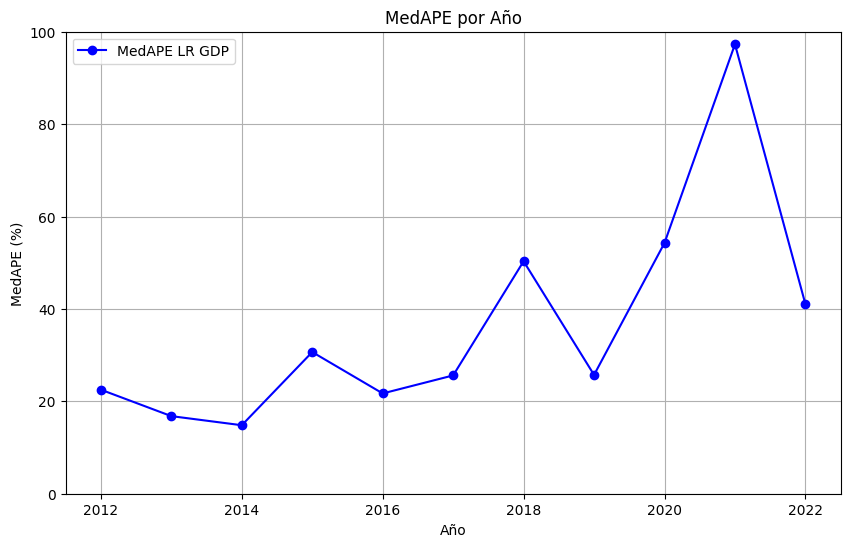

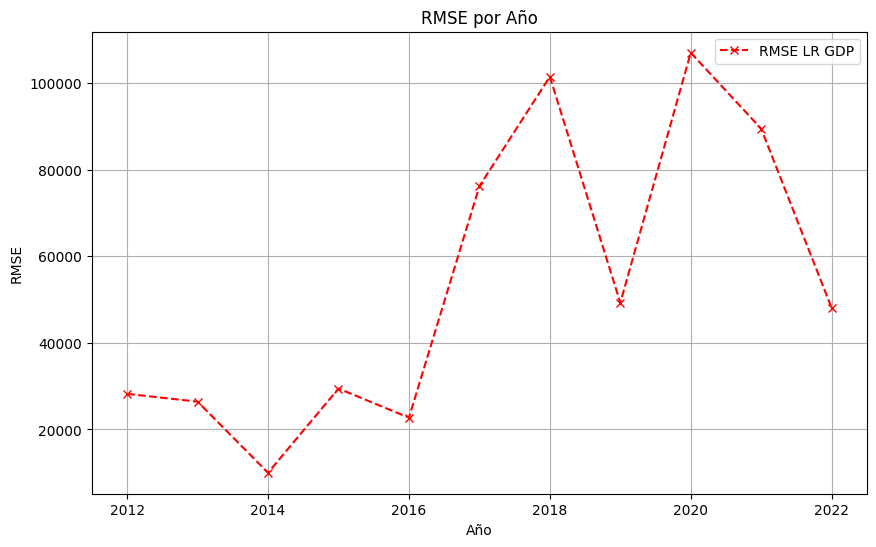

In [ ]:
#MedAPE
plt.figure(figsize=(10, 6))
plt.plot(errors_lr_years_gdp['año'], errors_lr_years_gdp['MedAPE LR GDP'], label='MedAPE LR GDP', marker='o', linestyle='-', color='b')
plt.title('MedAPE por Año')
plt.xlabel('Año')
plt.ylabel('MedAPE (%)')
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.show()

#RMSE
plt.figure(figsize=(10, 6))
plt.plot(errors_lr_years_gdp['año'], errors_lr_years_gdp['RMSE LR GDP'], label='RMSE LR GDP', marker='x', linestyle='--', color='r')
plt.title('RMSE por Año')
plt.xlabel('Año')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.show()

###With out GDP - BY YEAR

In [ ]:
h = 3

df_pred2 = df_naive3.copy()
df_pred2 = df_pred2.sort_values(['comunidad_autonoma', 'año']).reset_index(drop=True)
df_pred2['produccion_predicha'] = np.nan

def crear_lags(df, col, max_lag):
    max_lag = min(max_lag, h)
    for lag in range(1, max_lag+1):
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

for ccaa in df_pred2['comunidad_autonoma'].unique():
    ccaa_data = df_pred2[df_pred2['comunidad_autonoma'] == ccaa].copy()
    max_lag = len(ccaa_data) - 1
    max_lag = min(max_lag, h)

    ccaa_data = crear_lags(ccaa_data, 'produccion_ccaa', max_lag)

    for idx in range(max_lag, len(ccaa_data)):
        fila = ccaa_data.iloc[idx]
        X_cols = [f'produccion_ccaa_lag_{lag}' for lag in range(1, max_lag+1)]

        train = ccaa_data.iloc[:idx].dropna(subset=X_cols + ['produccion_ccaa'])
        if len(train) < 2:
            continue

        X_train = train[X_cols]
        y_train = train['produccion_ccaa']

        modelo = LinearRegression()
        modelo.fit(X_train, y_train)

        if fila[X_cols].isnull().any():
            continue

        X_pred = fila[X_cols].values.reshape(1, -1)
        pred = modelo.predict(X_pred)[0]

        idx_original = df_pred2[
            (df_pred2['comunidad_autonoma'] == ccaa) &
            (df_pred2['año'] == fila['año'])
        ].index

        df_pred2.loc[idx_original, 'produccion_predicha'] = pred


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

In [ ]:
df_pred2.dropna(subset=['produccion_predicha'], inplace=True)

In [ ]:
results = []

for año in sorted(df_pred2['año'].unique()):
    df_año = df_pred2[df_pred2['año'] == año]

    y_true = df_año['produccion_ccaa']
    y_pred = df_año['produccion_predicha']

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({
        'año': año,
        'MedAPE LR no GDP': medape,
        'RMSE LR no GDP': rmse
    })

errors_lr_years_no_gdp = pd.DataFrame(results)

In [ ]:
errors_lr_years_no_gdp

,año,MedAPE LR no GDP,RMSE LR no GDP
0,2012,24.349918,28427.276671
1,2013,23.662466,29710.551272
2,2014,31.631891,73411.816574
3,2015,31.369214,33696.852142
4,2016,10.663730,11102.354364
5,2017,21.550707,16524.566556
6,2018,21.549527,25012.678791
7,2019,30.120394,32111.937963
8,2020,13.347127,29574.343032
9,2021,39.070191,34968.303875


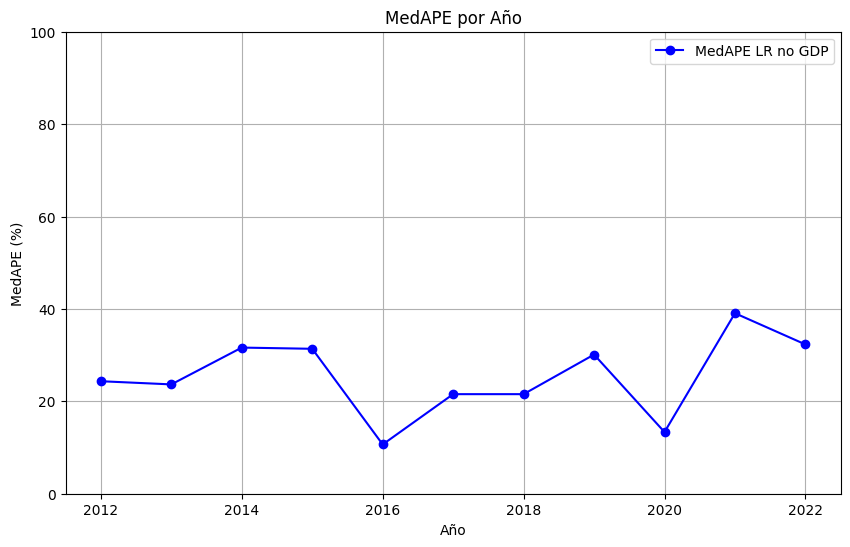

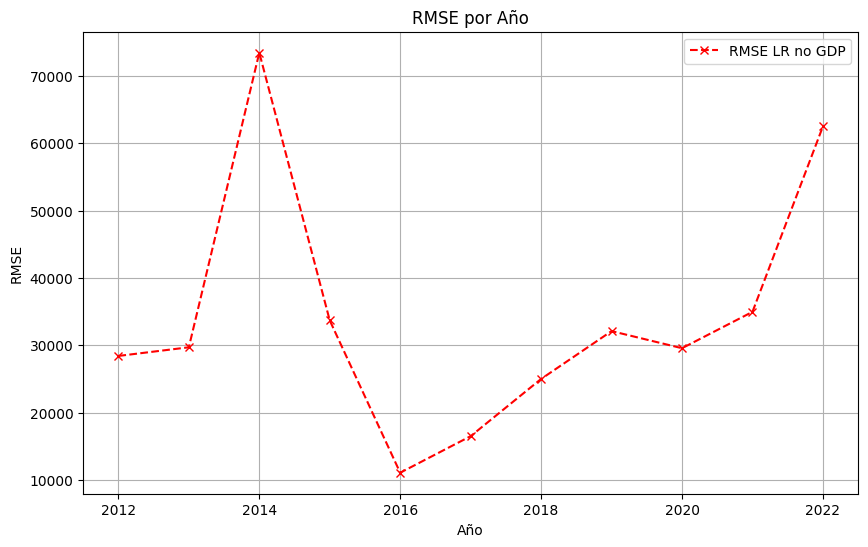

In [ ]:
#MedAPE
plt.figure(figsize=(10, 6))
plt.plot(errors_lr_years_no_gdp['año'], errors_lr_years_no_gdp['MedAPE LR no GDP'], label='MedAPE LR no GDP', marker='o', linestyle='-', color='b')
plt.title('MedAPE por Año')
plt.xlabel('Año')
plt.ylabel('MedAPE (%)')
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.show()

#RMSE
plt.figure(figsize=(10, 6))
plt.plot(errors_lr_years_no_gdp['año'], errors_lr_years_no_gdp['RMSE LR no GDP'], label='RMSE LR no GDP', marker='x', linestyle='--', color='r')
plt.title('RMSE por Año')
plt.xlabel('Año')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.show()

#NEURAL NETWORK

## Neural Network - NOT BY YEARS


In [ ]:
df_nn = df_ccaa.copy()

In [ ]:
#lag for the last 3 years
for lag in range(1, 4):
    df_nn[f'produccion_lag_{lag}'] = df_nn.groupby('comunidad_autonoma')['produccion_ccaa'].shift(lag)
    df_nn[f'PIB_lag_{lag}'] = df_nn.groupby('comunidad_autonoma')['PIB'].shift(lag)

#delete created NaN
df_nn = df_nn.dropna(subset=[f'produccion_lag_{lag}' for lag in range(1, 4)] + [f'PIB_lag_{lag}' for lag in range(1, 4)])

#split dataset
train = df_nn[df_nn["año"] < 2022]
test = df_nn[df_nn["año"] == 2022]

X_train = train[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
                 'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
y_train = train['produccion_ccaa']  #production to predict

X_test = test[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
               'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
y_test = test['produccion_ccaa']

In [ ]:
#NORMALIZE
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
#y_train into 2D for the scaler
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

#tensor to code the parameters
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

In [ ]:
#define neural network
class NeuralNet(nn.Module):
    def __init__(self, num_layers=2):
        super(NeuralNet, self).__init__()

        layers = []
        input_size = 6
        hidden_size = 64

        for _ in range(num_layers):
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(hidden_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
#tain the NN
def train_model(model, X_train_tensor, y_train_tensor, learning_rate=0.01, batch_size=64, epochs=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    #have a validation set
    X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.2)

    #train
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            #predictions
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)

            #backpropagation
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_val)
        val_loss = criterion(y_pred.squeeze(), y_val)

    return val_loss.item(), model

In [ ]:
#search for the best hyperparameters
param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'num_layers': [2, 4, 8]
}

best_loss = float('inf')
best_params = {}

for learning_rate in param_grid['learning_rate']:
    for batch_size in param_grid['batch_size']:
        for num_layers in param_grid['num_layers']:
            model = NeuralNet(num_layers=num_layers)
            val_loss, trained_model = train_model(model, X_train_tensor, y_train_tensor,
                                                   learning_rate=learning_rate, batch_size=batch_size)

            if val_loss < best_loss:
                best_loss = val_loss
                best_params = {'learning_rate': learning_rate, 'batch_size': batch_size, 'num_layers': num_layers}

print(f"Best hyperparameters: {best_params} with validation loss: {best_loss}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([28, 1])) that is different to the input size (torch.Size([28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

Best hyperparameters: {'learning_rate': 0.1, 'batch_size': 64, 'num_layers': 8} with validation loss: 0.4354133605957031


In [ ]:
#final model with best hyprparameters
best_model = NeuralNet(num_layers=best_params['num_layers'])
best_model = best_model.eval()
learning_rate = best_params['learning_rate']
batch_size = best_params['batch_size']

#train
_, trained_model = train_model(best_model, X_train_tensor, y_train_tensor,
                                learning_rate=learning_rate, batch_size=batch_size)

#final prediction
with torch.no_grad():
    y_pred_test = trained_model(X_test_tensor)

In [ ]:
y_pred_test_np = y_pred_test.numpy().reshape(-1, 1)
y_pred_inverse = scaler_y.inverse_transform(y_pred_test_np)

y_test_np = y_test_tensor.numpy().reshape(-1, 1)
y_test_inverse = scaler_y.inverse_transform(y_test_np)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def medape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

mape_nn = mape(y_test_inverse, y_pred_inverse)
medape_nn = medape(y_test_inverse, y_pred_inverse)
rmse_nn = rmse(y_test_inverse, y_pred_inverse)

print(f"MAPE: {mape_nn:.2f}%")
print(f"MedAPE: {medape_nn:.2f}%")
print(f"RMSE: {rmse_nn:.2f}")

MAPE: 122093.13%
MedAPE: 81.39%
RMSE: 97109.25


In [ ]:
errors_nn = []
errors_nn.append({
    'Model': 'Neural Network',
    'mape_nn': mape_nn,
    'medape_nn': medape_nn,
    'rmse_nn': rmse_nn
})
errors_nn = pd.DataFrame(errors_nn)
display(errors_nn)

,Model,mape_nn,medape_nn,rmse_nn
0,Neural Network,122093.127441,81.385535,97109.250146


## NN - BY CCAA

By CCAA

In [ ]:
def train_model(model, X_train_tensor, y_train_tensor, learning_rate=0.01, batch_size=64, epochs=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.2)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)

            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_val)
        val_loss = criterion(y_pred.squeeze(), y_val)

    return val_loss.item(), model

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


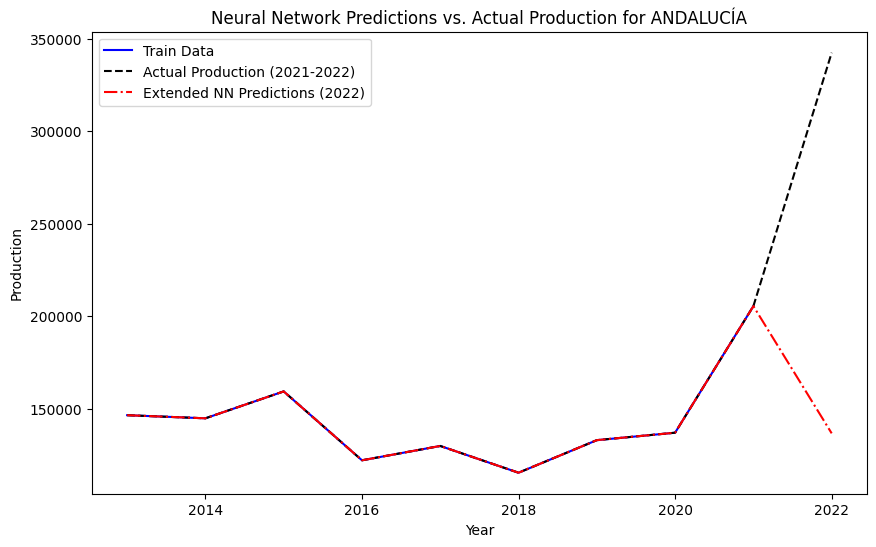

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


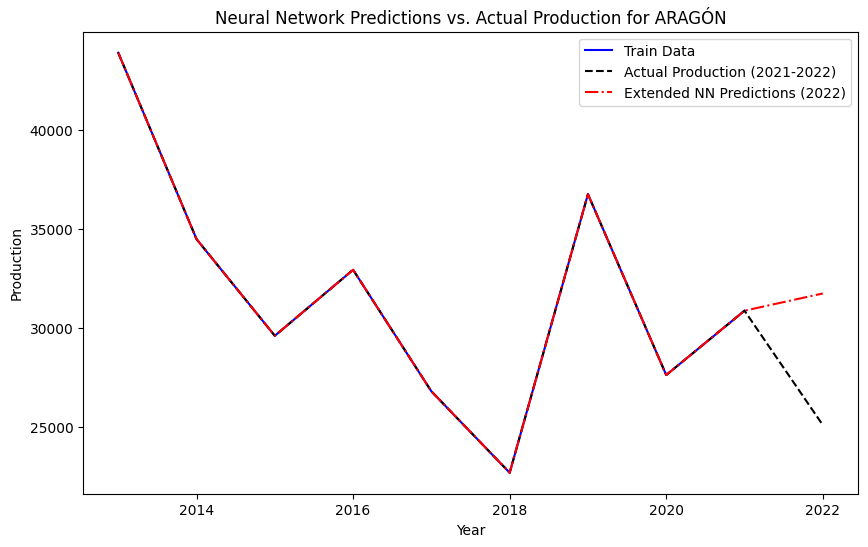

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


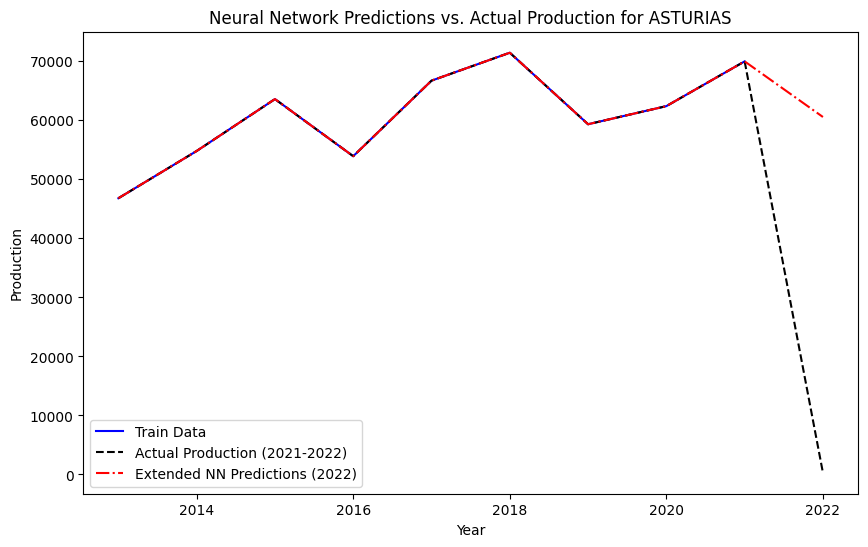

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


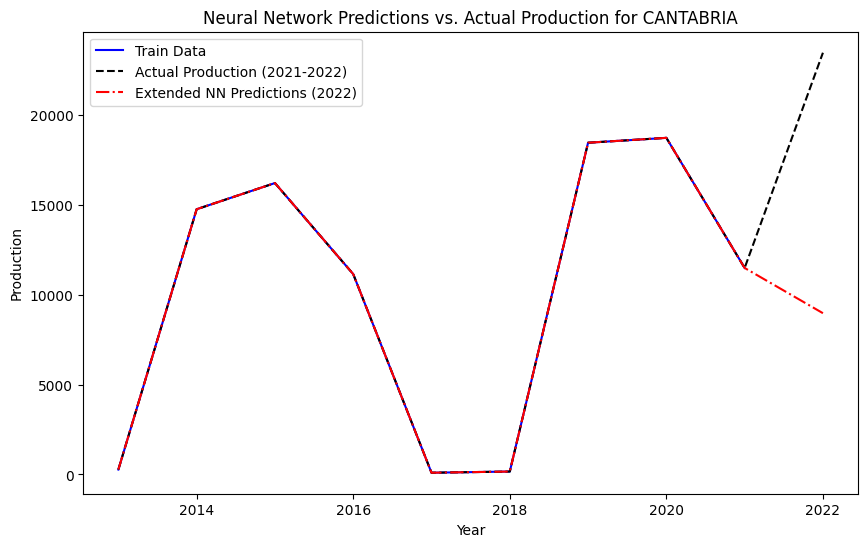

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


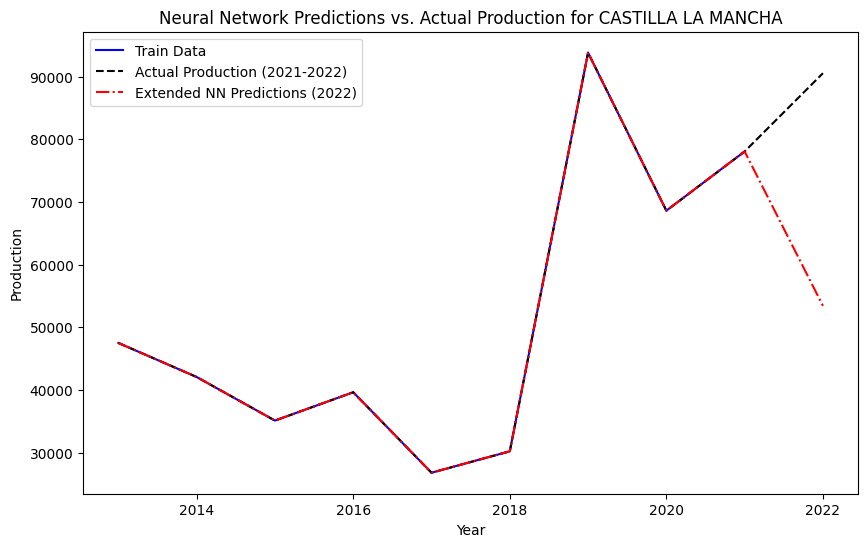

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


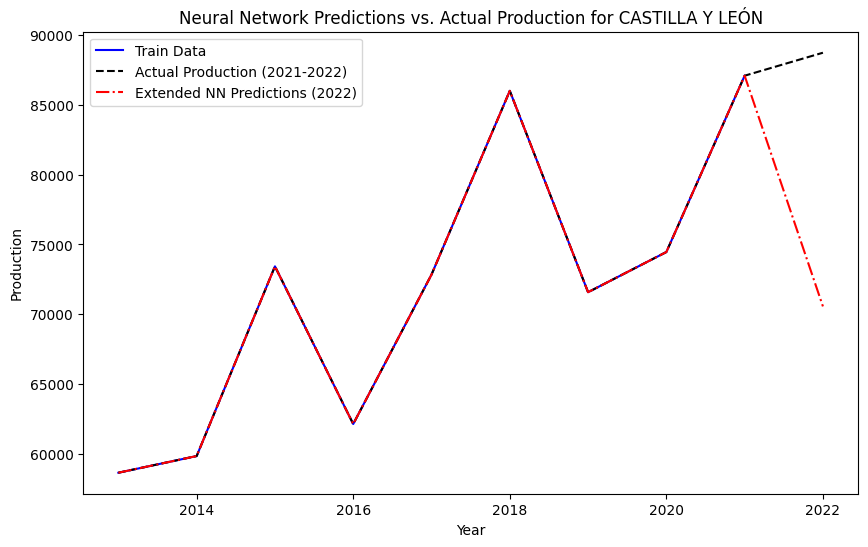

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


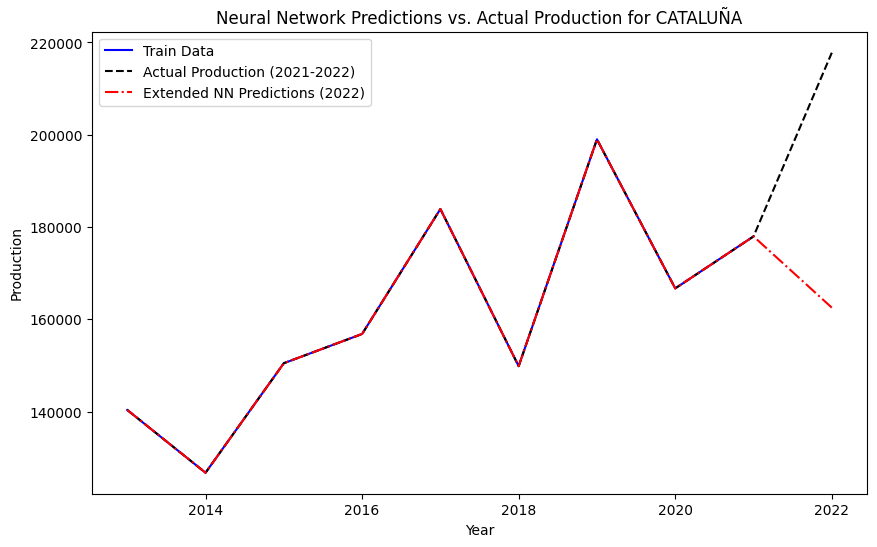

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


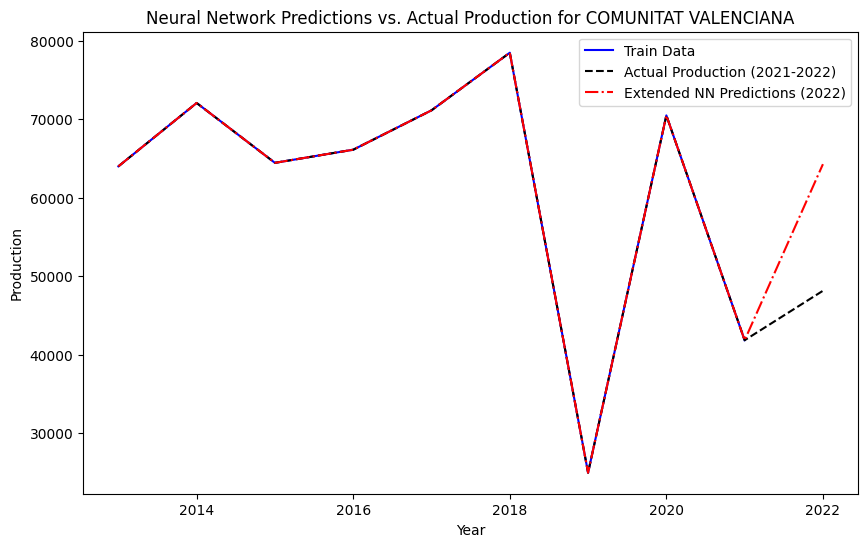

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


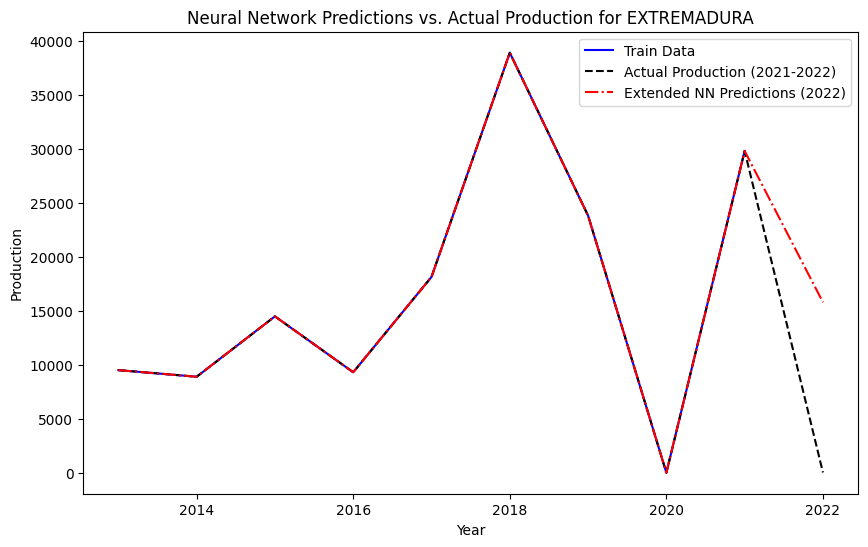

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


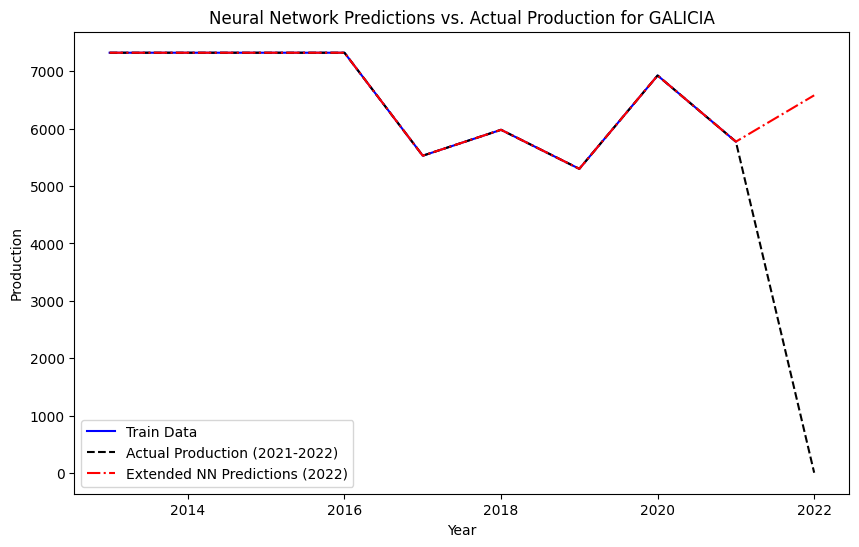

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


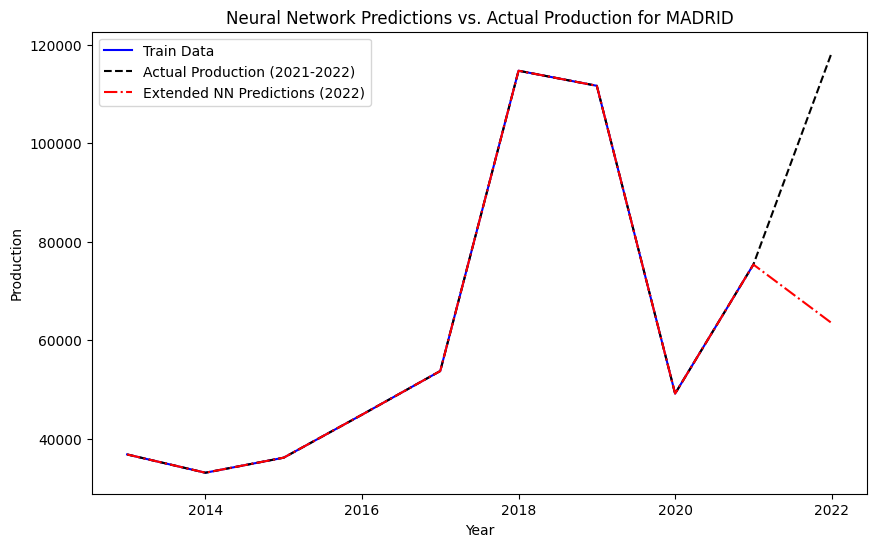

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


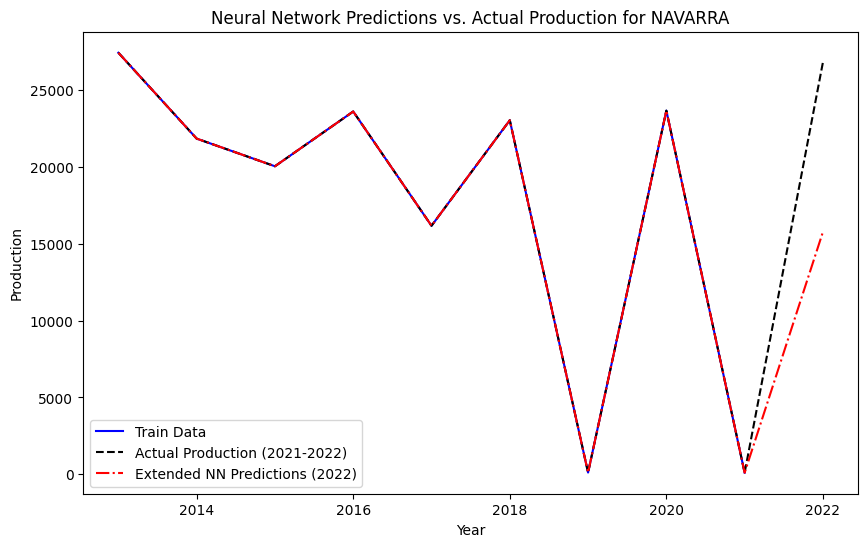

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([7, 1])) that is different to the input size (torch.Size([7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


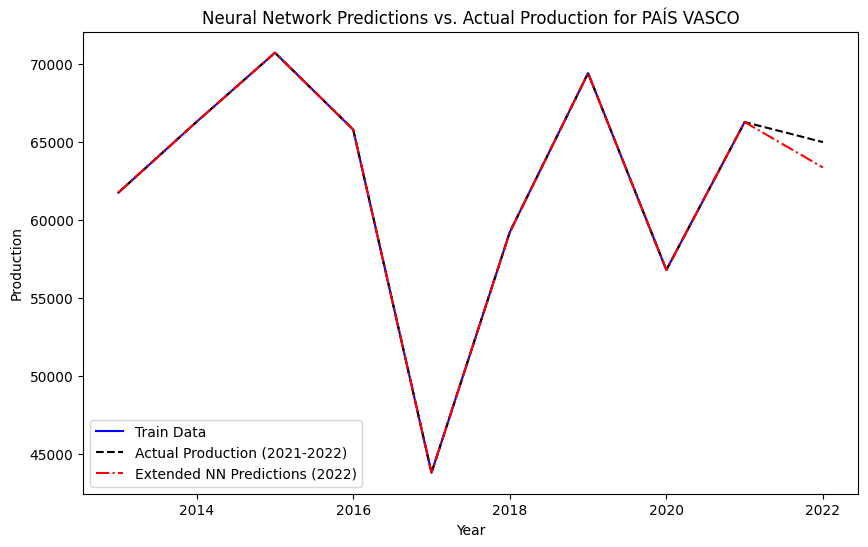

In [ ]:
errores_nn = []
#train and obtain CCAA predictions
for ccaa in df_nn['comunidad_autonoma'].unique():
    ccaa_data = df_nn[df_nn['comunidad_autonoma'] == ccaa].sort_values('año')

    for lag in range(1, 4):
        ccaa_data[f'produccion_lag_{lag}'] = ccaa_data['produccion_ccaa'].shift(lag)
        ccaa_data[f'PIB_lag_{lag}'] = ccaa_data['PIB'].shift(lag)

    ccaa_data = ccaa_data.dropna(subset=[f'produccion_lag_{lag}' for lag in range(1, 4)] + [f'PIB_lag_{lag}' for lag in range(1, 4)])

    train = ccaa_data[ccaa_data['año'] < 2022]
    test = ccaa_data[ccaa_data['año'] == 2022]

    X_train = train[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
                     'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
    y_train = train['produccion_ccaa']

    X_test = test[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
                   'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
    y_test = test['produccion_ccaa']

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

    X_test_scaled = scaler_X.transform(X_test)
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

    model = NeuralNet(num_layers=2)
    _, trained_model = train_model(model, X_train_tensor, y_train_tensor, epochs=100)

    with torch.no_grad():
        y_pred_test_scaled = trained_model(X_test_tensor)
        y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    errores_nn.append({
        'comunidad_autonoma': ccaa,
        'mape_nn': mape,
        'rmse_nn': rmse
    })

    #visualisation
    extended_predictions = list(y_pred_test.flatten())
    extended_predictions = list(train['produccion_ccaa']) + extended_predictions  # Añadir datos de entrenamiento a las predicciones

    extended_years = list(train['año']) + list(test['año'])
    extended_production = list(train['produccion_ccaa']) + list(test['produccion_ccaa'])

    plt.figure(figsize=(10, 6))
    plt.plot(train['año'], train['produccion_ccaa'], label='Train Data', color='blue')
    plt.plot(extended_years, extended_production, label='Actual Production (2021-2022)', color='black', linestyle='--')
    plt.plot(extended_years, extended_predictions, label='Extended NN Predictions (2022)', color='red', linestyle='-.')

    plt.xlabel('Year')
    plt.ylabel('Production')
    plt.title(f'Neural Network Predictions vs. Actual Production for {ccaa}')
    plt.legend()
    plt.show()

errores_nn_pib_df = pd.DataFrame(errores_nn)

In [ ]:
errores_nn_pib_df

,comunidad_autonoma,mape_nn,rmse_nn
0,ANDALUCÍA,60.055932,205657.070838
1,ARAGÓN,26.485501,6649.586160
2,ASTURIAS,20011.851678,60257.452672
3,CANTABRIA,61.764466,14507.504101
4,CASTILLA LA MANCHA,40.988055,37107.722190
5,CASTILLA Y LEÓN,20.477222,18170.716501
6,CATALUÑA,25.366138,55243.170533
7,COMUNITAT VALENCIANA,33.518190,16135.569573
8,EXTREMADURA,28003.868670,15766.744872
9,GALICIA,149997.921076,6578.425267


## NN - BY YEARS


In [ ]:
df_nn = df_ccaa.copy()

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_layers=[64, 32]):
        super(NeuralNet, self).__init__()
        self.hidden_layers = nn.ModuleList()

        prev_size = input_size
        for hidden_size in hidden_layers:
            self.hidden_layers.append(nn.Linear(prev_size, hidden_size))
            prev_size = hidden_size

        self.output_layer = nn.Linear(prev_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        for hidden_layer in self.hidden_layers:
            x = self.relu(hidden_layer(x))
        x = self.output_layer(x)
        return x

model = NeuralNet(input_size=X_train.shape[1], hidden_layers=[64, 32])

In [ ]:
for lag in range(1, 4):
    df_nn[f'produccion_lag_{lag}'] = df_nn['produccion_ccaa'].shift(lag)
    df_nn[f'PIB_lag_{lag}'] = df_nn['PIB'].shift(lag)

df_nn = df_nn.dropna(subset=[f'produccion_lag_{lag}' for lag in range(1, 4)] + [f'PIB_lag_{lag}' for lag in range(1, 4)])

predicciones_totales = []
errores_totales = []

for año in sorted(df_nn['año'].unique()):
    if df_nn[df_nn['año'] < año].shape[0] < 3:
        print(f"Se omite el año {año} porque no tiene suficientes datos previos para los lags.")
        continue

    df_año = df_nn[df_nn['año'] == año]

    train = df_nn[df_nn['año'] < año]

    test = df_año

    X_train = train[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
                     'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
    y_train = train['produccion_ccaa']

    X_test = test[['produccion_lag_1', 'produccion_lag_2', 'produccion_lag_3',
                   'PIB_lag_1', 'PIB_lag_2', 'PIB_lag_3']]
    y_test = test['produccion_ccaa']

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

    X_test_scaled = scaler_X.transform(X_test)
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    model = NeuralNet(input_size=X_train.shape[1], hidden_layers=[64, 32]) #example configuration
    _, trained_model = train_model(model, X_train_tensor, y_train_tensor, epochs=100)

    with torch.no_grad():
        y_pred_scaled = trained_model(torch.tensor(X_test_scaled, dtype=torch.float32))
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    predicciones_totales.append({
        'año': año,
        'produccion_predicha': y_pred.flatten()[0],
        'produccion_real': y_test.values.flatten()[0]
    })

    error_abs_porcentual = np.abs((y_test.values.flatten() - y_pred.flatten()) / y_test.values.flatten()) * 100
    medape = np.median(error_abs_porcentual)
    rmse = np.sqrt(np.mean((y_test.values.flatten() - y_pred.flatten()) ** 2))

    errores_totales.append({
        'año': año,
        'MeDAPE NN': medape,
        'RMSE NN': rmse
    })

predicciones_df = pd.DataFrame(predicciones_totales)
errors_nn_years = pd.DataFrame(errores_totales)

Se omite el año 2007 porque no tiene suficientes datos previos para los lags.


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([9, 1])) that is different to the input size (torch.Size([9])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([3, 1])) that is different to the input size (torch.Size([3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([19, 1])) that is different to the input size (torch.Size([19])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, tar

In [ ]:
errors_nn_years

,año,MeDAPE NN,RMSE NN
0,2008,123.540580,75424.008820
1,2009,60.930591,57100.350458
2,2010,65.280403,59736.880108
3,2011,59.888422,61426.687938
4,2012,67.280389,55250.160692
5,2013,76.576444,52471.638455
6,2014,49.663008,44546.303106
7,2015,103.356164,56047.768586
8,2016,63.594106,44618.420779
9,2017,62.852675,52102.001911


# ARIMA - AutoRegressive Integrated Moving Average

Is it stationary?

In [ ]:
df_ccaa

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa,PIB
0,ANDALUCIA,2007,A13,ANDALUCÍA,6,3.664278e+09,284687.118023,46650000,149010277
1,ANDALUCIA,2008,A13,ANDALUCÍA,6,3.562673e+09,261767.592021,39675000,152247439
2,ANDALUCIA,2009,A13,ANDALUCÍA,6,3.040801e+09,233187.669157,29850000,145802256
3,ANDALUCIA,2010,A13,ANDALUCÍA,6,3.210433e+09,169346.960186,36600000,145853901
4,ANDALUCIA,2011,A13,ANDALUCÍA,6,2.834643e+09,206491.439358,27550000,144494494
...,...,...,...,...,...,...,...,...,...
203,NORTE,2018,P5,PAÍS VASCO,3,1.085488e+09,59207.228595,16400000,20235995
204,NORTE,2019,P5,PAÍS VASCO,3,7.406115e+08,69387.734366,14225000,21070268
205,NORTE,2020,P5,PAÍS VASCO,3,7.954808e+08,56786.986195,12775000,19160726
206,NORTE,2021,P5,PAÍS VASCO,3,9.758621e+08,66255.290453,16200000,20821017


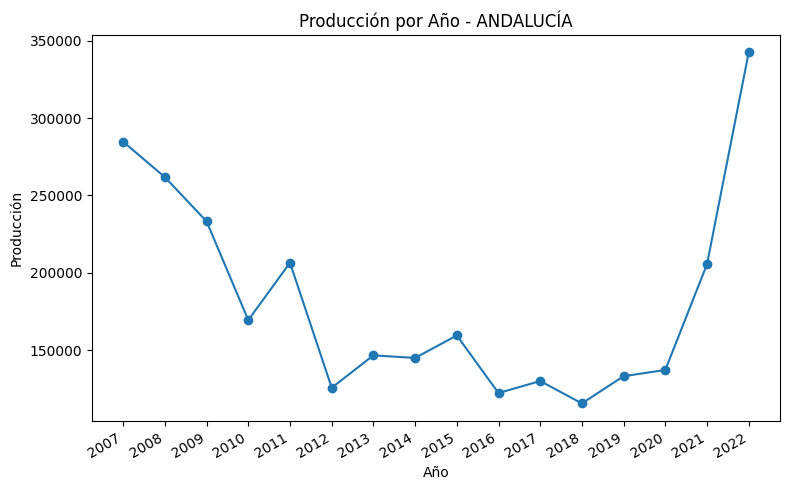

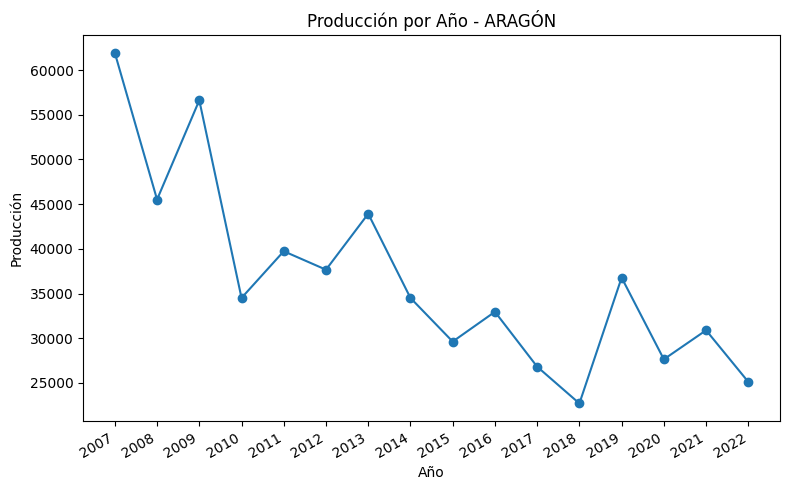

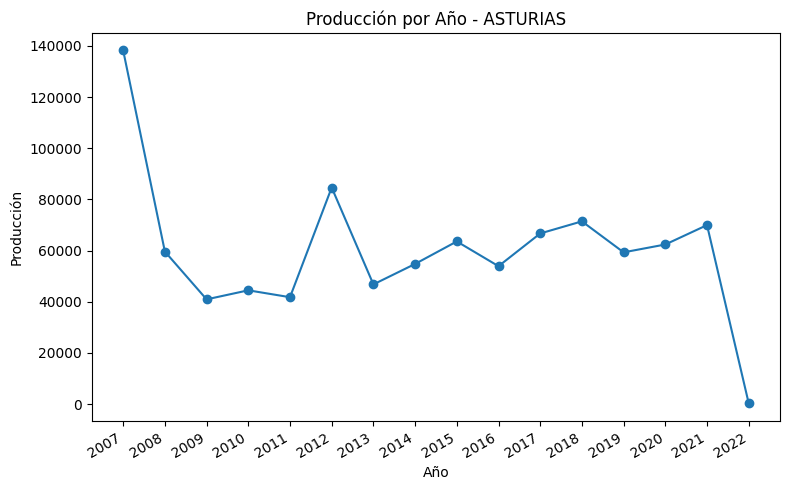

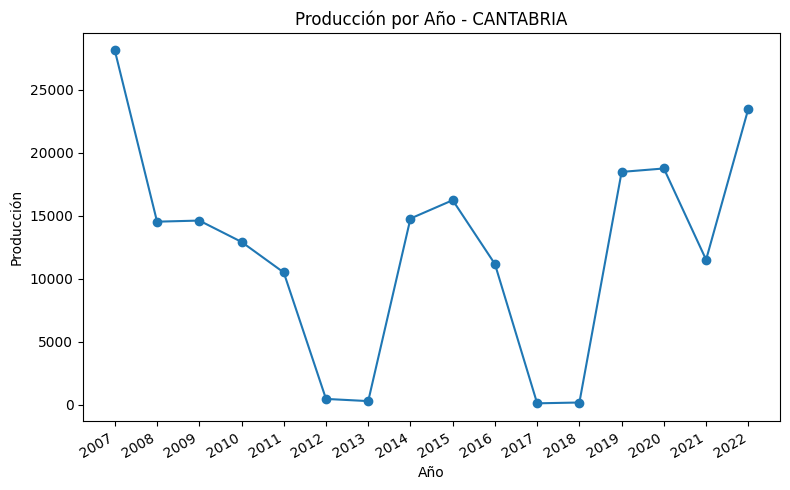

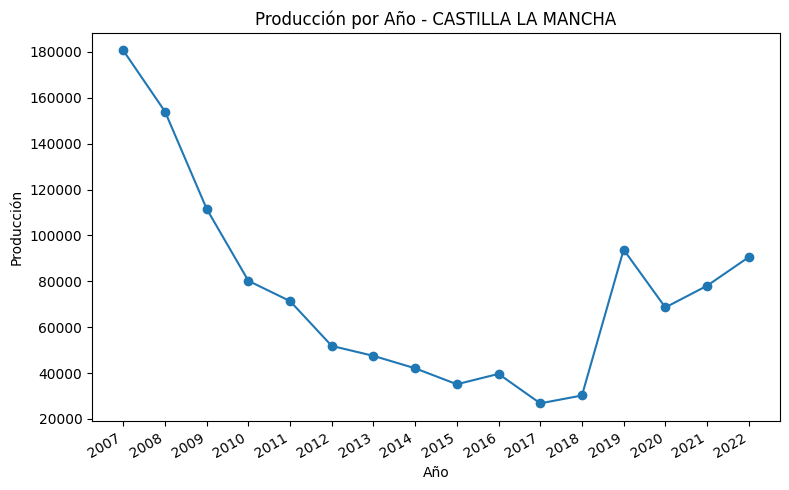

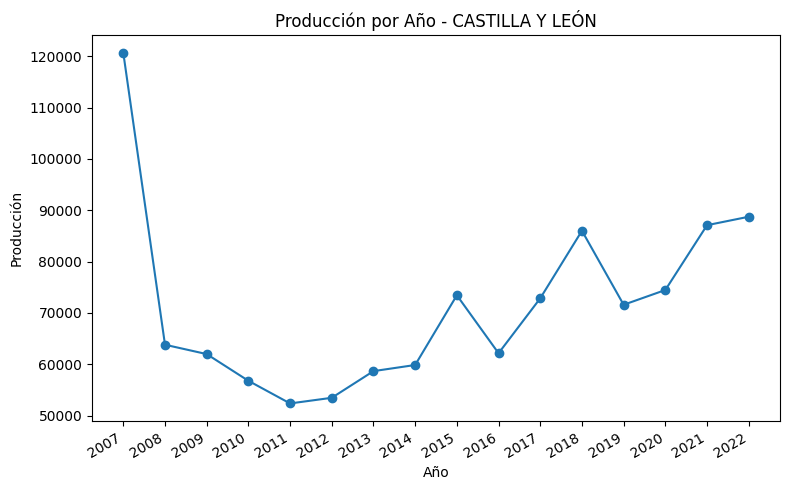

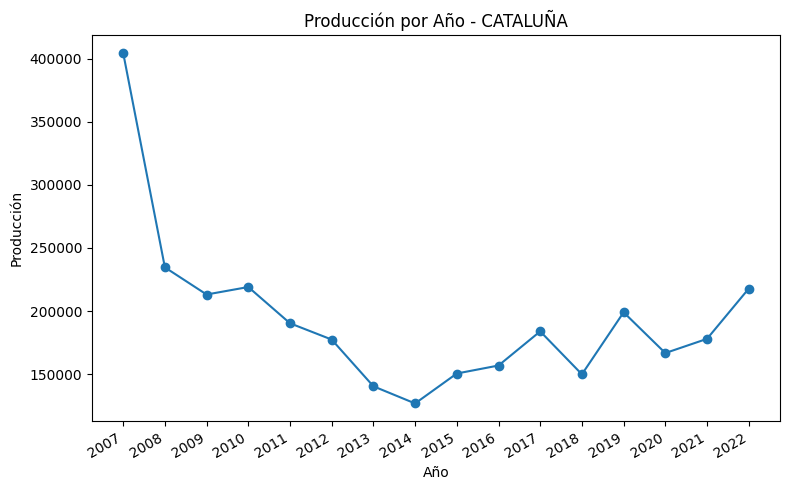

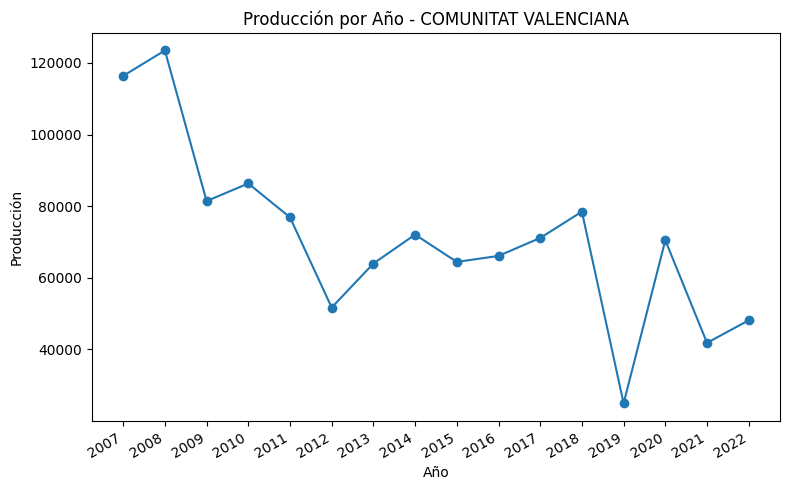

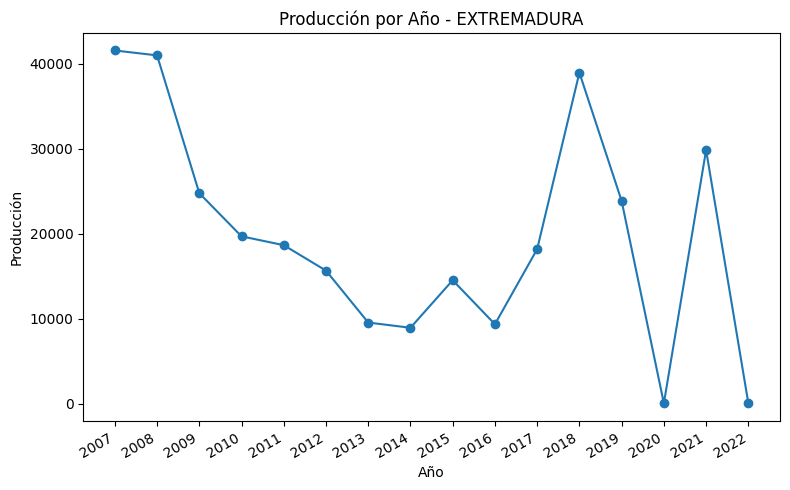

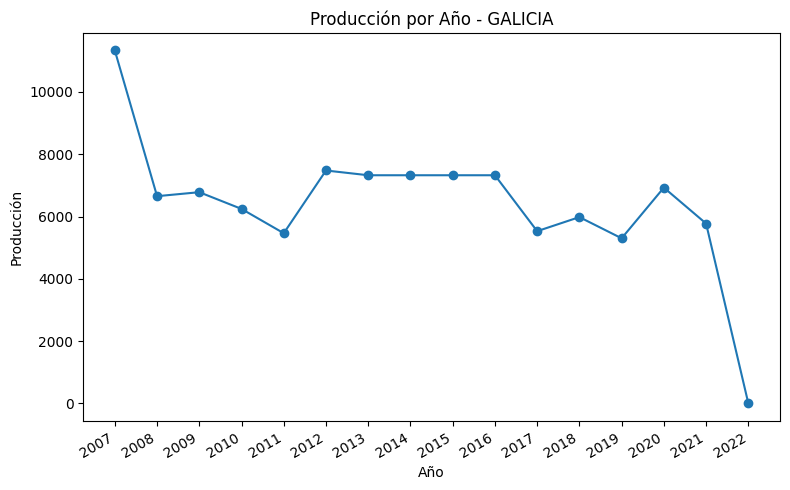

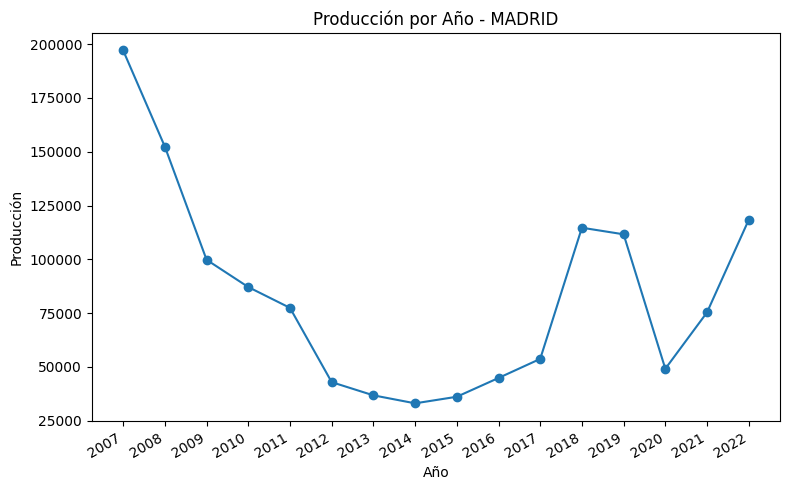

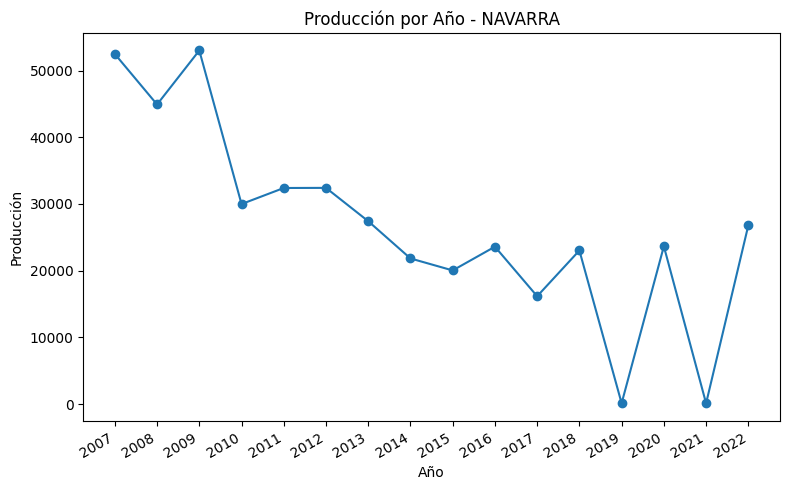

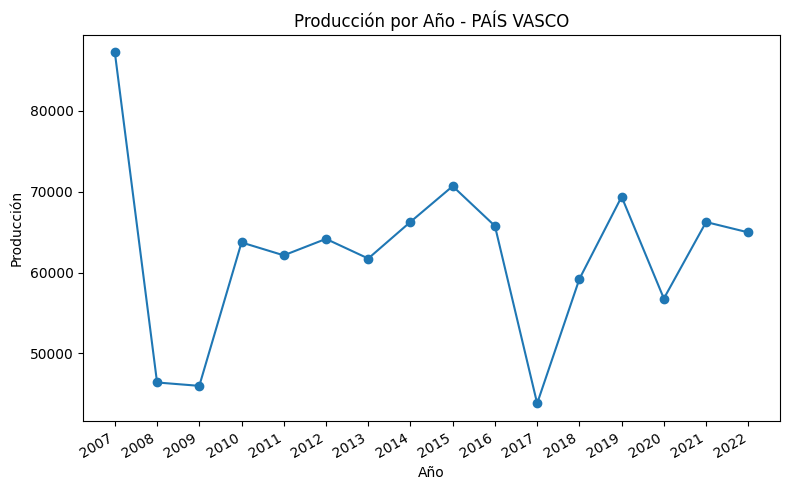

In [ ]:
for ccaa in df_ccaa['comunidad_autonoma'].unique():
    df_arima = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_arima['año'], df_arima['produccion_ccaa'], marker='o')
    ax.set_title(f'Producción por Año - {ccaa}')
    ax.set_xlabel('Año')
    ax.set_ylabel('Producción')

    años_unicos = sorted(df_arima['año'].unique())
    ax.set_xticks(años_unicos)
    ax.set_xticklabels(años_unicos, rotation=45)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [ ]:
for ccaa in df_ccaa['comunidad_autonoma'].unique():
    serie = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')['produccion_ccaa']

    try:
        ADF_result = adfuller(serie)
        print(f"--- {ccaa} ---")
        print(f"ADF Statistic: {ADF_result[0]:.4f}")
        print(f"p-value: {ADF_result[1]:.4f}")
        print()
    except Exception as e:
        print(f"Error analizando {ccaa}: {e}")

--- ANDALUCÍA ---
ADF Statistic: 0.3370
p-value: 0.9790

--- ARAGÓN ---
ADF Statistic: -2.9570
p-value: 0.0391

--- ASTURIAS ---
ADF Statistic: -4.7019
p-value: 0.0001

--- CANTABRIA ---
ADF Statistic: 5.1864
p-value: 1.0000

--- CASTILLA LA MANCHA ---
ADF Statistic: -3.0290
p-value: 0.0323

--- CASTILLA Y LEÓN ---
ADF Statistic: -21.0558
p-value: 0.0000

--- CATALUÑA ---
ADF Statistic: -0.9133
p-value: 0.7836

--- COMUNITAT VALENCIANA ---
ADF Statistic: -0.4000
p-value: 0.9101

--- EXTREMADURA ---
ADF Statistic: -10.6550
p-value: 0.0000

--- GALICIA ---
ADF Statistic: -2.0255
p-value: 0.2755

--- MADRID ---
ADF Statistic: -3.7613
p-value: 0.0033

--- NAVARRA ---
ADF Statistic: -2.3046
p-value: 0.1705

--- PAÍS VASCO ---
ADF Statistic: -2.2384
p-value: 0.1926



Applying differencing so all are stationary: p-value < 0.05

In [ ]:
for ccaa in df_ccaa['comunidad_autonoma'].unique():
    serie = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')['produccion_ccaa']
    diff = np.diff(serie, n=7)

    try:
        ADF_result = adfuller(diff)
        print(f"--- {ccaa} ---")
        print(f"ADF Statistic: {ADF_result[0]:.4f}")
        print(f"p-value: {ADF_result[1]}")
        print()
    except Exception as e:
        print(f"Error analizando {ccaa}: {e}")

--- ANDALUCÍA ---
ADF Statistic: -8.8040
p-value: 2.0749576075890796e-14

--- ARAGÓN ---
ADF Statistic: -10.3454
p-value: 2.6193283109181183e-18

--- ASTURIAS ---
ADF Statistic: -8.4910
p-value: 1.3136954284281053e-13

--- CANTABRIA ---
ADF Statistic: -7.3447
p-value: 1.0426997029546062e-10

--- CASTILLA LA MANCHA ---
ADF Statistic: -5.5931
p-value: 1.3157005248200693e-06

--- CASTILLA Y LEÓN ---
ADF Statistic: -6.6084
p-value: 6.4676347789945555e-09

--- CATALUÑA ---
ADF Statistic: -7.7421
p-value: 1.0554003981883941e-11

--- COMUNITAT VALENCIANA ---
ADF Statistic: -3.4068
p-value: 0.010730442039922279

--- EXTREMADURA ---
ADF Statistic: -3.1968
p-value: 0.02017149920732113

--- GALICIA ---
ADF Statistic: -44.6641
p-value: 0.0

--- MADRID ---
ADF Statistic: -4.8553
p-value: 4.258417684434181e-05

--- NAVARRA ---
ADF Statistic: -10.3102
p-value: 3.1995320040871334e-18

--- PAÍS VASCO ---
ADF Statistic: -5.9169
p-value: 2.560756244986049e-07



<Figure size 800x400 with 0 Axes>

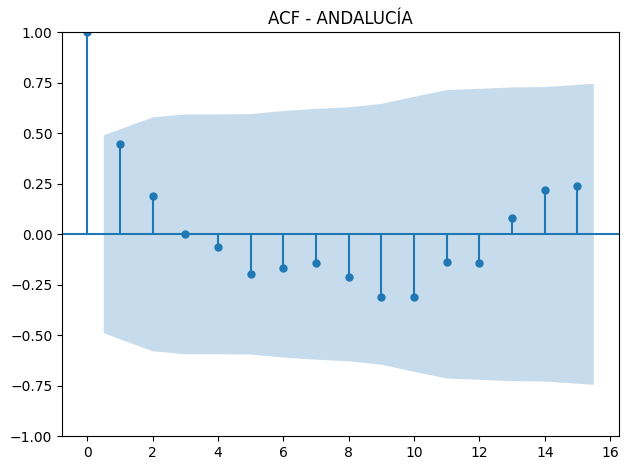

<Figure size 800x400 with 0 Axes>

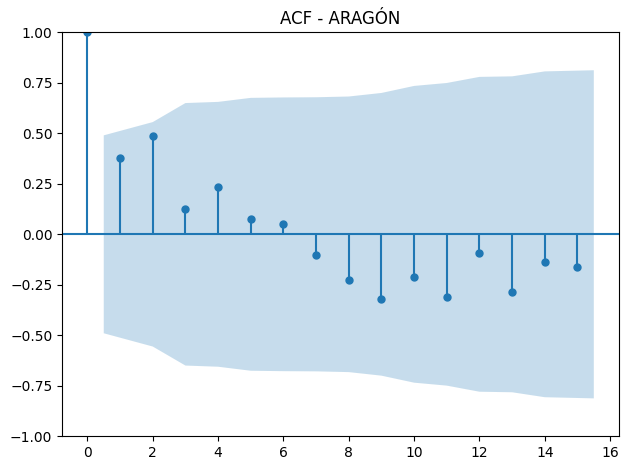

<Figure size 800x400 with 0 Axes>

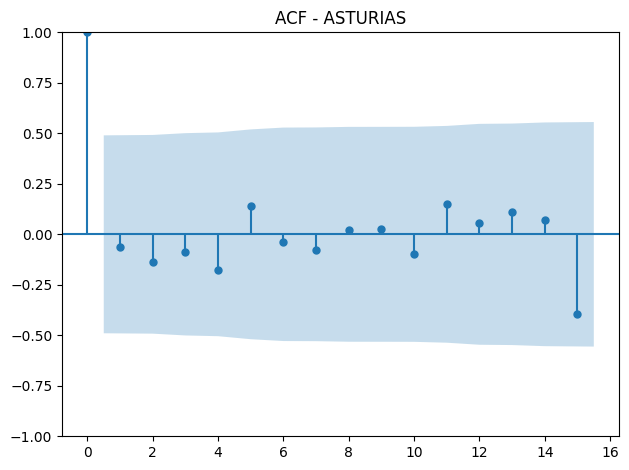

<Figure size 800x400 with 0 Axes>

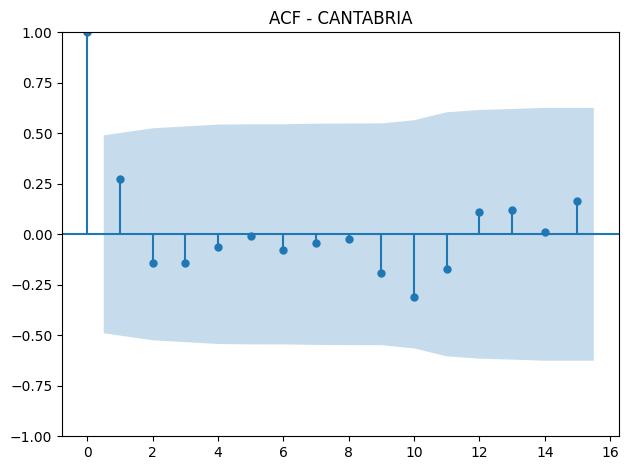

<Figure size 800x400 with 0 Axes>

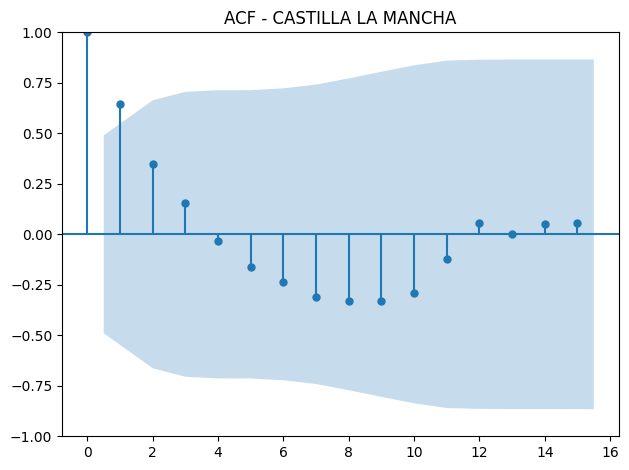

<Figure size 800x400 with 0 Axes>

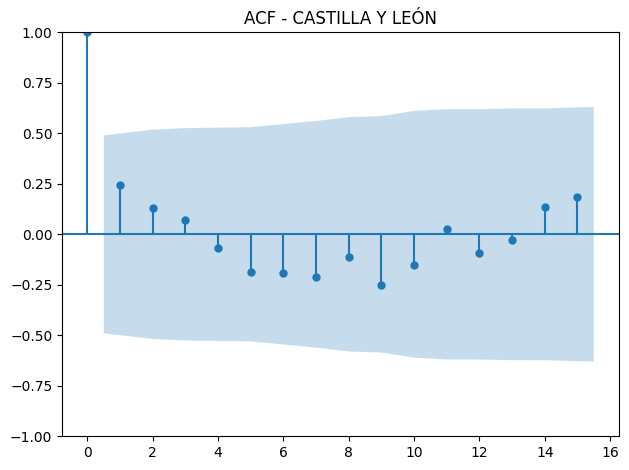

<Figure size 800x400 with 0 Axes>

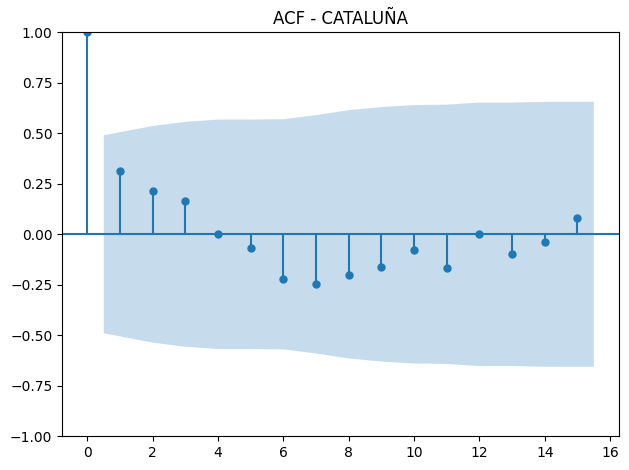

<Figure size 800x400 with 0 Axes>

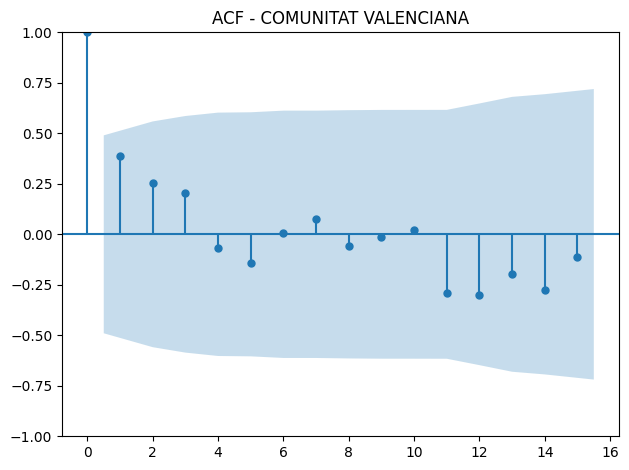

<Figure size 800x400 with 0 Axes>

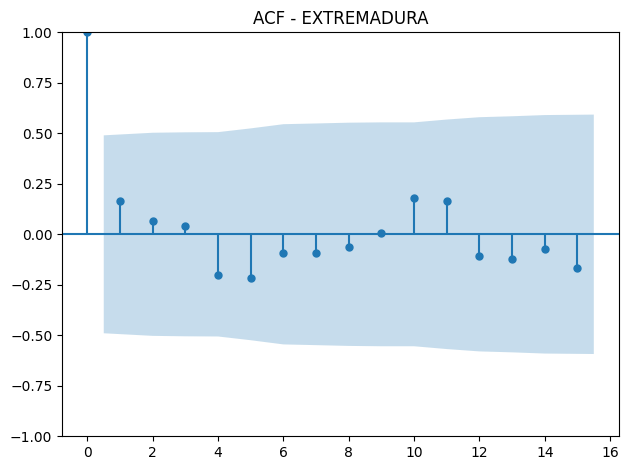

<Figure size 800x400 with 0 Axes>

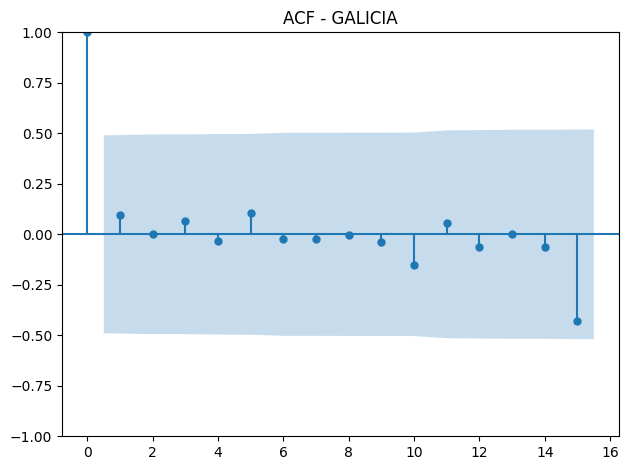

<Figure size 800x400 with 0 Axes>

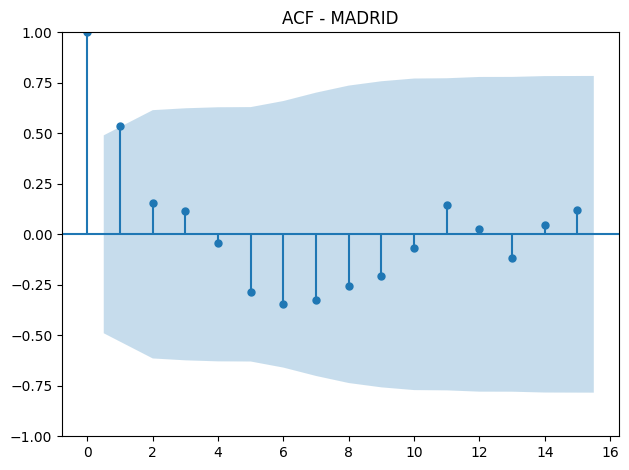

<Figure size 800x400 with 0 Axes>

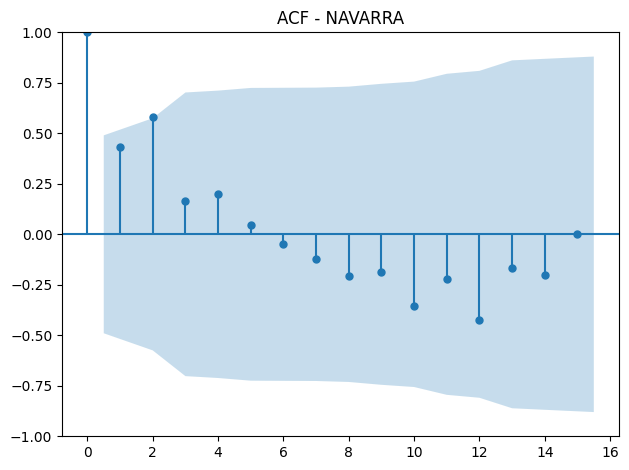

<Figure size 800x400 with 0 Axes>

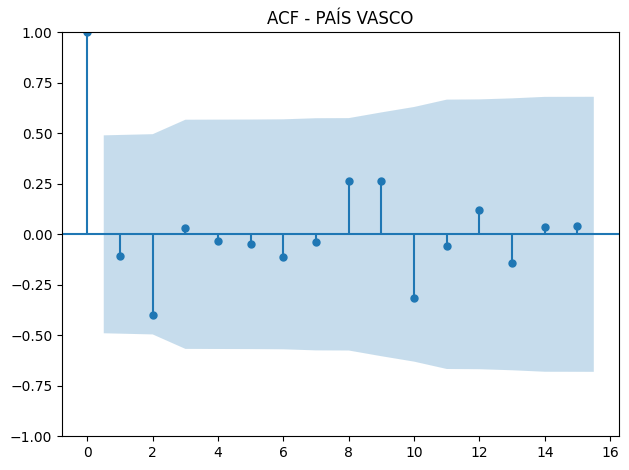

In [ ]:
max_lags = 15

for ccaa in df_ccaa['comunidad_autonoma'].unique():
    serie = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')['produccion_ccaa']

    if len(serie) > max_lags:
        plt.figure(figsize=(8, 4))
        plot_acf(serie, lags=max_lags, alpha=0.05)
        plt.title(f'ACF - {ccaa}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"[SKIPPED] {ccaa} only has {len(serie)} years of data.")


In [ ]:
results_arima = []
for ccaa in df_ccaa['comunidad_autonoma'].unique():
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa]
    train_ccaa = ccaa_data[ccaa_data['año'] < 2022]['produccion_ccaa']
    test_ccaa = ccaa_data[ccaa_data['año'] == 2022]['produccion_ccaa']

    #find optimal ARIMA order (p, d, q)
    stepwise_model = auto_arima(train_ccaa, start_p=1, start_q=1,
                               max_p=3, max_q=3, m=12,
                               start_P=0, seasonal=True,
                               d=None, D=0, trace=True,
                               error_action='ignore',
                               suppress_warnings=True,
                               stepwise=True)
    print(stepwise_model.order)
    (p,d,q) = stepwise_model.order

    try:
        model = ARIMA(train_ccaa, order=(p,d,q))
        model_fit = model.fit()
        predictions = model_fit.predict(start=len(train_ccaa), end=len(train_ccaa) + len(test_ccaa)-1)
        rmse = np.sqrt(mean_squared_error(test_ccaa, predictions))
        mape = np.median(np.abs((test_ccaa.values - predictions.values) / test_ccaa.values)) * 100

        results_arima.append({
            'comunidad_autonoma': ccaa,
            'mape_arima': mape,
            'rmse_arima': rmse,
            'predictions': predictions
        })
    except Exception as e:
        print(f"Error fitting ARIMA model for {ccaa}: {e}")
        results_arima.append({
            'comunidad_autonoma': ccaa,
            'rmse': None,
            'mape': None,
            'predictions': None
        })

errors_arima_df = pd.DataFrame(results_arima)
errors_arima_df

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=372.379, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=364.495, Time=0.12 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=407.493, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=366.208, Time=0.06 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=376.036, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=326.681, Time=0.03 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=326.308, Time=0.03 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=328.308, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=328.262, Time=0.02 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=337.986, Time=0.02 sec

Best model:  ARIMA(0,0,0)(0,0,0)[12] intercept
Total fit time: 1.144 seconds
(0, 0, 0)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `star

,comunidad_autonoma,mape_arima,rmse_arima,predictions
0,ANDALUCÍA,47.708841,163375.377980,15 179067.182104 dtype: float64
1,ARAGÓN,11.833037,2970.863218,15 28077.377809 dtype: float64
2,ASTURIAS,21127.066817,63615.463942,15 63916.572773 dtype: float64
3,CANTABRIA,51.036893,11987.765387,15 11500.665728 dtype: float64
4,CASTILLA LA MANCHA,14.208120,12863.039566,15 77669.976423 dtype: float64
5,CASTILLA Y LEÓN,20.733050,18397.728029,15 70338.509239 dtype: float64
6,CATALUÑA,11.498610,25042.032521,15 192741.101815 dtype: float64
7,COMUNITAT VALENCIANA,13.095269,6304.028613,15 41835.71222 dtype: float64
8,EXTREMADURA,37118.197050,20898.296229,15 20954.598253 dtype: float64
9,GALICIA,156118.072441,6846.835376,15 6851.221054 dtype: float64


ARIMA WITH BEST PARAMETERS FOR EACH CCAA

In [ ]:
p = q = range(0, 4)
#(p,q) combinations
order_list = list(product(p, q))

def optimize_ARMA(endog, order_list, d):
    results = []
    for order in order_list:
        try:
            model = ARIMA(endog, order=(order[0], d, order[1]))
            model_fit = model.fit()
            aic = model_fit.aic
            results.append([order, aic])
        except:
            continue

    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

#d using ADF test
def determine_differencing(series):
    adf_result = adfuller(series)
    p_value = adf_result[1]
    return 0 if p_value < 0.05 else 1

results_arima = []

for ccaa in df_ccaa['comunidad_autonoma'].unique():
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')
    train_ccaa = ccaa_data[ccaa_data['año'] < 2022]['produccion_ccaa']
    test_ccaa = ccaa_data[ccaa_data['año'] == 2022]['produccion_ccaa']

    try:
        d = determine_differencing(train_ccaa)

        result_df = optimize_ARMA(train_ccaa, order_list, d)
        best_order = result_df.iloc[0]['(p,q)']
        p, q = best_order

        model = ARIMA(train_ccaa, order=(p, d, q))
        model_fit = model.fit()

        predictions = model_fit.predict(start=len(train_ccaa), end=len(train_ccaa) + len(test_ccaa)-1, typ="levels")

        rmse = np.sqrt(mean_squared_error(test_ccaa, predictions))
        mape = np.median(np.abs((test_ccaa.values - predictions.values) / test_ccaa.values)) * 100

        results_arima.append({
            'comunidad_autonoma': ccaa,
            'mape_arima': mape,
            'rmse_arima': rmse,
            'p': p,
            'd': d,
            'q': q,
            'predictions': predictions.values
        })

    except Exception as e:
        print(f"Error fitting ARIMA for {ccaa}: {e}")
        results_arima.append({
            'comunidad_autonoma': ccaa,
            'mape_arima': None,
            'rmse_arima': None,
            'p': None,
            'd': None,
            'q': None,
            'predictions': None
        })

errores_arima_df = pd.DataFrame(results_arima)
errores_arima_df

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning

,comunidad_autonoma,mape_arima,rmse_arima,p,d,q,predictions
0,ANDALUCÍA,46.078678,157793.003424,1,1,3,[184649.55665971237]
1,ARAGÓN,49.169897,12344.847276,2,0,3,[37451.361865729996]
2,ASTURIAS,19944.003704,60053.156431,0,1,1,[60354.26526234126]
3,CANTABRIA,56.733639,13325.841625,0,1,2,[10162.589489469865]
4,CASTILLA LA MANCHA,19.188017,17371.490273,1,1,1,[73161.52571690897]
5,CASTILLA Y LEÓN,10.422093,9248.173067,0,1,1,[79488.064200921]
6,CATALUÑA,19.517029,42504.797898,1,1,2,[175278.3364384682]
7,COMUNITAT VALENCIANA,12.192253,5869.319208,1,1,1,[54009.06004063502]
8,EXTREMADURA,62785.263857,35349.374354,0,1,2,[35405.67637827554]
9,GALICIA,156118.072441,6846.835376,0,0,0,[6851.2210539769485]


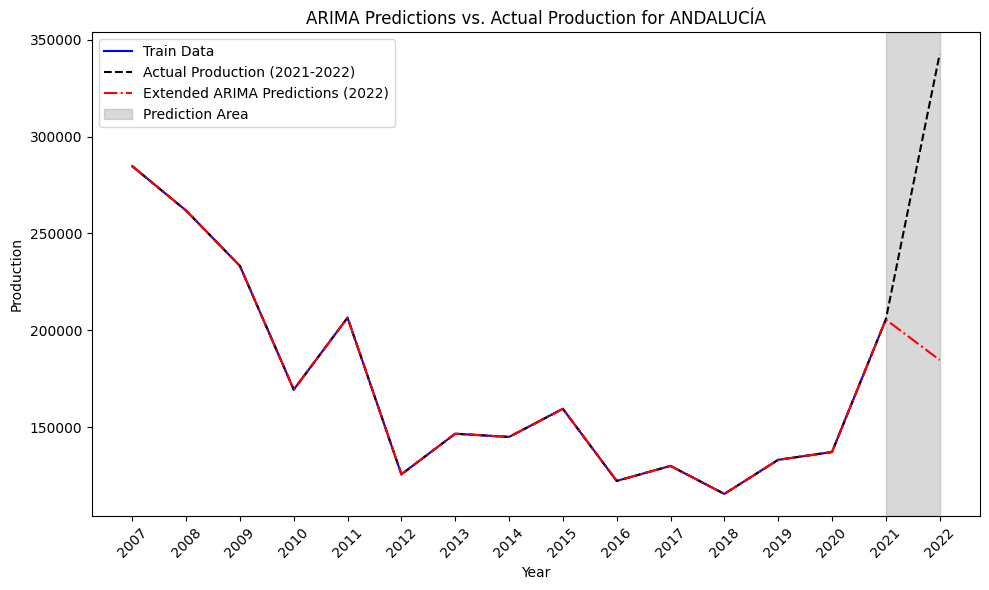

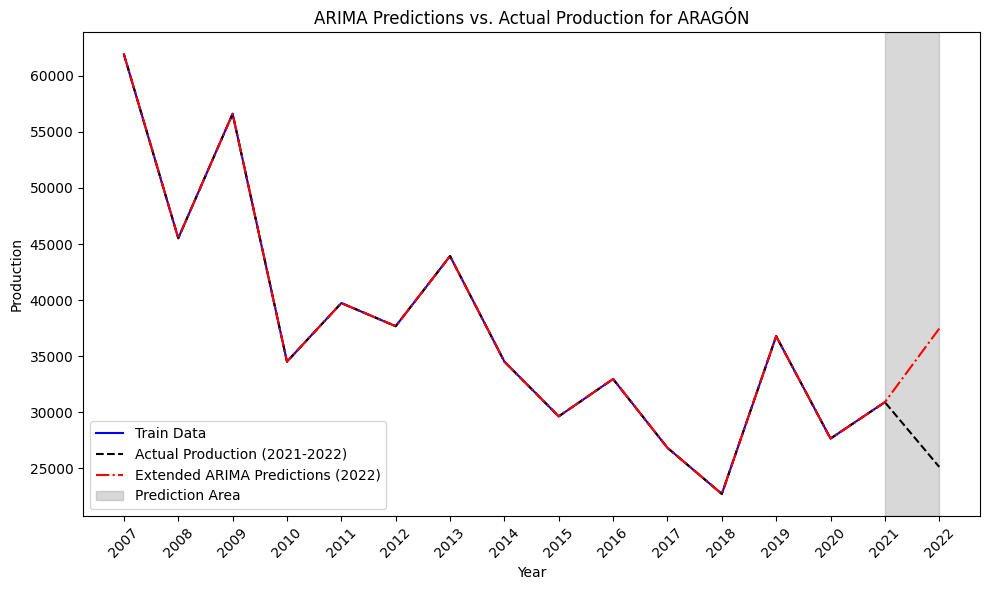

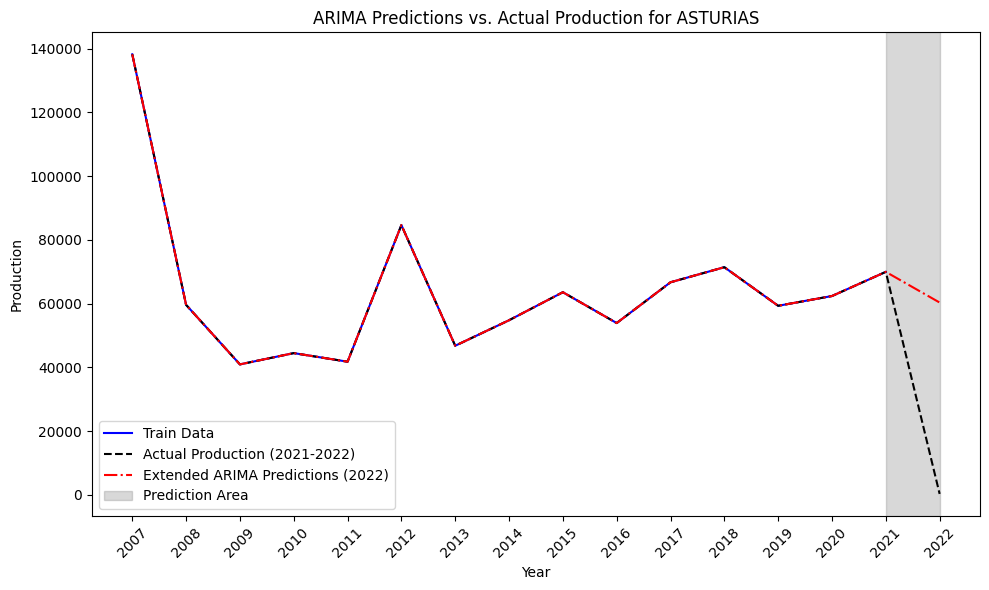

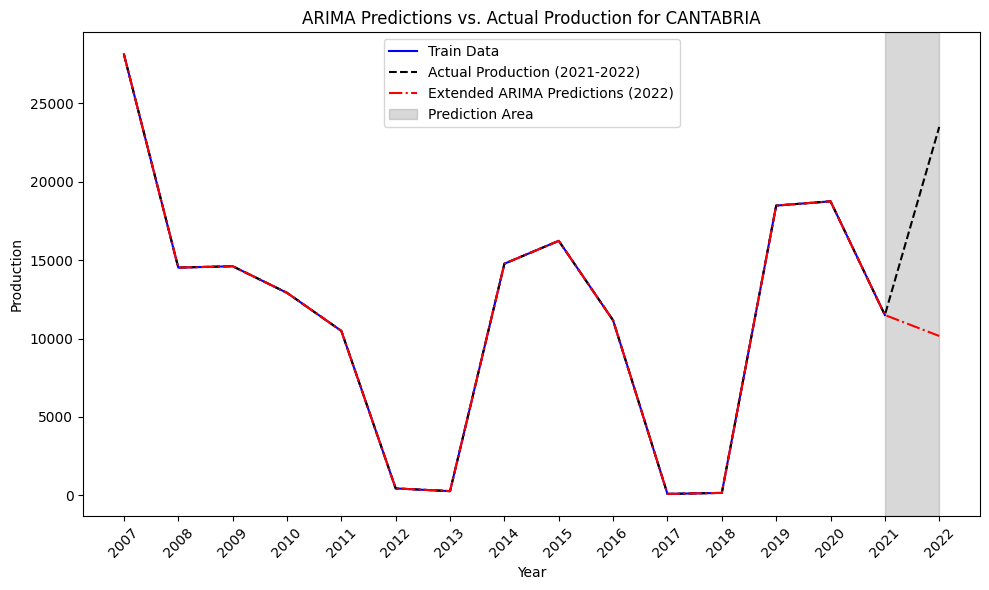

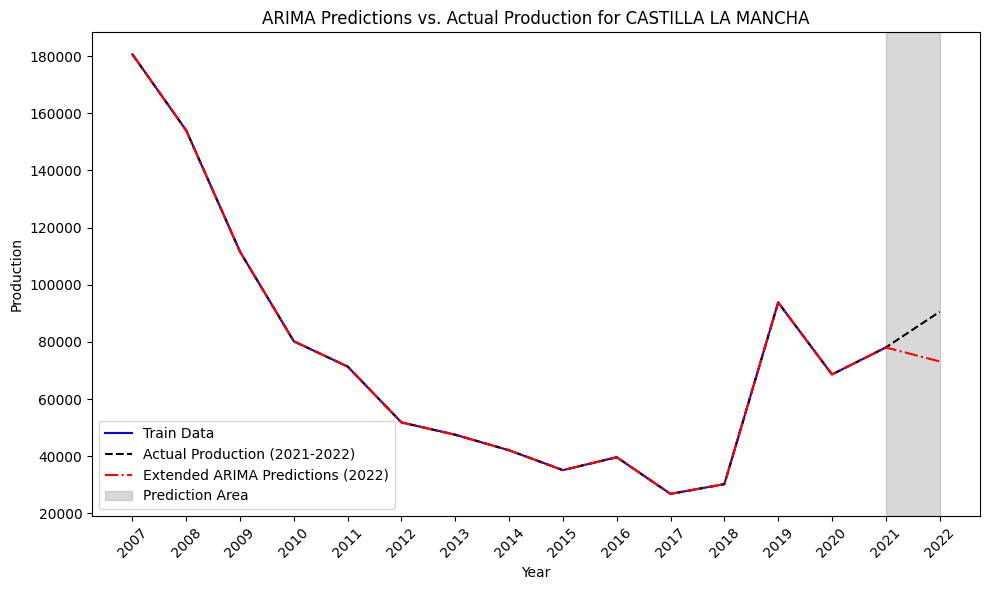

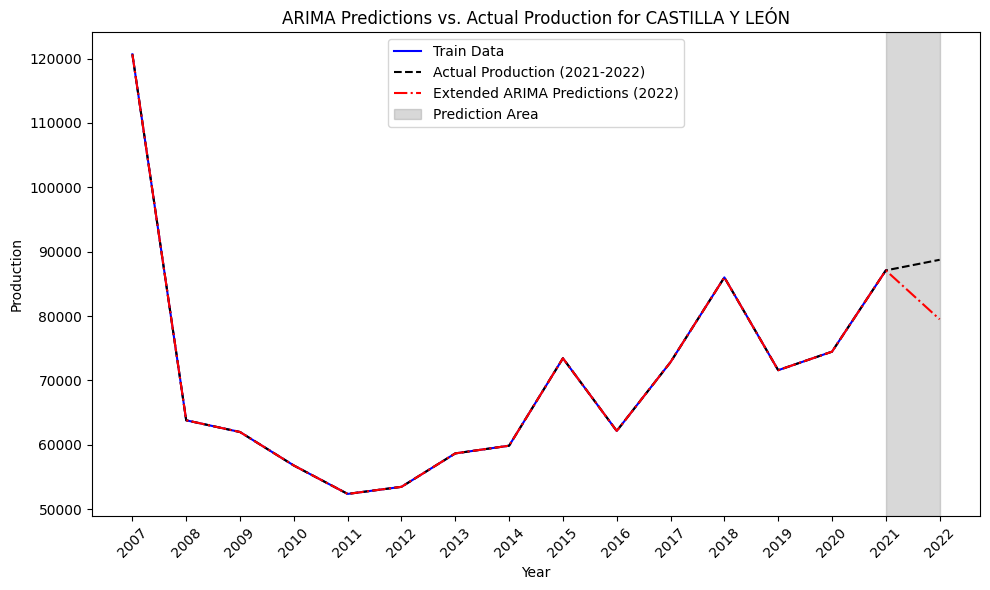

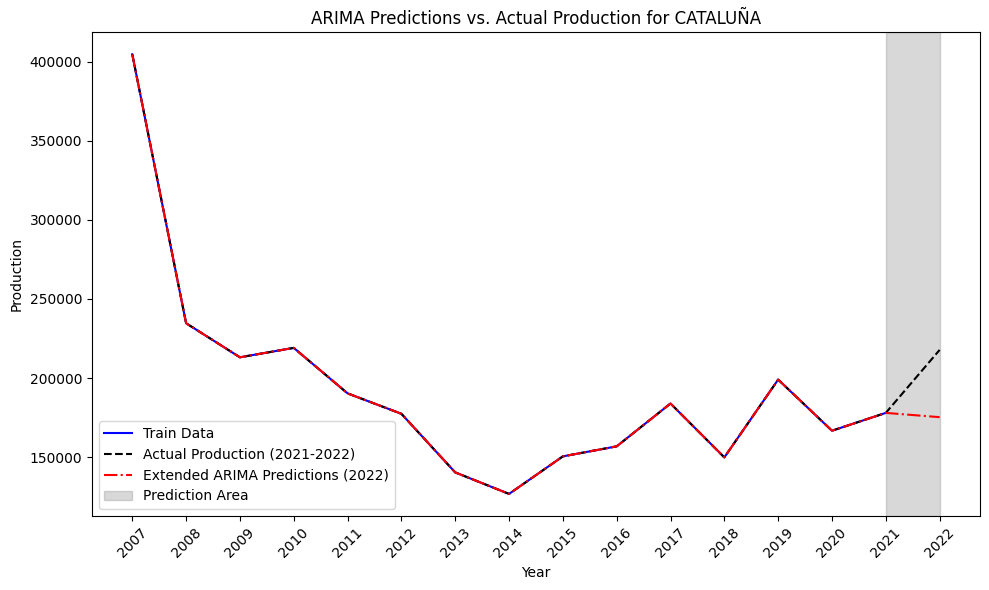

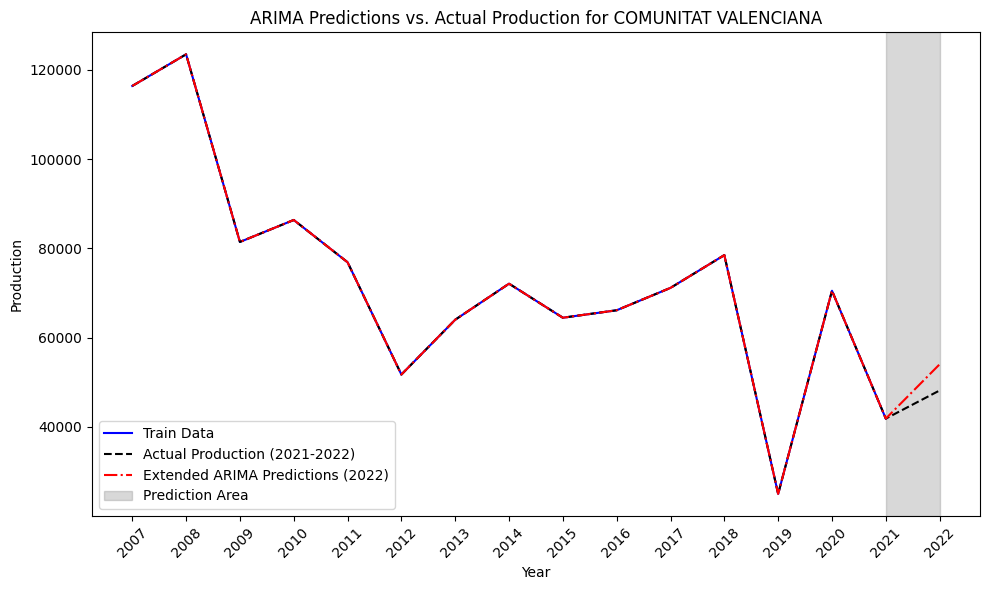

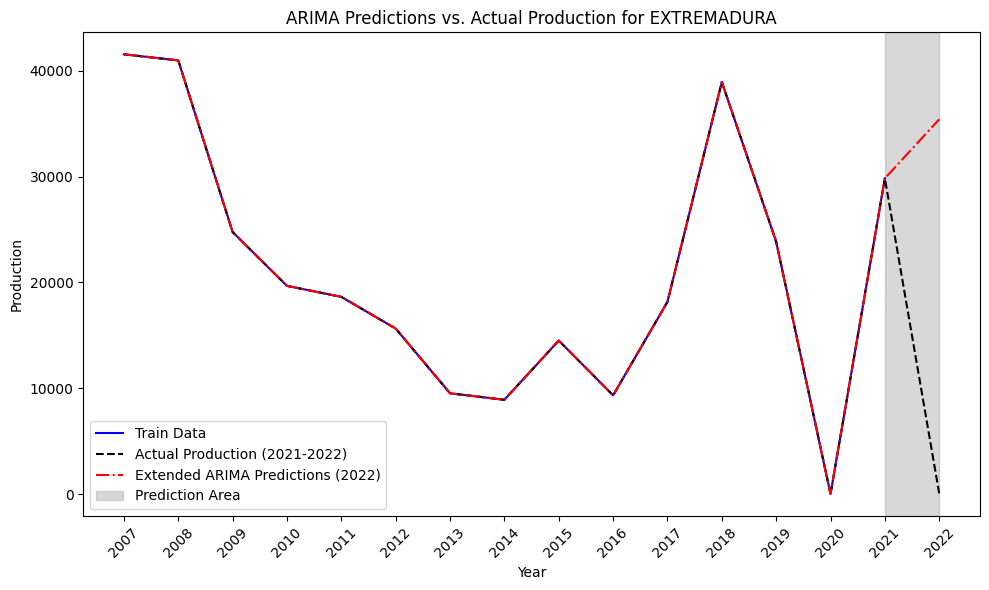

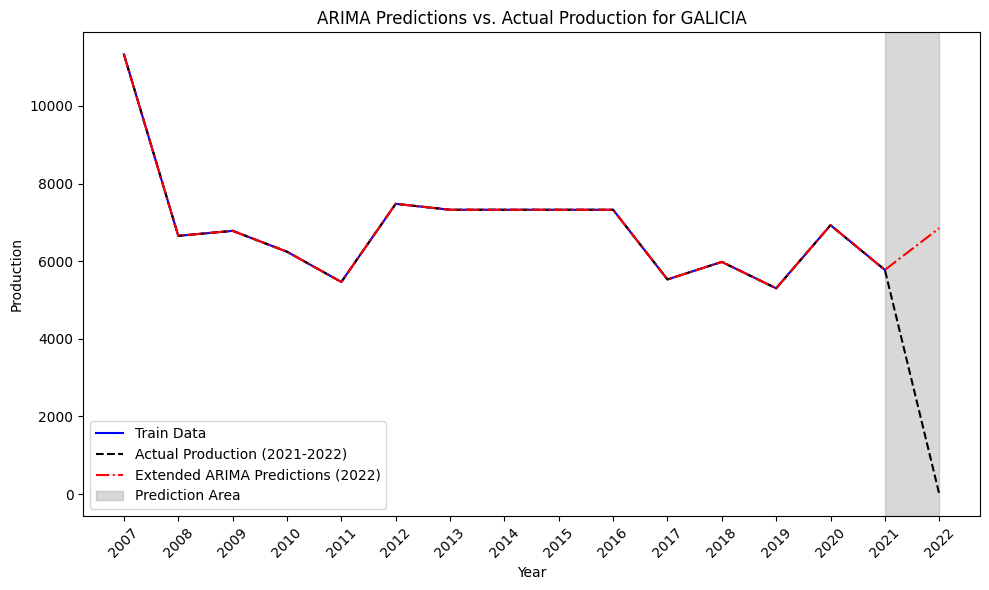

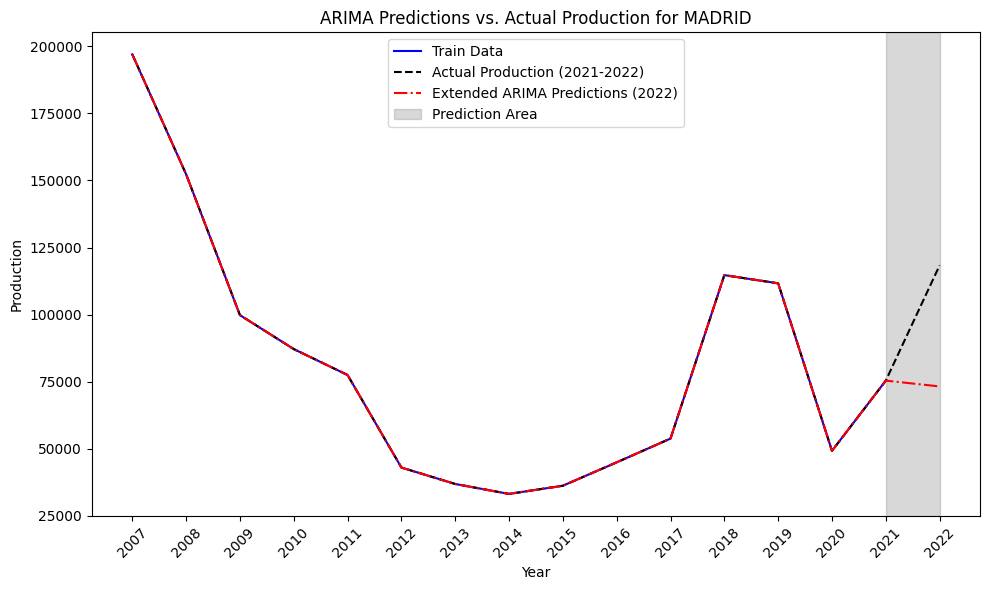

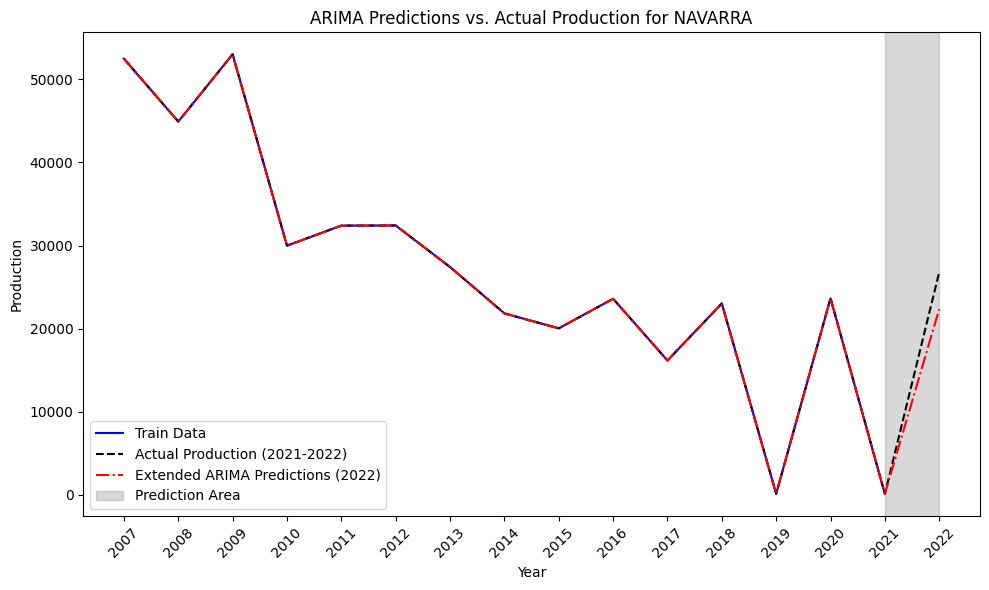

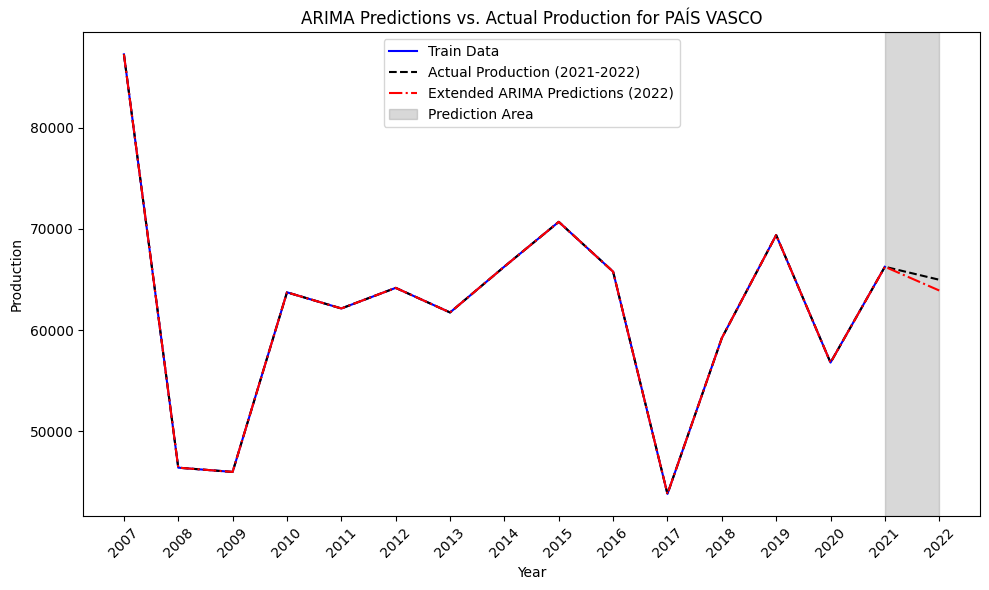

In [ ]:
def visualize_arima_predictions(errores_arima_df, df):
    for index, row in errores_arima_df.iterrows():
        ccaa = row['comunidad_autonoma']
        predictions = row['predictions']

        if predictions is not None:
            predictions = list(np.ravel(predictions))

            ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa]
            train_ccaa = ccaa_data[ccaa_data['año'] < 2022]
            test_ccaa = ccaa_data[ccaa_data['año'] == 2022]

            extended_years = list(train_ccaa['año']) + list(test_ccaa['año'])
            extended_production = list(train_ccaa['produccion_ccaa']) + list(test_ccaa['produccion_ccaa'])

            extended_predictions = list(train_ccaa['produccion_ccaa']) + predictions

            plt.figure(figsize=(10, 6))
            plt.plot(train_ccaa['año'], train_ccaa['produccion_ccaa'], label='Train Data', color='blue')
            plt.plot(extended_years, extended_production, label='Actual Production (2021-2022)', color='black', linestyle='--')
            plt.plot(extended_years, extended_predictions, label='Extended ARIMA Predictions (2022)', color='red', linestyle='-.')
            plt.axvspan(2021, 2022, color='gray', alpha=0.3, label="Prediction Area")
            plt.xticks(extended_years, rotation=45)

            plt.xlabel('Year')
            plt.ylabel('Production')
            plt.title(f'ARIMA Predictions vs. Actual Production for {ccaa}')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print(f"No ARIMA predictions available for {ccaa}.")

visualize_arima_predictions(errores_arima_df, df_ccaa)

In [ ]:
errores_arima_df = errores_arima_df.drop(columns=['p', 'd', 'q','predictions'])

In [ ]:
errores_arima_df

,comunidad_autonoma,mape_arima,rmse_arima
0,ANDALUCÍA,46.078678,157793.003424
1,ARAGÓN,49.169897,12344.847276
2,ASTURIAS,19944.003704,60053.156431
3,CANTABRIA,56.733639,13325.841625
4,CASTILLA LA MANCHA,19.188017,17371.490273
5,CASTILLA Y LEÓN,10.422093,9248.173067
6,CATALUÑA,19.517029,42504.797898
7,COMUNITAT VALENCIANA,12.192253,5869.319208
8,EXTREMADURA,62785.263857,35349.374354
9,GALICIA,156118.072441,6846.835376


In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # %

def medape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

all_preds = []
all_true = []

results_arima = []

for ccaa in df_ccaa['comunidad_autonoma'].unique():
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa]
    train_ccaa = ccaa_data[ccaa_data['año'] < 2022]['produccion_ccaa']
    test_ccaa = ccaa_data[ccaa_data['año'] == 2022]['produccion_ccaa']

    try:
        stepwise_model = auto_arima(train_ccaa, start_p=1, start_q=1,
                                   max_p=3, max_q=3, m=1,
                                   seasonal=False,
                                   d=None, D=0, trace=False,
                                   error_action='ignore',
                                   suppress_warnings=True,
                                   stepwise=True)
        (p, d, q) = stepwise_model.order

        model = ARIMA(train_ccaa, order=(p, d, q))
        model_fit = model.fit()
        predictions = model_fit.predict(start=len(train_ccaa), end=len(train_ccaa) + len(test_ccaa) - 1)

        all_preds.extend(predictions)
        all_true.extend(test_ccaa.values)

        mape_ccaa = mape(test_ccaa, predictions)
        rmse_ccaa = rmse(test_ccaa, predictions)

        std_ccaa = ccaa_data[(ccaa_data['año'] >= 2017) & (ccaa_data['año'] <= 2022)]['produccion_ccaa'].std()

        results_arima.append({
            'comunidad_autonoma': ccaa,
            'mape_arima': mape_ccaa,
            'rmse_arima': rmse_ccaa,
            'std_real_2017_2022': std_ccaa,
            'predictions': predictions
        })

    except Exception as e:
        print(f"Error fitting ARIMA model for {ccaa}: {e}")
        results_arima.append({
            'comunidad_autonoma': ccaa,
            'mape_arima': None,
            'rmse_arima': None,
            'std_real_2017_2022': None,
            'predictions': None
        })

#global errors
all_preds = np.array(all_preds)
all_true = np.array(all_true)

global_mape = mape(all_true, all_preds)
global_medape = medape(all_true, all_preds)
global_rmse = rmse(all_true, all_preds)

global_std = df_ccaa[(df_ccaa['año'] >= 2017) & (df_ccaa['año'] <= 2022)]['produccion_ccaa'].std()

print(f"MAPE global: {global_mape:.2f}%")
print(f"MedAPE global: {global_medape:.2f}%")
print(f"RMSE global: {global_rmse:.2f}")
print(f"Typical deviation 2017-2022: {global_std:.2f}")

df_results_arima = pd.DataFrame(results_arima)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

MAPE global: 16504.47%
MedAPE global: 17.00%
RMSE global: 50662.47
Typical deviation 2017-2022: 62188.76


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `star

Global errors

In [ ]:
errors_arima = []
errors_arima.append({
    'Model': 'ARIMA',
    'mape_arima': global_mape,
    'medape_arima': global_medape,
    'rmse_arima': global_rmse
})
errors_arima = pd.DataFrame(errors_arima)
display(errors_arima)

,Model,mape_arima,medape_arima,rmse_arima
0,ARIMA,16504.474717,16.997084,50662.469585


## LOOCV ON ARIMA


###CCAA

In [ ]:
p = q = range(0, 4)
order_list = list(product(p, q))

def determine_differencing(series):
    adf_result = adfuller(series)
    p_value = adf_result[1]
    return 0 if p_value < 0.05 else 1

def optimize_ARMA(endog, order_list, d):
    results = []
    for order in order_list:
        try:
            model = ARIMA(endog, order=(order[0], d, order[1]))
            model_fit = model.fit()
            aic = model_fit.aic
            results.append([order, aic])
        except:
            continue
    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

#LOOCV-10 years
results_loocv_arima = []

for ccaa in tqdm(df_ccaa['comunidad_autonoma'].unique()):
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')
    años = ccaa_data['año'].values
    produccion = ccaa_data['produccion_ccaa'].values

    mape_list = []
    rmse_list = []
    predicciones = []
    años_validacion = []

    #2017
    for i in range(10, len(produccion)):
        train_y = produccion[i-10:i]
        test_y = produccion[i:i+1]
        año_pred = años[i]

        try:
            d = determine_differencing(train_y)
            best_order = optimize_ARMA(train_y, order_list, d).iloc[0]['(p,q)']
            p_opt, q_opt = best_order

            model = ARIMA(train_y, order=(p_opt, d, q_opt))
            model_fit = model.fit()

            pred = model_fit.forecast(steps=1)[0]
            rmse = np.sqrt(mean_squared_error(test_y, [pred]))
            mape = mean_absolute_percentage_error(test_y, [pred]) * 100

            predicciones.append(pred)
            mape_list.append(mape)
            rmse_list.append(rmse)
            años_validacion.append(año_pred)

        except Exception as e:
            print(f"Error en {ccaa}, año {año_pred}: {e}")
            predicciones.append(np.nan)
            mape_list.append(np.nan)
            rmse_list.append(np.nan)
            años_validacion.append(año_pred)

    for i, año in enumerate(años_validacion):
        results_loocv_arima.append({
            'comunidad_autonoma': ccaa,
            'año': año,
            'prediccion': predicciones[i],
            'mape': mape_list[i],
            'rmse': rmse_list[i]
        })

df_loocv_arima = pd.DataFrame(results_loocv_arima)

  0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lo

In [ ]:
df_loocv_arima

,comunidad_autonoma,año,prediccion,mape,rmse
0,ANDALUCÍA,2017,134094.510048,3.170769,4121.154390
1,ANDALUCÍA,2018,144850.076561,25.398873,29338.610299
2,ANDALUCÍA,2019,129497.133887,2.712811,3610.971794
3,ANDALUCÍA,2020,133108.105681,2.936929,4027.577445
4,ANDALUCÍA,2021,135608.651713,34.019801,69920.664311
...,...,...,...,...,...
73,PAÍS VASCO,2018,59070.024795,0.231735,137.203800
74,PAÍS VASCO,2019,59207.228595,14.671910,10180.505771
75,PAÍS VASCO,2020,69387.734366,22.189500,12600.748170
76,PAÍS VASCO,2021,63641.466234,3.945080,2613.824219


In [ ]:
loocv_df = df_loocv_arima[df_loocv_arima['año'] == 2022].drop(columns=['año']).reset_index(drop=True)
loocv_df

,comunidad_autonoma,prediccion,mape,rmse
0,ANDALUCÍA,205529.316023,39.981375,136913.244060
1,ARAGÓN,30885.691911,23.018636,5779.177321
2,ASTURIAS,53583.060461,17695.247075,53281.951630
3,CANTABRIA,-2411.777696,110.267939,25900.208811
4,CASTILLA LA MANCHA,78049.215779,13.789224,12483.800211
5,CASTILLA Y LEÓN,82416.929054,7.121452,6319.308214
6,CATALUÑA,178776.601986,17.910722,39006.532350
7,COMUNITAT VALENCIANA,60523.818907,25.725270,12384.078074
8,EXTREMADURA,47416.720390,84118.500478,47360.418366
9,GALICIA,6395.566861,145728.476312,6391.181183


In [ ]:
#combine to compare which to stick to
df_resultados_combinado = pd.merge(errores_arima_df, loocv_df, on='comunidad_autonoma', how='outer')

df_resultados_combinado = df_resultados_combinado[[
    'comunidad_autonoma',
    'rmse_arima', 'mape_arima',
    'rmse', 'mape'
]]

df_resultados_combinado.sort_values(by='comunidad_autonoma', inplace=True)
df_resultados_combinado.reset_index(drop=True, inplace=True)
df_resultados_combinado

,comunidad_autonoma,rmse_arima,mape_arima,rmse,mape
0,ANDALUCÍA,157793.003424,46.078678,136913.244060,39.981375
1,ARAGÓN,12344.847276,49.169897,5779.177321,23.018636
2,ASTURIAS,60053.156431,19944.003704,53281.951630,17695.247075
3,CANTABRIA,13325.841625,56.733639,25900.208811,110.267939
4,CASTILLA LA MANCHA,17371.490273,19.188017,12483.800211,13.789224
5,CASTILLA Y LEÓN,9248.173067,10.422093,6319.308214,7.121452
6,CATALUÑA,42504.797898,19.517029,39006.532350,17.910722
7,COMUNITAT VALENCIANA,5869.319208,12.192253,12384.078074,25.725270
8,EXTREMADURA,35349.374354,62785.263857,47360.418366,84118.500478
9,GALICIA,6846.835376,156118.072441,6391.181183,145728.476312


###MEDIAN 2017-2022 - CCAA

In [ ]:
p = q = range(0, 4)
order_list = list(product(p, q))

def determine_differencing(series):
    adf_result = adfuller(series)
    p_value = adf_result[1]
    return 0 if p_value < 0.05 else 1

def optimize_ARMA(endog, order_list, d):
    results = []
    for order in order_list:
        try:
            model = ARIMA(endog, order=(order[0], d, order[1]))
            model_fit = model.fit()
            aic = model_fit.aic
            results.append([order, aic])
        except:
            continue
    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

results_loocv_arima = []

for ccaa in tqdm(df_ccaa['comunidad_autonoma'].unique()):
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')
    años = ccaa_data['año'].values
    produccion = ccaa_data['produccion_ccaa'].values

    predicciones = []
    verdaderos = []
    años_validacion = []

    idx_inicio = np.where(años == 2007)[0][0]

    for i in range(idx_inicio, len(produccion)):
        train_y = produccion[i-10:i]
        test_y = produccion[i:i+1]
        año_pred = años[i]

        try:
            d = determine_differencing(train_y)
            best_order = optimize_ARMA(train_y, order_list, d).iloc[0]['(p,q)']
            p_opt, q_opt = best_order

            model = ARIMA(train_y, order=(p_opt, d, q_opt))
            model_fit = model.fit()

            pred = model_fit.forecast(steps=1)[0]

            results_loocv_arima.append({
                'comunidad_autonoma': ccaa,
                'año': año_pred,
                'prediccion': pred,
                'verdadero': test_y[0]
            })

        except Exception as e:
            print(f"Error en {ccaa}, año {año_pred}: {e}")
            predicciones.append(np.nan)
            verdaderos.append(np.nan)
            años_validacion.append(año_pred)

df_loocv_arima = pd.DataFrame(results_loocv_arima)
df_loocv_arima = df_loocv_arima.dropna()

def calcular_errores(grupo):
    mape = np.median(np.abs((grupo['verdadero'] - grupo['prediccion']) / grupo['verdadero'])) * 100
    rmse = np.sqrt(np.mean((grupo['verdadero'] - grupo['prediccion']) ** 2))
    return pd.Series({'Mediana_MAPE': mape, 'Mediana_RMSE': rmse})

df_errores_mediana = df_loocv_arima.groupby('comunidad_autonoma').apply(calcular_errores).reset_index()
df_errores_mediana['modelo'] = 'LOOCV ARIMA'
df_errores_mediana = df_errores_mediana[['comunidad_autonoma', 'modelo', 'Mediana_MAPE', 'Mediana_RMSE']]
df_errores_mediana

  0%|          | 0/13 [00:00<?, ?it/s]

Error en ANDALUCÍA, año 2007: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2008: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2009: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2010: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2011: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2012: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2013: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2014: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2015: zero-size array to reduction operation maximum which has no identity
Error en ANDALUCÍA, año 2016: zero-size array to reduction operation maximum which has no identity


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lo

Error en ARAGÓN, año 2007: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2008: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2009: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2010: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2011: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2012: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2013: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2014: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2015: zero-size array to reduction operation maximum which has no identity
Error en ARAGÓN, año 2016: zero-size array to reduction operation maximum which has no identity


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too

...

Error en NAVARRA, año 2007: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2008: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2009: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2010: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2011: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2012: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2013: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2014: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2015: zero-size array to reduction operation maximum which has no identity
Error en NAVARRA, año 2016: zero-size array to reduction operation maximum which has no identity


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/lo

Error en PAÍS VASCO, año 2007: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2008: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2009: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2010: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2011: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2012: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2013: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2014: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2015: zero-size array to reduction operation maximum which has no identity
Error en PAÍS VASCO, año 2016: zero-size array to reduction operation maximum which has no identity


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: Conver

,comunidad_autonoma,modelo,Mediana_MAPE,Mediana_RMSE
0,ANDALUCÍA,LOOCV ARIMA,14.284821,63954.585660
1,ARAGÓN,LOOCV ARIMA,29.322584,8095.376017
2,ASTURIAS,LOOCV ARIMA,15.369946,24292.580629
3,CANTABRIA,LOOCV ARIMA,71.646204,11875.806028
4,CASTILLA LA MANCHA,LOOCV ARIMA,30.604716,32108.678503
5,CASTILLA Y LEÓN,LOOCV ARIMA,11.983654,9859.272486
6,CATALUÑA,LOOCV ARIMA,13.942455,30113.225893
7,COMUNITAT VALENCIANA,LOOCV ARIMA,19.175475,28561.169527
8,EXTREMADURA,LOOCV ARIMA,61.845576,25350.779532
9,GALICIA,LOOCV ARIMA,23.322039,2864.970016


###MEDIAN 2007-2022

In [ ]:
p = q = range(0, 4)
order_list = list(product(p, q))

def determine_differencing(series):
    adf_result = adfuller(series)
    p_value = adf_result[1]
    return 0 if p_value < 0.05 else 1

def optimize_ARMA(endog, order_list, d):
    results = []
    for order in order_list:
        try:
            model = ARIMA(endog, order=(order[0], d, order[1]))
            model_fit = model.fit()
            aic = model_fit.aic
            results.append([order, aic])
        except:
            continue
    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

predicciones_totales = []
verdaderos_totales = []
años_validacion_totales = []
comunidad_autonoma_totales = []

for ccaa in tqdm(df_ccaa['comunidad_autonoma'].unique()):
    ccaa_data = df_ccaa[df_ccaa['comunidad_autonoma'] == ccaa].sort_values('año')
    años = ccaa_data['año'].values
    produccion = ccaa_data['produccion_ccaa'].values

    idx_inicio = np.where(años == 2008)[0][0]

    #use as many yeasr as available if there is not 10
    for i in range(idx_inicio, len(produccion)):
        train_y = produccion[max(i-10, 0):i]
        test_y = produccion[i:i+1]
        año_pred = años[i]

        try:
            d = determine_differencing(train_y)
            best_order = optimize_ARMA(train_y, order_list, d).iloc[0]['(p,q)']
            p_opt, q_opt = best_order

            model = ARIMA(train_y, order=(p_opt, d, q_opt))
            model_fit = model.fit()

            pred = model_fit.forecast(steps=1)[0]

            predicciones_totales.append(pred)
            verdaderos_totales.append(test_y[0])
            años_validacion_totales.append(año_pred)
            comunidad_autonoma_totales.append(ccaa)

        except Exception as e:
            predicciones_totales.append(np.nan)
            verdaderos_totales.append(np.nan)
            años_validacion_totales.append(año_pred)
            comunidad_autonoma_totales.append(ccaa)

df_loocv_arima = pd.DataFrame({
    'comunidad_autonoma': comunidad_autonoma_totales,
    'año': años_validacion_totales,
    'prediccion': predicciones_totales,
    'verdadero': verdaderos_totales
})

df_loocv_arima = df_loocv_arima.dropna()

def calcular_errores(grupo):
    mape = np.median(np.abs((grupo['verdadero'] - grupo['prediccion']) / grupo['verdadero'])) * 100
    rmse = np.sqrt(np.mean((grupo['verdadero'] - grupo['prediccion']) ** 2))
    return pd.Series({'Mediana_MAPE': mape, 'Mediana_RMSE': rmse})

df_errores_mediana = df_loocv_arima.groupby('año').apply(calcular_errores).reset_index()
errors_arima_years = df_errores_mediana[['año', 'Mediana_MAPE', 'Mediana_RMSE']]
errors_arima_years

  0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/p

,año,Mediana_MAPE,Mediana_RMSE
0,2011,44.782643,3.985328e+04
1,2012,33.027281,2.156431e+06
2,2013,24.092849,2.251363e+04
3,2014,20.709469,2.908543e+04
4,2015,9.063534,6.182828e+03
5,2016,10.930276,1.568398e+04
6,2017,21.707504,1.121639e+04
7,2018,27.914603,2.156515e+04
8,2019,24.699521,2.928610e+04
9,2020,24.424289,2.451584e+04


#COMPARING ERRORS

## Comparing errors - BY CCAA - predictions for 2022

BY CCAA

In [ ]:
# #safe the dfs
# import os

# output_dir = '/content/drive/My Drive/DataFrames_LR'

# os.makedirs(output_dir, exist_ok=True)

# dfs = {
#     "errores_regresion_gdp_df.xlsx": errores_regresion_gdp_df,
#     "errores_regression_df.xlsx": errores_regression_df,
#     "errors_lr_gdp_df.xlsx": errors_lr_gdp,
#     "errors_lr_df.xlsx": errors_lr,
#     "errors_lr_years_gdp_df.xlsx": errors_lr_years_gdp,
#     "errors_lr_years_no_gdp.xlsx": errors_lr_years_no_gdp
# }

# for filename, df in dfs.items():
#     file_path = os.path.join(output_dir, filename)
#     df.to_excel(file_path, index=False)

In [ ]:
# #safe the dfs
# import os

# output_dir = '/content/drive/My Drive/DataFrames_errors_pib'

# os.makedirs(output_dir, exist_ok=True)

# dfs = {
#     "errores_naive_mean_pib_df.xlsx": errores_naive_mean_pib_df,
#     "errores_naive_tendency_pib_df.xlsx": errores_naive_tendency_pib_df,
#     "errores_nn_pib_df.xlsx": errores_nn_pib_df,
#     "errores_arima_df.xlsx": loocv_df,
# }

# for filename, df in dfs.items():
#     file_path = os.path.join(output_dir, filename)
#     df.to_excel(file_path, index=False)

In [ ]:
#import the dfs
!gdown --id '1-1_6m0CQMslLc3YIrc7qO5z_6d_fryx7' --output arima_22.xlsx
!gdown --id '1-NFGlgixYEMw05ZSJuAx8PyNZtJOcLlc' --output n1_22.xlsx
!gdown --id '1-JLsiQDr76G0A-Y__7jWSo55gCaSvdm7' --output n2_22.xlsx
!gdown --id '1-FLFlLW33O3DoQi5VlrcNl6SpdKj4OGh' --output nn_22.xlsx
!gdown --id '1-QyGA1xPrtxBKNCWyh1QSE6Huh7ROvuP' --output errors_merged_ccaa.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-1_6m0CQMslLc3YIrc7qO5z_6d_fryx7
To: /content/arima_22.xlsx
100% 5.78k/5.78k [00:00<00:00, 14.9MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-NFGlgixYEMw05ZSJuAx8PyNZtJOcLlc
To: /content/n1_22.xlsx
100% 5.59k/5.59k [00:00<00:00, 16.9MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://dri

In [ ]:
errors_arima_22 = pd.read_excel("arima_22.xlsx")
errors_n1_22 = pd.read_excel("n1_22.xlsx")
errors_n2_22 = pd.read_excel("n2_22.xlsx")
errors_nn_22 = pd.read_excel("nn_22.xlsx")

In [ ]:
errors_arima_22.drop(columns=['prediccion'], inplace=True)

In [ ]:
#import the dfs
!gdown --id '1-UrpXHymoH94nusEE-HIeCOSTyHMgGwG' --output rl_gdp_22.xlsx
!gdown --id '1-UnLqNCYFd45YonxAKKFDvWt2oebyk8k' --output rl_22.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-UrpXHymoH94nusEE-HIeCOSTyHMgGwG
To: /content/rl_gdp_22.xlsx
100% 5.59k/5.59k [00:00<00:00, 16.2MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-UnLqNCYFd45YonxAKKFDvWt2oebyk8k
To: /content/rl_22.xlsx
100% 5.59k/5.59k [00:00<00:00, 16.2MB/s]


In [ ]:
errors_rl_gdp_22 = pd.read_excel("rl_gdp_22.xlsx")
errors_rl_22 = pd.read_excel("rl_22.xlsx")

In [ ]:
dfs = [errors_n1_22, errors_n2_22, errors_nn_22, errors_rl_gdp_22, errors_rl_22, errors_arima_22]
errors_merged_ccaa = reduce(lambda left, right: pd.merge(left, right, on='comunidad_autonoma', how='outer'), dfs)
display(errors_merged_ccaa)

,comunidad_autonoma,medape_n1_pib,rmse_n1_pib,medape_n2,rmse_n2,mape_nn,rmse_nn,MedAPE LR with GDP,RMSE LR with GDP,MedAPE LR no GDP,RMSE LR no GDP,mape,rmse
0,ANDALUCÍA,49.815570,170589.713149,53.641244,183690.449142,60.055932,205657.070838,45.631941,156263.186411,46.012919,157567.818653,39.981375,136913.244060
1,ARAGÓN,49.306384,12379.114415,26.669627,6695.813770,26.485501,6649.586160,27.669556,6946.861214,31.235690,7842.193041,23.018636,5779.177321
2,ASTURIAS,21134.095796,63636.628817,21130.435249,63625.606587,20011.851678,60257.452672,18549.389874,55853.851027,19343.917346,58246.243411,17695.247075,53281.951630
3,CANTABRIA,50.981523,11974.759866,30.796237,7233.552830,61.764466,14507.504101,40.722987,9565.190834,56.090395,13174.753904,110.267939,25900.208811
4,CASTILLA LA MANCHA,18.116236,16401.174833,11.418253,10337.288773,40.988055,37107.722190,4.224427,3824.501346,23.548269,21318.957858,13.789224,12483.800211
5,CASTILLA Y LEÓN,20.670987,18342.655810,12.359070,10966.973938,20.477222,18170.716501,16.351940,14510.096206,21.252055,18858.274231,7.121452,6319.308214
6,CATALUÑA,11.401753,24831.095630,16.675822,36317.126968,25.366138,55243.170533,16.244773,35378.375335,20.799002,45296.718862,17.910722,39006.532350
7,COMUNITAT VALENCIANA,51.137042,24617.239266,4.708355,2266.589911,33.518190,16135.569573,8.717208,4196.441181,17.602651,8473.870603,25.725270,12384.078074
8,EXTREMADURA,37151.998899,20917.327354,31730.785056,17865.074232,28003.868670,15766.744872,40810.273255,22977.009861,39530.994797,22256.750196,84118.500478,47360.418366
9,GALICIA,157444.121401,6904.991609,138171.783180,6059.768983,149997.921076,6578.425267,129213.216467,5666.875127,146863.711354,6440.968933,145728.476312,6391.181183


In [ ]:
sns.set(style="whitegrid")

errors22_melt_mape = errors_merged_ccaa.melt(
    id_vars='comunidad_autonoma',
    value_vars=['medape_n1_pib', 'medape_n2', 'mape_nn', 'MedAPE LR with GDP', 'MedAPE LR no GDP', 'mape'],
    var_name='model',
    value_name='MAPE'
)

errors22_melt_rmse = errors_merged_ccaa.melt(
    id_vars='comunidad_autonoma',
    value_vars=['rmse_n1_pib', 'rmse_n2', 'rmse_nn', 'RMSE LR with GDP', 'RMSE LR no GDP', 'rmse'],
    var_name='model',
    value_name='RMSE'
)

model_names = {
    'medape_n1_pib': 'Naive-1',
    'medape_n2': 'Naive-2',
    'mape_nn': 'Neural Net',
    'MedAPE LR with GDP': 'Regression with GDP',
    'MedAPE LR no GDP': 'Regression no GDP',
    'mape': 'ARIMA',

    'rmse_n1_pib': 'Naive-1',
    'rmse_n2': 'Naive-2',
    'rmse_nn': 'Neural Net',
    'RMSE LR with GDP': 'Regression with GDP',
    'RMSE LR no GDP': 'Regression no GDP',
    'rmse': 'ARIMA'
}

errors22_melt_mape['model'] = errors22_melt_mape['model'].map(model_names)
errors22_melt_rmse['model'] = errors22_melt_rmse['model'].map(model_names)

In [ ]:
comunidades = errors22_melt_mape['comunidad_autonoma'].unique()

<ipython-input-24-3432ef212b9f>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2022_long, x='Model', y='MeDAPE (%)', palette='Set2')


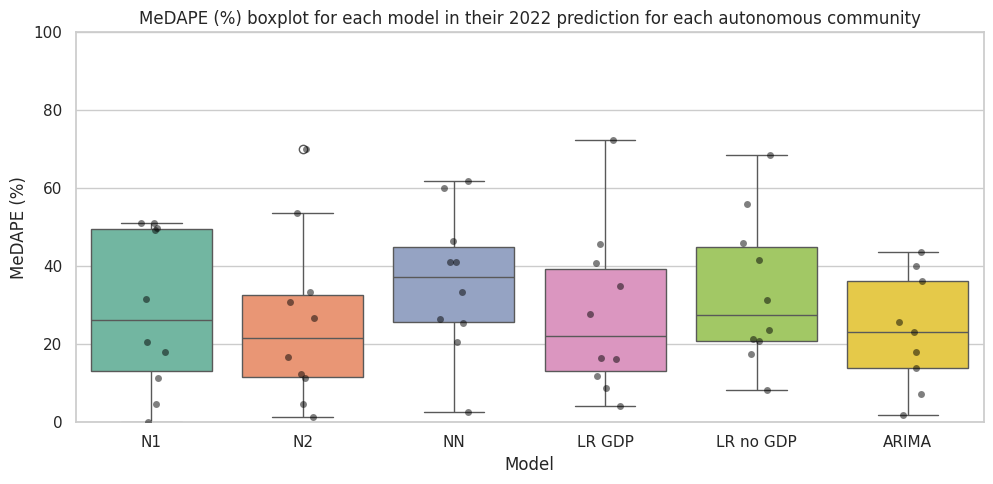

In [ ]:
df_2022 = errors_merged_ccaa[['comunidad_autonoma', 'medape_n1_pib', 'medape_n2', 'mape_nn', 'MedAPE LR with GDP', 'MedAPE LR no GDP', 'mape']]

df_2022.columns = ['Comunidad', 'N1', 'N2', 'NN', 'LR GDP', 'LR no GDP', 'ARIMA']

df_2022_long = df_2022.melt(id_vars='Comunidad', var_name='Model', value_name='MeDAPE (%)')

#no outliers
df_2022_long = df_2022_long[df_2022_long['MeDAPE (%)'] <= 100]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_2022_long, x='Model', y='MeDAPE (%)', palette='Set2')
sns.stripplot(data=df_2022_long, x='Model', y='MeDAPE (%)', color='black', alpha=0.5, jitter=True)
plt.title('MeDAPE (%) boxplot for each model in their 2022 prediction for each autonomous community')
plt.tight_layout()
plt.ylim(0,100)
plt.show()


MAPE

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


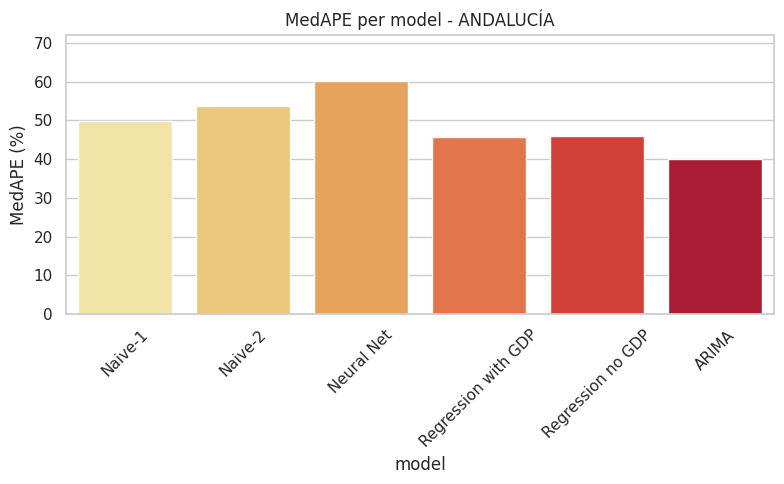

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


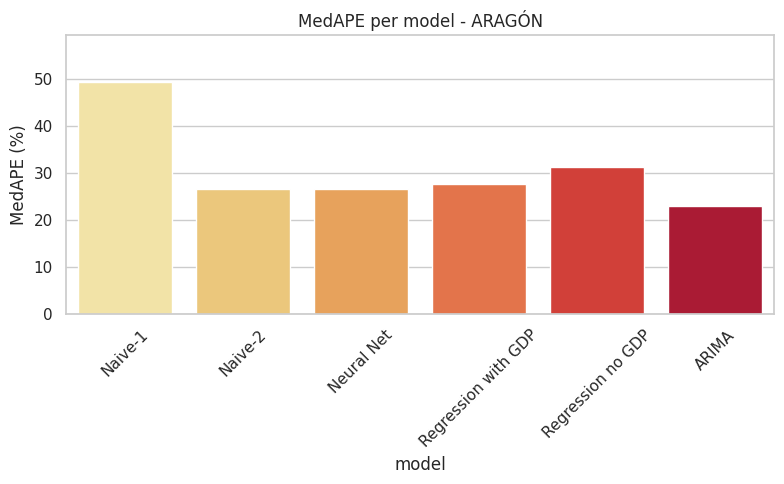

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


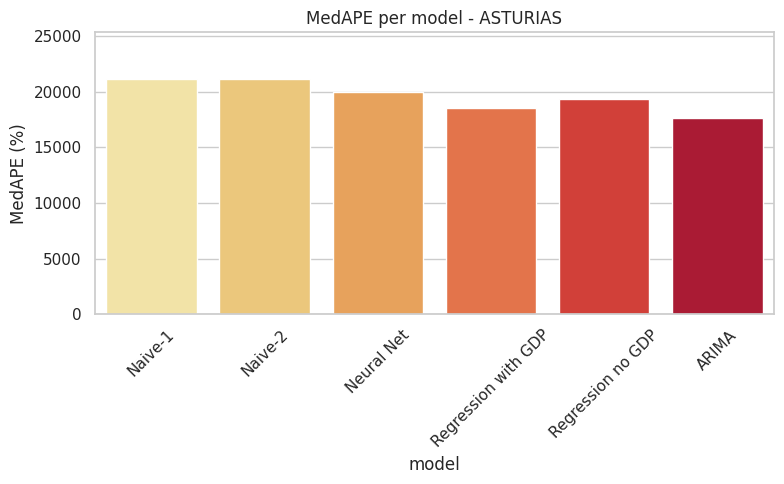

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


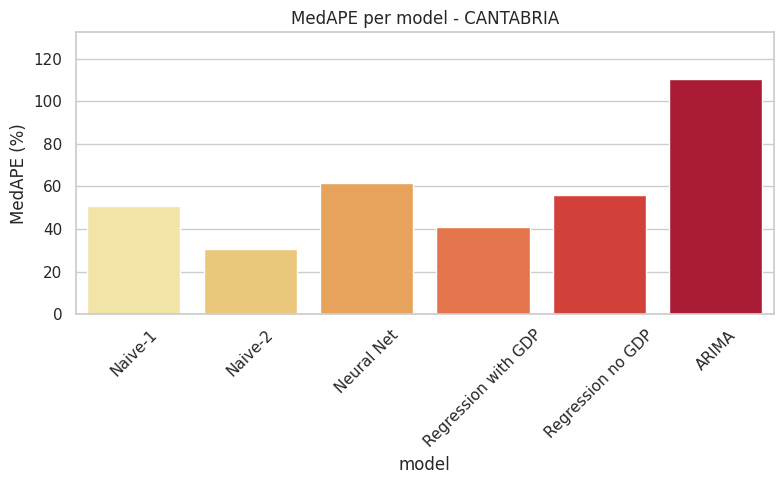

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


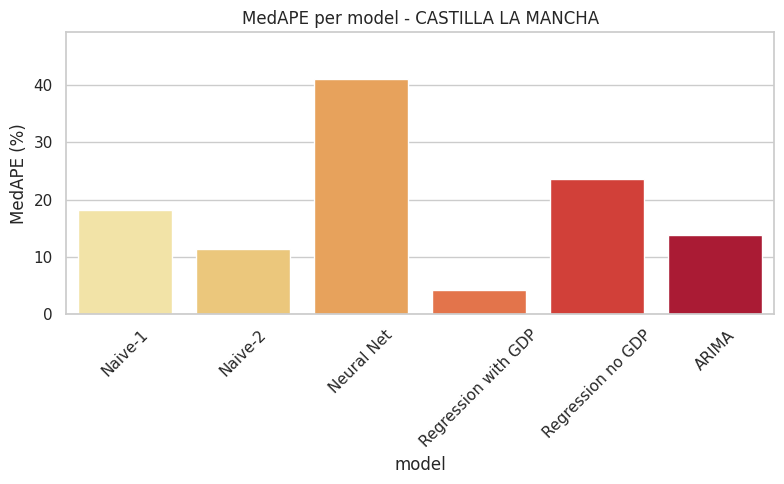

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


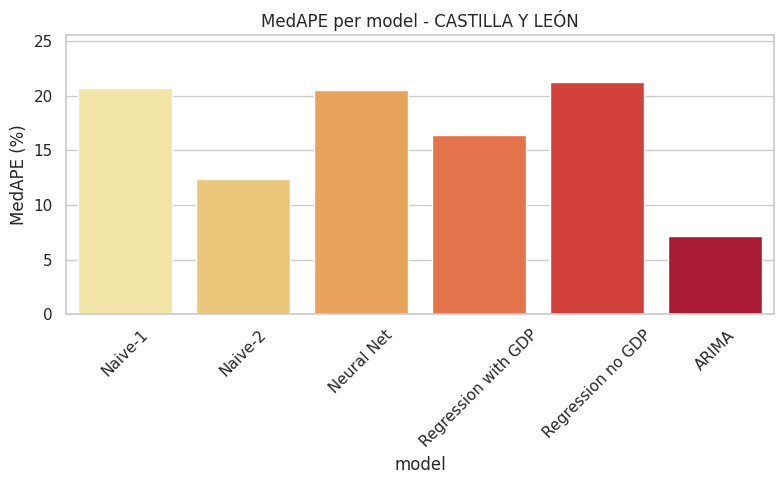

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


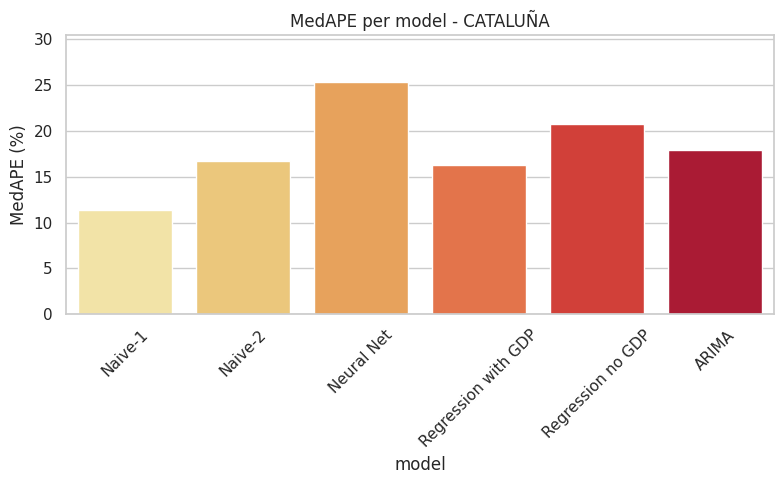

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


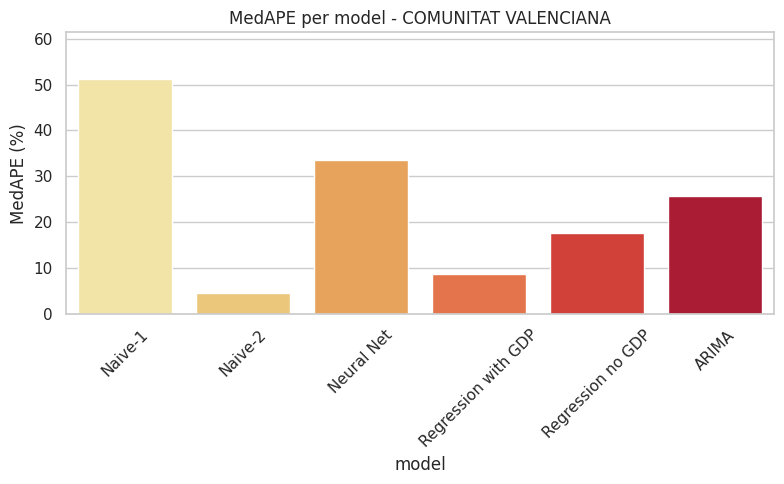

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


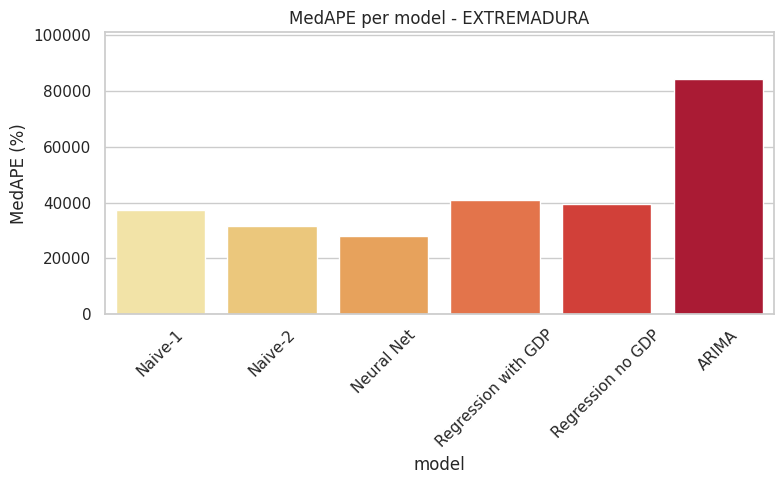

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


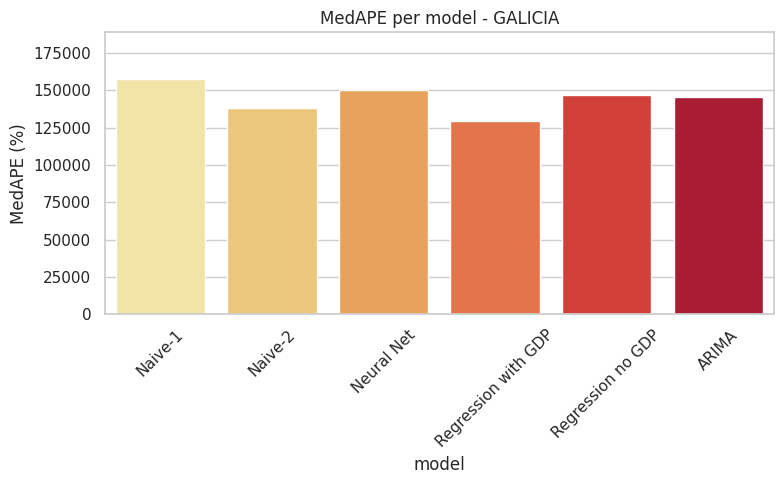

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


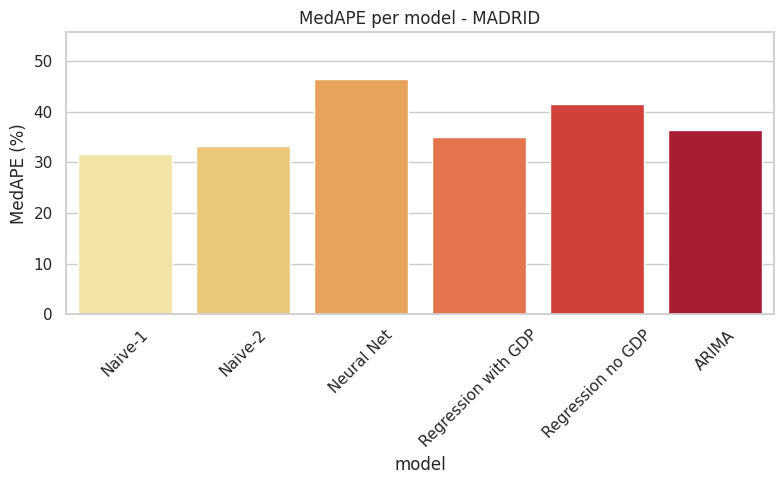

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


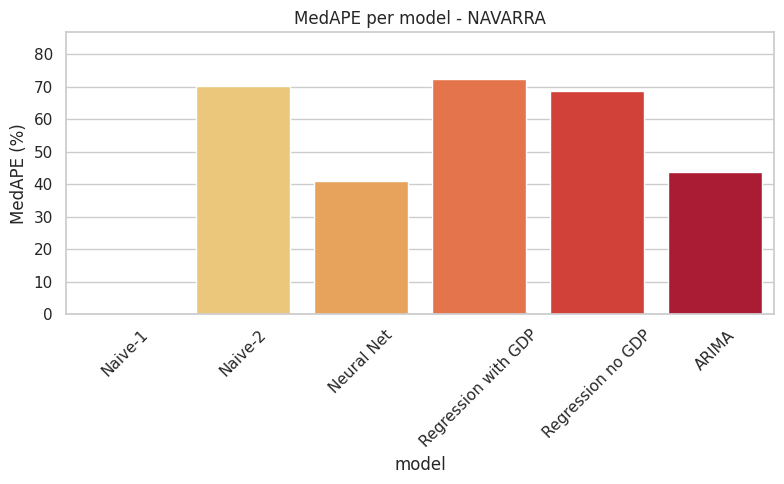

<ipython-input-25-8319bde64a0f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')


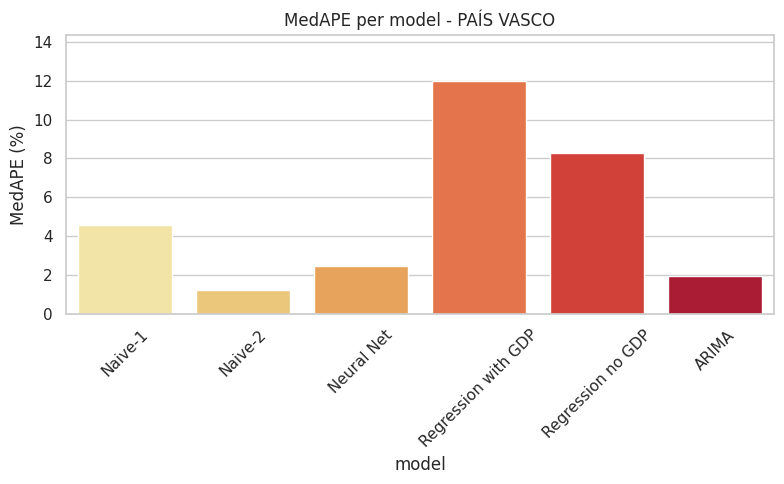

In [ ]:
#mape for each ccaa
for ccaa in comunidades:
    data_ccaa_mape = errors22_melt_mape[errors22_melt_mape['comunidad_autonoma'] == ccaa]

    plt.figure(figsize=(8, 5))
    sns.barplot(data=data_ccaa_mape, x='model', y='MAPE', palette='YlOrRd')
    plt.title(f'MedAPE per model - {ccaa}')
    plt.xticks(rotation=45)
    plt.ylim(0, data_ccaa_mape['MAPE'].max() * 1.2)
    plt.ylabel('MedAPE (%)')
    plt.tight_layout()
    plt.show()

RMSE

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


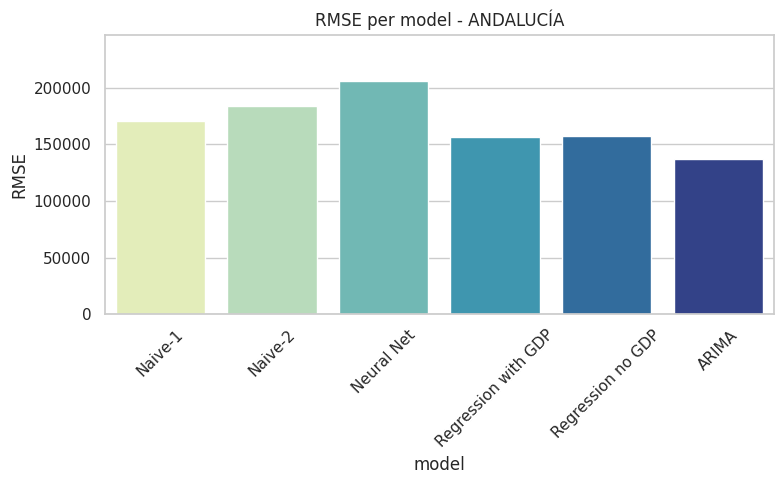

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


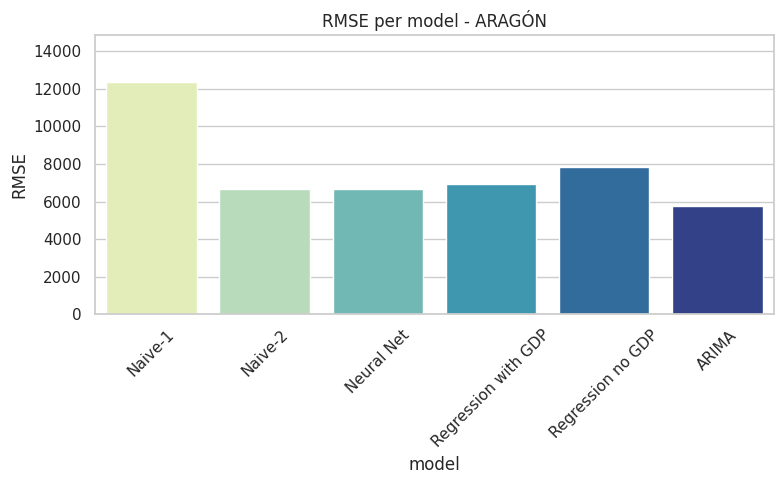

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


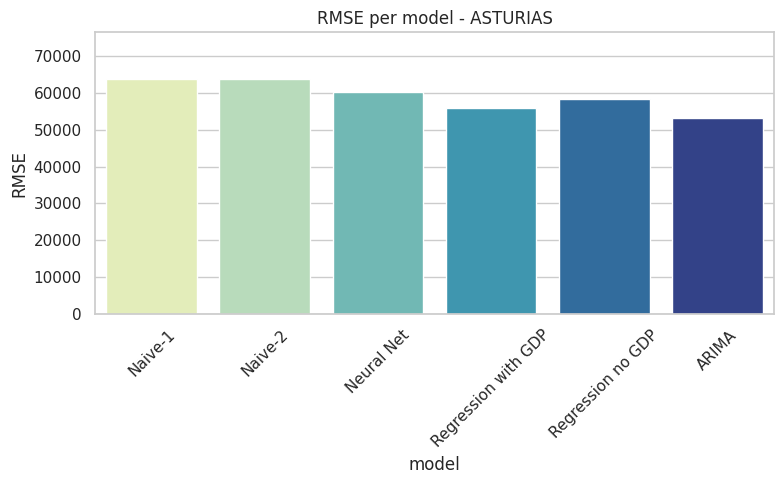

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


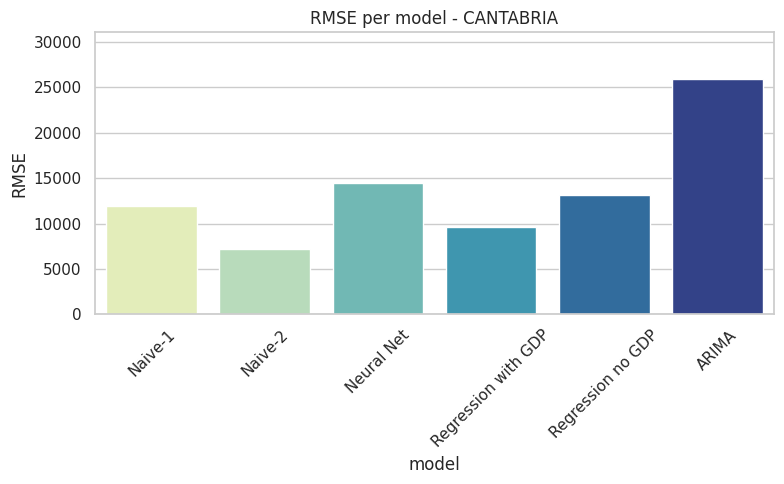

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


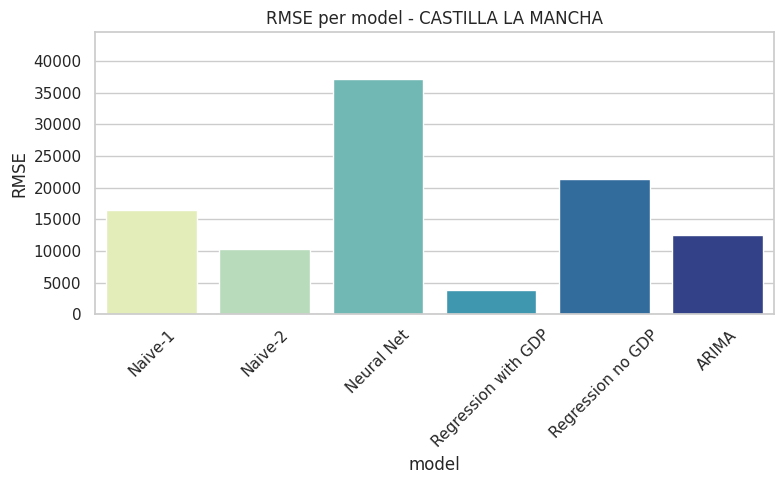

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


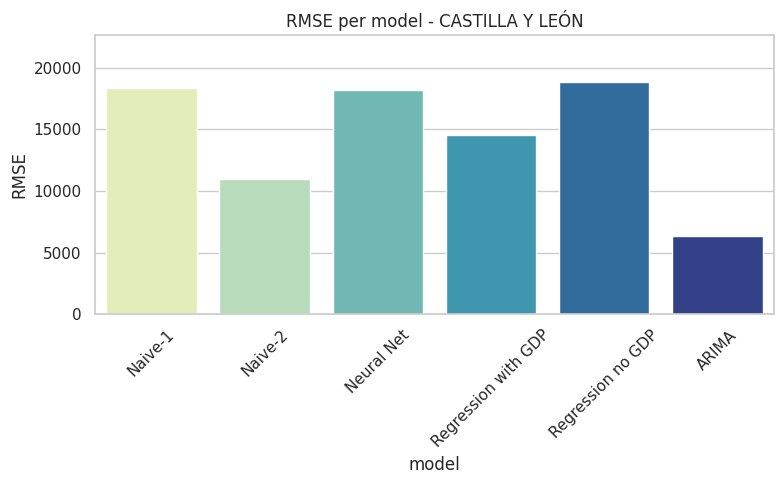

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


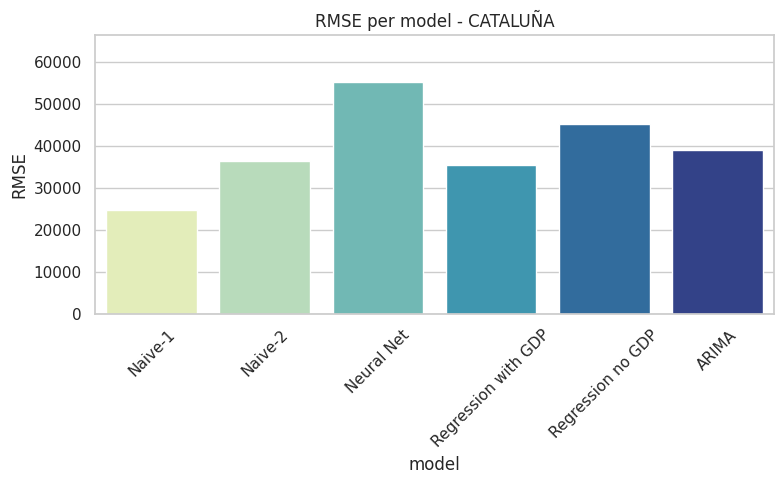

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


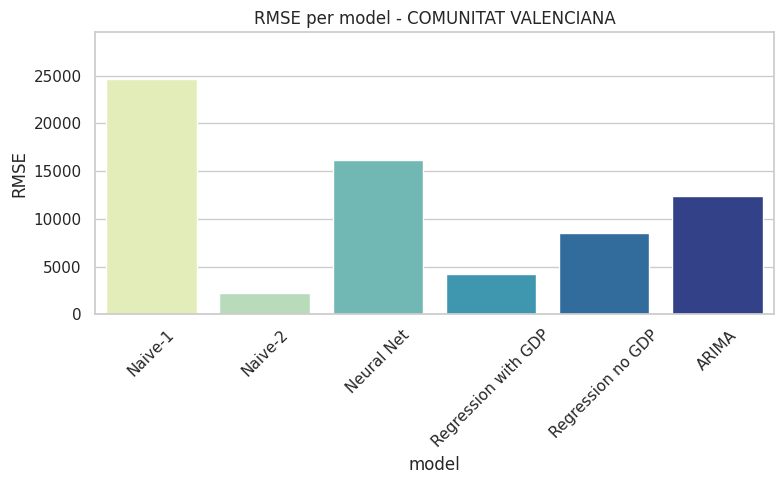

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


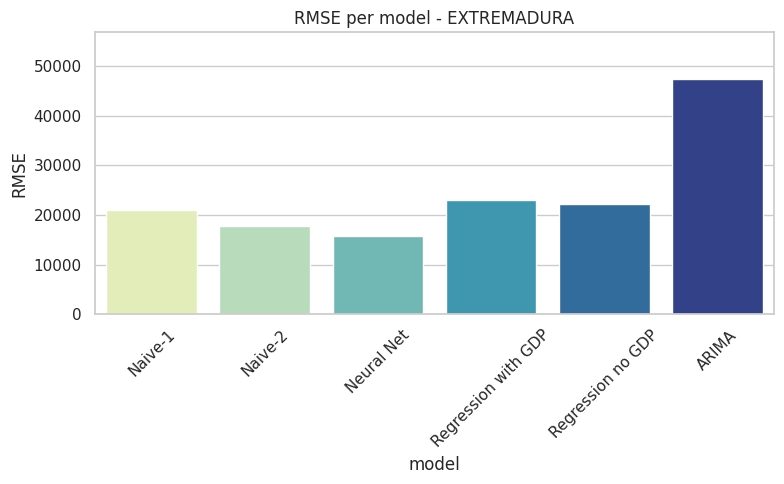

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


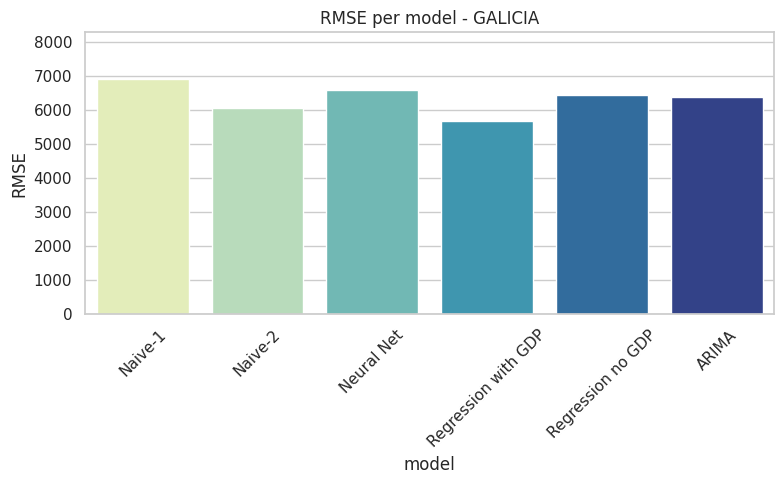

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


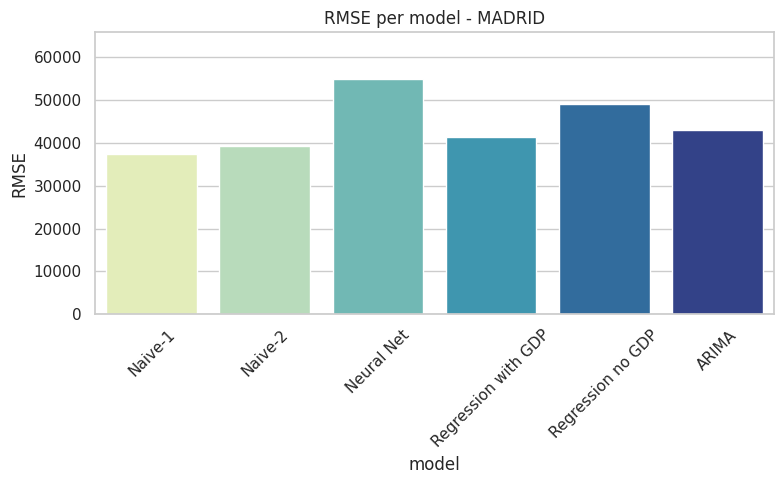

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


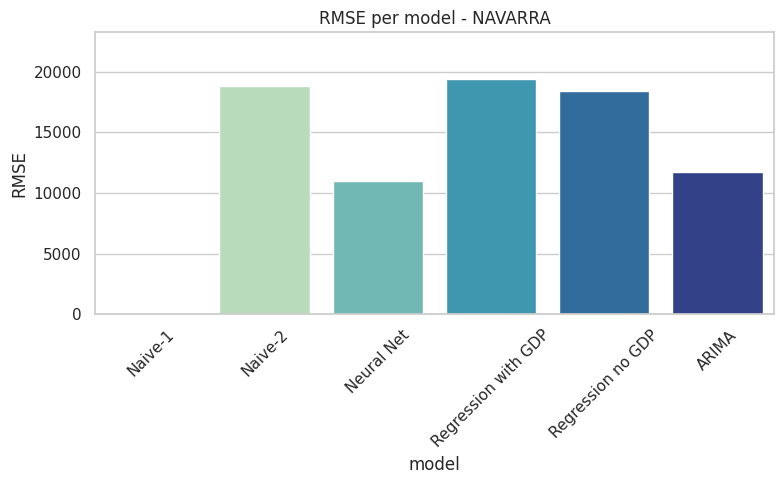

<ipython-input-26-690196f53d80>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')


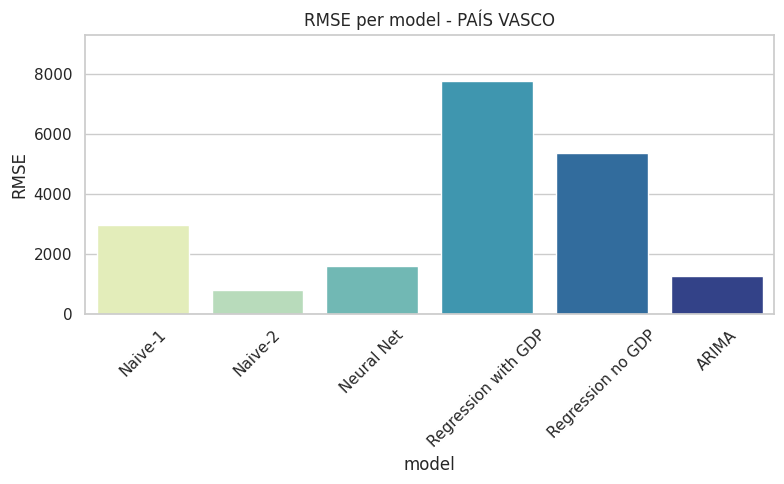

In [ ]:
for ccaa in comunidades:
    data_ccaa_rmse = errors22_melt_rmse[errors22_melt_rmse['comunidad_autonoma'] == ccaa]

    plt.figure(figsize=(8, 5))
    sns.barplot(data=data_ccaa_rmse, x='model', y='RMSE', palette='YlGnBu')
    plt.title(f'RMSE per model - {ccaa}')
    plt.xticks(rotation=45)
    plt.ylim(0, data_ccaa_rmse['RMSE'].max() * 1.2)
    plt.ylabel('RMSE')
    plt.tight_layout()
    plt.show()

###Friedman test

In [ ]:
cols_order = ['MedAPE LR with GDP',   # LR GDP
              'MedAPE LR no GDP',     # LR no GDP
              'mape',                 # ARIMA  (column mape = MedAPE ARIMA)
              'mape_nn',              # NN     (column mape_nn)
              'medape_n1_pib',        # N1
              'medape_n2']            # N2

df_mape_ccaa = errors_merged_ccaa[cols_order].copy()
labels  = ['LR GDP', 'LR no GDP', 'ARIMA', 'NN', 'N1', 'N2']

In [ ]:
df_mape_ccaa

,MedAPE LR with GDP,MedAPE LR no GDP,mape,mape_nn,medape_n1_pib,medape_n2
0,45.631941,46.012919,39.981375,60.055932,49.815570,53.641244
1,27.669556,31.235690,23.018636,26.485501,49.306384,26.669627
2,18549.389874,19343.917346,17695.247075,20011.851678,21134.095796,21130.435249
3,40.722987,56.090395,110.267939,61.764466,50.981523,30.796237
4,4.224427,23.548269,13.789224,40.988055,18.116236,11.418253
5,16.351940,21.252055,7.121452,20.477222,20.670987,12.359070
6,16.244773,20.799002,17.910722,25.366138,11.401753,16.675822
7,8.717208,17.602651,25.725270,33.518190,51.137042,4.708355
8,40810.273255,39530.994797,84118.500478,28003.868670,37151.998899,31730.785056
9,129213.216467,146863.711354,145728.476312,149997.921076,157444.121401,138171.783180


In [ ]:
#remove outliers
df_mape_ccaa = df_mape_ccaa[df_mape_ccaa['MedAPE LR with GDP'] <= 100]
df_mape_ccaa

,MedAPE LR with GDP,MedAPE LR no GDP,mape,mape_nn,medape_n1_pib,medape_n2
0,45.631941,46.012919,39.981375,60.055932,49.815570,53.641244
1,27.669556,31.235690,23.018636,26.485501,49.306384,26.669627
3,40.722987,56.090395,110.267939,61.764466,50.981523,30.796237
4,4.224427,23.548269,13.789224,40.988055,18.116236,11.418253
5,16.351940,21.252055,7.121452,20.477222,20.670987,12.359070
6,16.244773,20.799002,17.910722,25.366138,11.401753,16.675822
7,8.717208,17.602651,25.725270,33.518190,51.137042,4.708355
10,34.925385,41.483814,36.324632,46.363775,31.533591,33.285753
11,72.317635,68.620567,43.743378,41.163790,0.077971,70.179090
12,11.956984,8.285410,1.974672,2.501503,4.588032,1.244550


In [ ]:
stat, p = friedmanchisquare(*[df_mape_ccaa[col] for col in df_mape_ccaa.columns])
print(f'Friedman test statistic = {stat:.4f}, p-value = {p:.6f}')

Friedman test statistic = 10.0571, p-value = 0.073632


0.073632 > 0.05 so we cannot reject the null hypothesis thar any model is better than the others

In [ ]:
df_mape_ccaa.columns = labels
nemenyi = sp.posthoc_nemenyi_friedman(df_mape_ccaa.values)
nemenyi.index = labels
nemenyi.columns = labels
print('\nNemenyi p-value matrix:\n', nemenyi)


Nemenyi p-value matrix:
              LR GDP  LR no GDP     ARIMA        NN        N1        N2
LR GDP     1.000000   0.549547  0.999894  0.549547  0.996916  0.979939
LR no GDP  0.549547   1.000000  0.394405  1.000000  0.839370  0.159450
ARIMA      0.999894   0.394405  1.000000  0.394405  0.979939  0.996916
NN         0.549547   1.000000  0.394405  1.000000  0.839370  0.159450
N1         0.996916   0.839370  0.979939  0.839370  1.000000  0.839370
N2         0.979939   0.159450  0.996916  0.159450  0.839370  1.000000


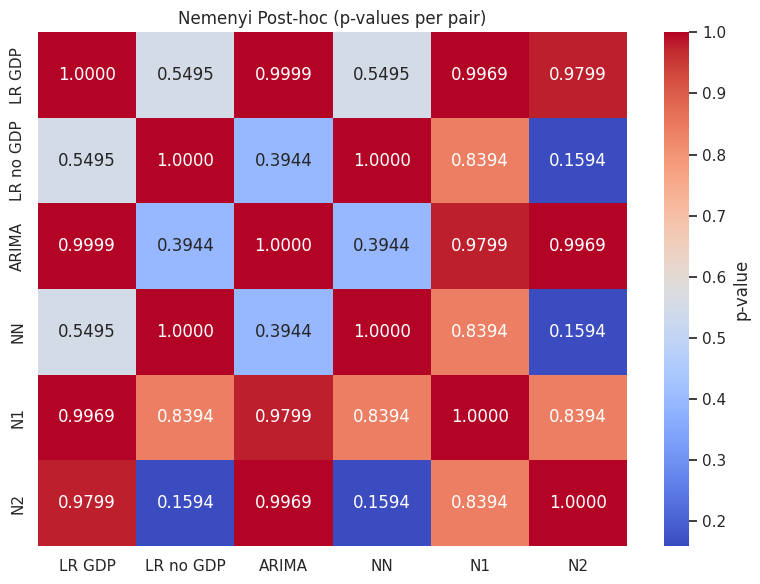

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(nemenyi, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title("Nemenyi Post-hoc (p-values per pair)")
plt.tight_layout()
plt.show()

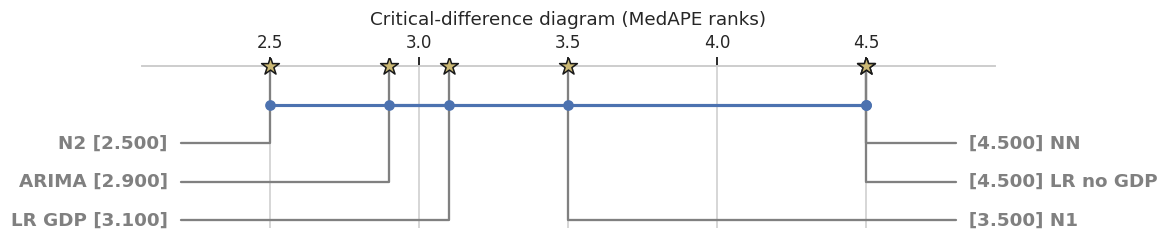

In [ ]:
sns.set(style='whitegrid')
ranks = df_mape_ccaa.rank(axis=1, method='average', ascending=True)
avg_rank = ranks.mean().to_dict()

plt.figure(figsize=(10, 2), dpi=110)
plt.title('Critical-difference diagram (MedAPE ranks)')
sp.critical_difference_diagram(
    ranks=avg_rank,
    sig_matrix=nemenyi,
    label_fmt_left='{label} [{rank:.3f}]  ',
    label_fmt_right='  [{rank:.3f}] {label}',
    text_h_margin=0.3,
    label_props={'fontweight': 'bold'},
    crossbar_props={'color': None, 'marker': 'o'},
    marker_props={'marker': '*', 's': 150, 'color': 'y', 'edgecolor': 'k'},
    elbow_props={'color': 'gray'},
)
plt.show()

## Comparing errors - NOT BY CCAA - global

In [ ]:
# #safe the dfs
# import os

# output_dir = '/content/drive/My Drive/DataFrames_errors'

# os.makedirs(output_dir, exist_ok=True)

# dfs = {
#     "errors_n1.xlsx": errors_n1,
#     "errors_n2.xlsx": errors_n2,
#     "errors_nn.xlsx": errors_nn,
#     "errors_arima.xlsx": errors_arima,
#     "errors_arima_years.xlsx": errors_arima_years,
#     "errors_nn_years.xlsx": errors_nn_years
# }

# for filename, df in dfs.items():
#     file_path = os.path.join(output_dir, filename)
#     df.to_excel(file_path, index=False)

In [ ]:
# import os

# output_dir = '/content/drive/My Drive/DataFrames_errors_naive'

# os.makedirs(output_dir, exist_ok=True)

# dfs = {
#     "errors_naive2_years.xlsx": errors_naive2_years,
#     "errors_naive1_years.xlsx": errors_naive1_years,
# }

# for filename, df in dfs.items():
#     file_path = os.path.join(output_dir, filename)
#     df.to_excel(file_path, index=False)

In [ ]:
!gdown --id '1-MabYcoQcbC9X2J23Nono6rbpI6862Cn' --output errors_rl_gdp_global.xlsx
!gdown --id '1-EhPrsHFQyJVS8tqJAJc2BSyN5rCcbuO' --output errors_rl_global.xlsx
!gdown --id '1-V0fCYktO0wbK3vR-YzyfW1L8zOUvbfL' --output errors_arima_global.xlsx
!gdown --id '1-_NhZ2Qb8OcOVUt07Eu04TyD_mH0M8Sb' --output errors_n1_global.xlsx
!gdown --id '1-_NHKzKbrKqMtzrZ7yV1KJ9thLvZzpRZ' --output errors_n2_global.xlsx
!gdown --id '1-WCejCwRWfLwEEL7ehYWRnfefNSKo4e7' --output errors_nn_global.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-MabYcoQcbC9X2J23Nono6rbpI6862Cn
To: /content/errors_rl_gdp_global.xlsx
100% 5.03k/5.03k [00:00<00:00, 11.9MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-EhPrsHFQyJVS8tqJAJc2BSyN5rCcbuO
To: /content/errors_rl_global.xlsx
100% 5.03k/5.03k [00:00<00:00, 9.52MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloadi

In [ ]:
errors_rl_gdp_global = pd.read_excel("errors_rl_gdp_global.xlsx")
errors_rl_global = pd.read_excel("errors_rl_global.xlsx")
errors_arima_global = pd.read_excel("errors_arima_global.xlsx")
errors_n1_global = pd.read_excel("errors_n1_global.xlsx")
errors_n2_global = pd.read_excel("errors_n2_global.xlsx")
errors_nn_global = pd.read_excel("errors_nn_global.xlsx")

In [ ]:
errors_arima = errors_arima_global.rename(columns={
    "mape_arima": "MAPE",
    "medape_arima": "MedAPE",
    "rmse_arima": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]

errors_rl_gdp = errors_rl_gdp_global.rename(columns={
    "mape_lr_gdp": "MAPE",
    "medape_lr_gdp": "MedAPE",
    "rmse_lr_gdp": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]
errors_rl_gdp['Model'] = 'Linear Regression (with GDP)'

errors_lr = errors_rl_global.rename(columns={
    "mape_lr": "MAPE",
    "medape_lr": "MedAPE",
    "rmse_lr": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]

errors_nn = errors_nn_global.rename(columns={
    "mape_nn": "MAPE",
    "medape_nn": "MedAPE",
    "rmse_nn": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]

errors_n1 = errors_n1_global.rename(columns={
    "mape_n1": "MAPE",
    "medape_n1": "MedAPE",
    "rmse_n1": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]

errors_n2 = errors_n2_global.rename(columns={
    "mape_n2": "MAPE",
    "medape_n2": "MedAPE",
    "rmse_n2": "RMSE"
})[['Model', 'MAPE', 'MedAPE', 'RMSE']]

In [ ]:
errors_global = pd.concat(
    [errors_n1, errors_n2, errors_rl_gdp, errors_lr, errors_nn, errors_arima],
    ignore_index=True
)

display(errors_global)

,Model,MAPE,MedAPE,RMSE
0,Naive - Mean,166.167573,49.306384,53466.067877
1,Naive - 3 Years Mean,147.149217,30.796237,56637.036543
2,Linear Regression (with GDP),14527.049418,34.925385,49518.019190
3,Linear Regression,15851.811867,41.483814,51667.152872
4,Neural Network,115379.687500,83.159894,97711.495659
5,ARIMA,16504.474717,16.997084,50662.469585


<ipython-input-244-0c2b48c1811b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-244-0c2b48c1811b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


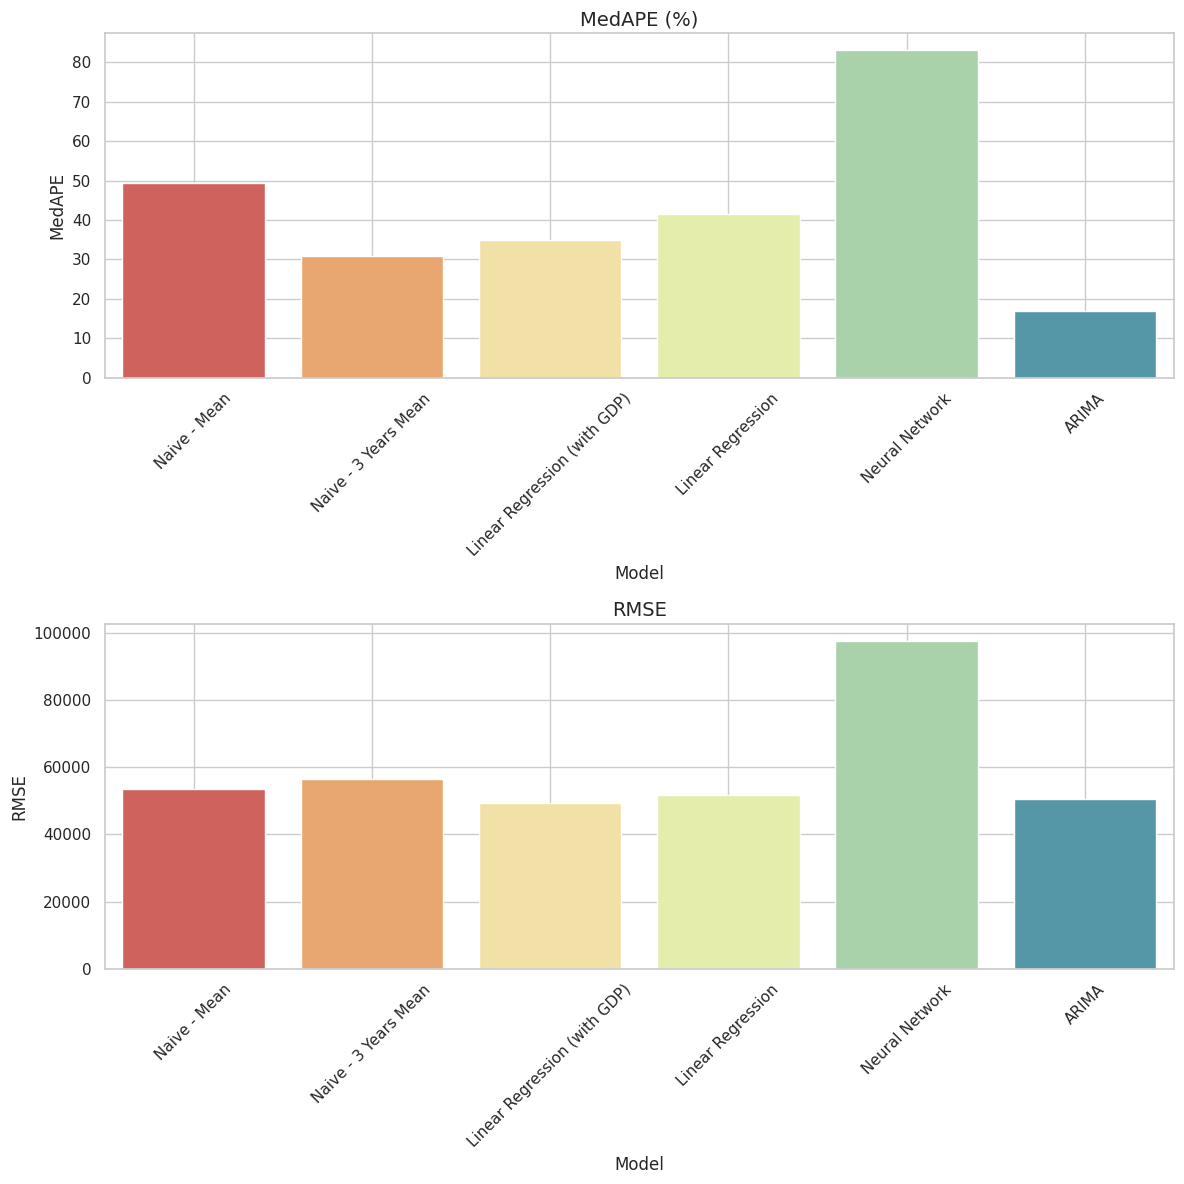

In [ ]:
sns.set(style="whitegrid")

palette = sns.color_palette("Spectral", len(errors_global))

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
metrics = ['MedAPE', 'RMSE']
titles = ['MedAPE (%)', 'RMSE']

for i, metric in enumerate(metrics):
    sns.barplot(
        ax=axes[i],
        x='Model',
        y=metric,
        data=errors_global,
        palette=palette
    )
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## Comparing errors - BY YEARS

In [ ]:
#import the dfs
!gdown --id '1-07-RCRKN_n9W7jwEac1r_1cSG8tezDh' --output n1.xlsx
!gdown --id '1-4fkh7KAazmkfwL1Z8TY3iQ3bwC_HatG' --output n2.xlsx
!gdown --id '1-3eMRuE8z0kuzhCG2QkNxwYY1aF6vQy5' --output lr_gdp.xlsx
!gdown --id '1--zuyshd0-Jzvz9zEWwuq6E8EcI0mem8' --output lr.xlsx
!gdown --id '1-1e3jxWWIqXrUFSLXghLZ1OoEheKYBLW' --output nn.xlsx
!gdown --id '1-AOOPsdZGwLi4akozlV1c5LPd5LfDg8e' --output arima.xlsx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-07-RCRKN_n9W7jwEac1r_1cSG8tezDh
To: /content/n1.xlsx
100% 5.53k/5.53k [00:00<00:00, 13.4MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-4fkh7KAazmkfwL1Z8TY3iQ3bwC_HatG
To: /content/n2.xlsx
100% 5.53k/5.53k [00:00<00:00, 12.8MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google

In [ ]:
errors_naive1_years = pd.read_excel("n1.xlsx")
errors_naive2_years = pd.read_excel("n2.xlsx")
errors_arima_years = pd.read_excel("arima.xlsx")
errors_lr_gdp_years = pd.read_excel("lr_gdp.xlsx")
errors_lr_years = pd.read_excel("lr.xlsx")
errors_nn_years = pd.read_excel("nn.xlsx")

In [ ]:
errors_lr_gdp_years

,año,MedAPE LR GDP,RMSE LR GDP
0,2012,22.517422,28231.257954
1,2013,16.794660,26433.020431
2,2014,14.824365,10015.357239
3,2015,30.664976,29447.183473
4,2016,21.707487,22739.191729
5,2017,25.606376,76211.768645
6,2018,50.317061,101509.667543
7,2019,25.717184,49281.779387
8,2020,54.284117,107037.148255
9,2021,97.286071,89466.330284


In [ ]:
errors_lr_years

,año,MedAPE LR no GDP,RMSE LR no GDP
0,2012,24.349918,28427.276671
1,2013,23.662466,29710.551272
2,2014,31.631891,73411.816574
3,2015,31.369214,33696.852142
4,2016,10.663730,11102.354364
5,2017,21.550707,16524.566556
6,2018,21.549527,25012.678791
7,2019,30.120394,32111.937963
8,2020,13.347127,29574.343032
9,2021,39.070191,34968.303875


In [ ]:
errors_arima_years

,año,Mediana_MAPE,Mediana_RMSE
0,2011,44.782643,3.985328e+04
1,2012,33.027281,2.156431e+06
2,2013,24.092849,2.251363e+04
3,2014,20.709469,2.908543e+04
4,2015,9.063534,6.182828e+03
5,2016,10.930276,1.568398e+04
6,2017,21.707504,1.121639e+04
7,2018,27.914603,2.156515e+04
8,2019,24.699521,2.928610e+04
9,2020,24.424289,2.451584e+04


In [ ]:
errors_nn_years

,año,MeDAPE NN,RMSE NN
0,2008,164.793445,90383.651472
1,2009,94.649387,65367.989408
2,2010,61.093749,61778.617402
3,2011,71.758689,64229.173720
4,2012,70.880527,56245.610647
5,2013,63.881466,49345.300423
6,2014,93.791335,48655.518973
7,2015,96.540546,49095.604270
8,2016,59.374957,46436.255815
9,2017,66.787882,53933.430189


In [ ]:
errors_naive1_years

,año,MeDAPE Naive1,RMSE Naive1
0,2008,36.135334,58110.455072
1,2009,47.424978,46671.884684
2,2010,53.548557,43481.793822
3,2011,42.908065,35496.477397
4,2012,42.359382,48981.170649
5,2013,45.988932,44121.439295
6,2014,32.546241,41184.600261
7,2015,30.561766,31314.385925
8,2016,29.583020,30302.752692
9,2017,42.777945,25343.196555


In [ ]:
errors_naive2_years

,año,MeDAPE Naive2,RMSE Naive2
0,2008,36.135334,58110.455072
1,2009,47.424978,46671.884684
2,2010,53.548557,43481.793822
3,2011,21.088689,20300.215637
4,2012,34.501616,31951.921021
5,2013,15.354356,20293.295012
6,2014,17.301111,15261.876718
7,2015,12.707987,9352.804971
8,2016,4.951754,9648.908566
9,2017,28.826309,15440.093313


In [ ]:
#merge them by year
errors_merged = errors_nn_years.merge(
    errors_lr_gdp_years, on='año'
).merge(
    errors_lr_years, on='año'
).merge(
    errors_arima_years, on='año'
).merge(
    errors_naive1_years, on='año'
).merge(
    errors_naive2_years, on='año'
)

In [ ]:
errors_merged = errors_merged.rename(columns={
    'Mediana_MAPE': 'MedAPE ARIMA'
})

df_mape = errors_merged[['MedAPE LR GDP', 'MedAPE LR no GDP', 'MedAPE ARIMA', 'MeDAPE NN', 'MeDAPE Naive1', 'MeDAPE Naive2']]

In [ ]:
df_mape

,MedAPE LR GDP,MedAPE LR no GDP,MedAPE ARIMA,MeDAPE NN,MeDAPE Naive1,MeDAPE Naive2
0,22.517422,24.349918,33.027281,70.880527,42.359382,34.501616
1,16.794660,23.662466,24.092849,63.881466,45.988932,15.354356
2,14.824365,31.631891,20.709469,93.791335,32.546241,17.301111
3,30.664976,31.369214,9.063534,96.540546,30.561766,12.707987
4,21.707487,10.663730,10.930276,59.374957,29.583020,4.951754
5,25.606376,21.550707,21.707504,66.787882,42.777945,28.826309
6,50.317061,21.549527,27.914603,59.926741,33.442740,14.195021
7,25.717184,30.120394,24.699521,66.413926,22.586102,19.583434
8,54.284117,13.347127,24.424289,50.085485,17.619929,17.292622
9,97.286071,39.070191,14.501188,62.403972,17.561392,11.118440


### Box plot

<ipython-input-78-2977377da803>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mape_long_filtered, x='Model', y='MedAPE', palette='Set3')


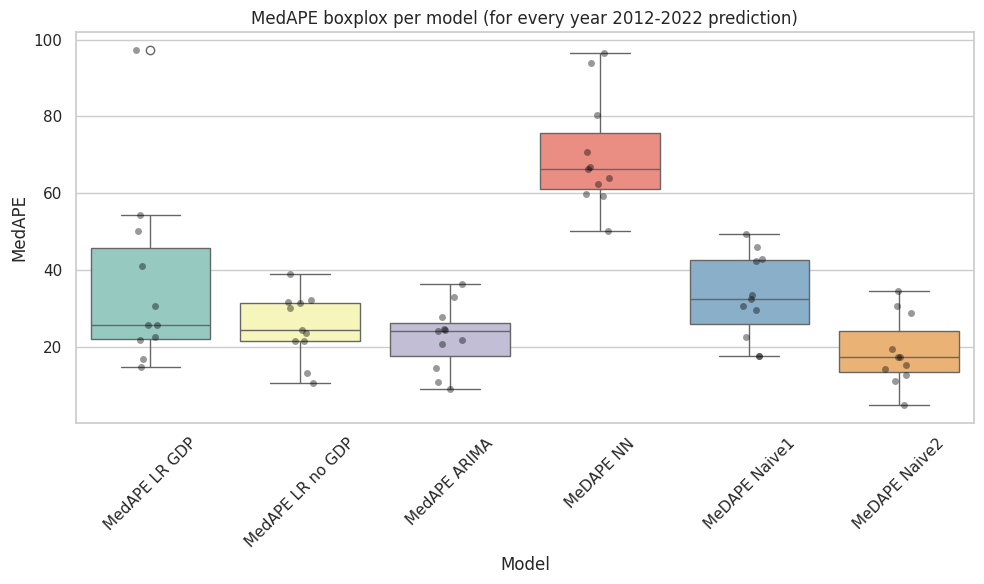

In [ ]:
df_mape_long = df_mape.melt(var_name='Model', value_name='MedAPE')

df_mape_long_filtered = df_mape_long[df_mape_long['MedAPE'] <= 100]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_mape_long_filtered, x='Model', y='MedAPE', palette='Set3')
sns.stripplot(data=df_mape_long_filtered, x='Model', y='MedAPE', color='black', alpha=0.4, jitter=True)
plt.title('MedAPE boxplox per model (for every year 2012-2022 prediction)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Friedman test

In [ ]:
stat, p = friedmanchisquare(
    df_mape['MedAPE LR GDP'],
    df_mape['MedAPE LR no GDP'],
    df_mape['MedAPE ARIMA'],
    df_mape['MeDAPE NN'],
    df_mape['MeDAPE Naive1'],
    df_mape['MeDAPE Naive2']
)
print(f"Friedman test statistic = {stat:.4f}, p-value = {p:.6f}")

Friedman test statistic = 29.8571, p-value = 0.000016


In [ ]:
nemenyi = sp.posthoc_nemenyi_friedman(df_mape.values)
nemenyi.index = ['LR GDP', 'LR no GDP', 'ARIMA', 'NN', 'N1', 'N2']
nemenyi.columns = ['LR GDP', 'LR no GDP', 'ARIMA', 'NN', 'N1', 'N2']

print(nemenyi)

             LR GDP  LR no GDP     ARIMA        NN        N1        N2
LR GDP     1.000000   0.909503  0.909503  0.068511  0.992963  0.202496
LR no GDP  0.909503   1.000000  1.000000  0.002340  0.601571  0.810150
ARIMA      0.909503   1.000000  1.000000  0.002340  0.601571  0.810150
NN         0.068511   0.002340  0.002340  1.000000  0.254161  0.000008
N1         0.992963   0.601571  0.601571  0.254161  1.000000  0.050097
N2         0.202496   0.810150  0.810150  0.000008  0.050097  1.000000


<ipython-input-81-8f14bcd30bf4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mape_means.index, y=mape_means.values, palette="pastel")


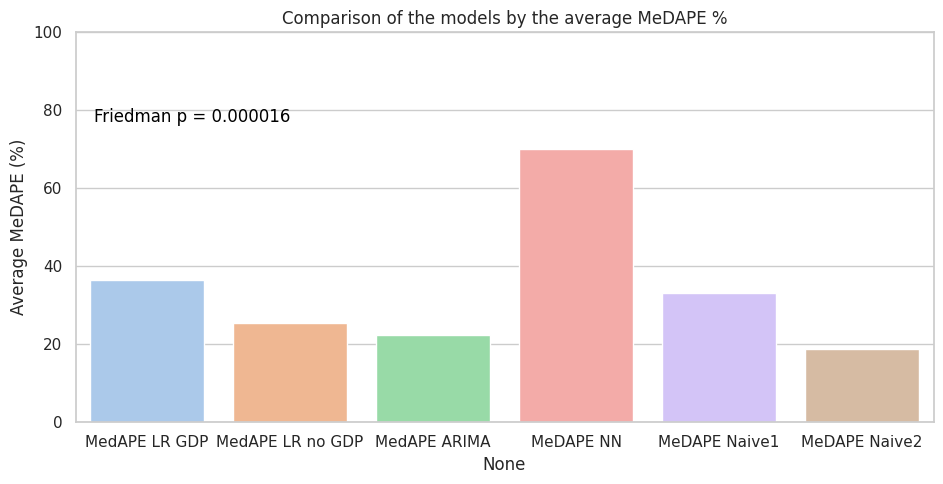

In [ ]:
mape_means = df_mape.mean()
plt.figure(figsize=(9.5, 5))
sns.barplot(x=mape_means.index, y=mape_means.values, palette="pastel")
plt.ylabel("Average MeDAPE (%)")
plt.title("Comparison of the models by the average MeDAPE %")
plt.ylim(0, max(mape_means.values)*1.2)
# Anotación del p-valor
plt.text(1, max(mape_means.values)*1.1, f"Friedman p = {p:.6f}", ha='right', fontsize=12, color='black')
plt.tight_layout()
plt.ylim(0, 100)
plt.show()

###Post-hoc

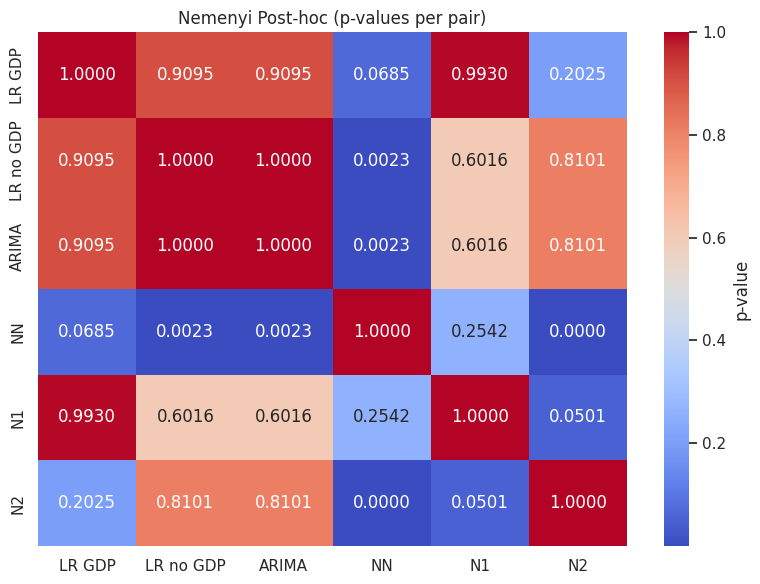

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(nemenyi, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title("Nemenyi Post-hoc (p-values per pair)")
plt.tight_layout()
plt.show()

###Critical difference diagram

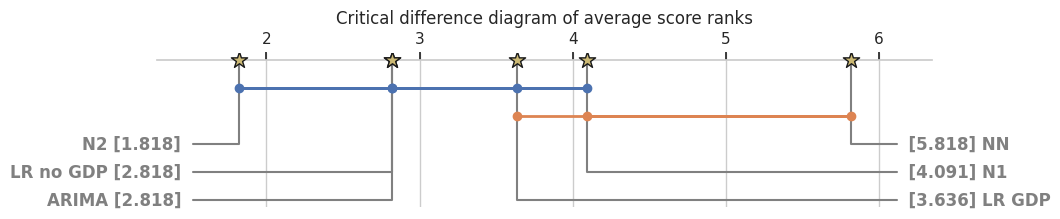

In [ ]:
df_mape.columns = ['LR GDP', 'LR no GDP', 'ARIMA', 'NN', 'N1', 'N2']
ranks = df_mape.rank(axis=1, method='average', ascending=True)

avg_rank = ranks.mean().to_dict()
model_names = df_mape.columns.tolist()
nemenyi.index = model_names
nemenyi.columns = model_names

plt.figure(figsize=(10, 2), dpi=100)
plt.title('Critical difference diagram of average score ranks')
sp.critical_difference_diagram(
    ranks=avg_rank,
    sig_matrix=nemenyi,
    label_fmt_left='{label} [{rank:.3f}]  ',
    label_fmt_right='  [{rank:.3f}] {label}',
    text_h_margin=0.3,
    label_props={'fontweight': 'bold'},
    crossbar_props={'color': None, 'marker': 'o'},
    marker_props={'marker': '*', 's': 150, 'color': 'y', 'edgecolor': 'k'},
    elbow_props={'color': 'gray'},
)
plt.show()